# <center> **APRENDIZAJE AUTOMÁTICO E INTELIGENCIA ARTIFICIAL** </center>
## <center> **Especialización Ciencia de Datos e Inteligencia Artificial - ECDIA** </center>
###  <center> Universidad Tecnológica - UTEC </center>
### <center> Martina Ibarra - Florencia Nebot - Elena Salomon </center>



# **Contextualización de la Problemática**
Se suele decir que "*no se debe juzgar un libro por su portada*" y precisamente ese es el punto de partida de nuestro trabajo.

Al cierre del 2024, se alcanzaron a publicar entre 2.2 y 2.4 millones de libros, con esta estimación son 6.000 libros publicados diariamente, en diferentes formatos (según análisis del sector, como los reportados por [Love Books Review](https://https://love-books-review.com/es/datos-y-cifras-sobre-la-literatura/estadisticas-generales-sobre-literatura/cuantos-libros-se-publican-cada-ano/)).

Como lectoras frecuentes sabemos que puede resultar abrumador elegir un libro, a veces terminamos comprando historias que no nos atrapan generando bloqueos lectores hasta lograr dar con un libro atrapante.


# **Objetivo:**

Por lo mencionado anteriormente, nuestro objetivo es, a través de las características de los libros (título, autor, fecha de publicación, puntuación de usuarios, cantidad de hojas, entre otras), crear un modelo de Clasificación que permita predecir que tan popular es un libro, con el fin de que una aplicación como Goodreads pueda mostrar una buena selección de libros en base a reseñas anteriores.

Para la creación del modelo se tendrá en cuenta varias opciones: *Regresión logística, árbol de desición, random forest y  XGBoosts* y se seleccionará la que mas se ajuste a nuestro objetivo.


# **Datos seleccionados:**
Seleccionamos una [base de datos en Kaggle](https://www.kaggle.com/datasets/dk123891/books-dataset-goodreadsmay-2024?resource=download) que contiene 16.225 libros de la aplicación GoodReads a nivel global.

GoodReads es una empresa fundada en 2006 en Estados Unidos operada por GoodReads Inc, subsidiada por Amazon. Es una aplicaicón que contiene un catalogo de libros, anotaciones, citas, reseñas, entre otras cosas, que permite a los usuarios distrutar de lecturas y mantener un registro de las mismas, así como conectarse entre lectores para potenciar las experiencias.

*Contenido del dataset:*

La misma tiene 15 variables, de estas 10 son de tipo object y 5 de tipo numeric (int o float).

1. **book_id**: A unique identifier for each book in the dataset.

2. **cover_image_uri**: The URI (Uniform Resource Identifier) or URL pointing to the cover image of the book.

3. **book_title**: The title of the book.

4. **book_details**: Additional details about the book, such as a summary, plot synopsis, or other descriptive information.

5. **format**: The format of the book, such as hardcover, paperback, ebook, audiobook, etc.

6. **publication_info**: Information about the publication of the book, including the publisher, publication date, and any other relevant details.

7. **authorlink**: The URI or URL pointing to more information about the author, if available.

8. **author**: The name of the author(s) of the book.

9. **num_pages**: The number of pages in the book.

10. **genres**: Differents genres of the book

11. **num_ratings**: Number of users who rated the book

12. **num_reviews**: Number of users who reviewed the book

13. **average_rating**: average rating

14. **rating_distribution**: Distribution of user ratings across different rating levels (e.g., 1 to 5 stars)

15. **Unnamed**: index column

##Carga del Dataset e importación de librerias

In [ ]:
#librerias para manejo de datos y visualizaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#libreria para clustering
from sklearn.cluster import KMeans

#libreria para escalamiento de datos
from sklearn.preprocessing import StandardScaler

#libreria para división de datos (entrenamiento y test del modelo)
from sklearn.model_selection import train_test_split

# modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# métricas para evaluación del modelo
from sklearn import metrics
from sklearn.metrics import (confusion_matrix, classification_report,
    precision_recall_curve, recall_score,
    accuracy_score, precision_score,
    f1_score, roc_auc_score)

#útil para visualización de árboles
from sklearn import tree


# Búsqueda de hiperparámetros
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

#Manejo de datos (conteo de elementos, interpretación de strings, expresiones regulares)
from collections import Counter
import ast
import re


# Para ignorar warnings
import warnings
warnings.filterwarnings("ignore")

#Conexión con drive
from google.colab import drive
drive.mount("/content/gdrive", force_remount=True)

Mounted at /content/gdrive


In [ ]:
#Carga del dataset
file = pd.read_csv('/content/gdrive/MyDrive/Book_Details.csv')
file.head(1)

,Unnamed: 0,book_id,cover_image_uri,book_title,book_details,format,publication_info,authorlink,author,num_pages,genres,num_ratings,num_reviews,average_rating,rating_distribution
0,0,1,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Half-Blood Prince,"It is the middle of the summer, but there is a...","['652 pages, Paperback']","['First published July 16, 2005']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,['652'],"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...",3292516,58398,4.58,"{'5': '2,244,154', '4': '775,028', '3': '219,8..."


In [ ]:
#Visualización de cantidad de filas y columnas del dataset
print('Cantidad de Filas y Columnas')
print(file.shape)
print()

#Información del dataset
print('Informacion del Dataset')
print()
print(file.info())

Cantidad de Filas y Columnas
(16225, 15)

Informacion del Dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16225 entries, 0 to 16224
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           16225 non-null  int64  
 1   book_id              16225 non-null  int64  
 2   cover_image_uri      16225 non-null  object 
 3   book_title           16225 non-null  object 
 4   book_details         16177 non-null  object 
 5   format               16225 non-null  object 
 6   publication_info     16225 non-null  object 
 7   authorlink           16225 non-null  object 
 8   author               16225 non-null  object 
 9   num_pages            16225 non-null  object 
 10  genres               16225 non-null  object 
 11  num_ratings          16225 non-null  int64  
 12  num_reviews          16225 non-null  int64  
 13  average_rating       16225 non-null  float64
 14  rating_distribution

**Observaciones:**

- Cantidad de observaciones: 16.225

- Cantidad de variables: 15. Solamente una variable tiene datos faltantes, `book_details`.

- El dataset contiene 10 variables object y 5 númericas (4 int y 1 float).


In [ ]:
print('Resumen variables numéricas')
print()
file.describe().T

Resumen variables numéricas



,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,16225.0,8.112000e+03,4.683898e+03,0.0,4056.00,8112.00,12168.00,16224.0
book_id,16225.0,1.038704e+07,2.146809e+07,1.0,94034.00,944073.00,11284898.00,209607645.0
num_ratings,16225.0,8.578453e+04,3.202513e+05,0.0,2950.00,16232.00,55944.00,10116247.0
num_reviews,16225.0,5.156270e+03,1.577646e+04,0.0,205.00,993.00,3457.00,274695.0
average_rating,16225.0,4.002499e+00,3.361019e-01,0.0,3.83,4.03,4.21,5.0


**Observaciones:**

*   En promedio, cada libro recibió puntuaciones de 85.784 usuarios, mientras que la mediana es de 16.232 usuarios. Lo que nos hace pensar que tiene una distribución con acumulación de valores en cantidades más bajas, con una larga cola hacia valores más grandes (sesgada a la derecha). Es decir, muchos libros son puntuados por pocos clientes pero algunos pocos libros tienen muchísimas puntuaciones, llegando a un máximo de 10.116.247.

*   En lo que refiere al número de reseñas, en promedio un libro recibe 5.156 reseñas, número mucho mayor que la mediana (993). En promedio, podemos decir que 6% de los usuarios que puntúan un libro dejan también un comentario. Al igual que con los usuarios que puntúan, se ve una distribución accumulada en valores más bajos con una larga cola a valores altos.

*   La puntuación promedio de los libros es de 4 y, al observar que la mediana también es 4, vemos que el 50% de los libros tienen un rating promedio de 4 o menos. Esto sugiere que las personas tienden a puntuar los libros que les gustan. Como la media y la mediana están muy cerca, podemos intuir que la distribución de esta variable es bastante simétrica. Además, considerando el primer y tercer cuartil, observamos que la mitad de los libros tienen una puntuación entre 3.83 y 4.21, lo que confirma que pocos libros en nuestro dataset reciben calificaciones muy bajas.

*   En las tres variables podemos ver que el mínimo es 0, lo que implicaría que existen libros sin puntuación y sin reseñas, puede deberse a bajo consumo del libro (libros nuevos o poco populares) o por malas experiencias con el libro.









In [ ]:
print('Resumen variables categóricas')

file.describe(include='object').T

Resumen variables categóricas


,count,unique,top,freq
cover_image_uri,16225,16120,https://dryofg8nmyqjw.cloudfront.net/images/no...,38
book_title,16225,15491,The Cheat Code,7
book_details,16177,16018,"Libro usado en buenas condiciones, por su anti...",6
format,16225,3104,"['288 pages, Paperback']",142
publication_info,16225,5369,"['First published January 1, 2008']",360
authorlink,16225,7615,https://www.goodreads.com/author/show/3389.Ste...,79
author,16225,7615,Stephen King,79
num_pages,16225,1083,[None],274
genres,16225,13773,[],325
rating_distribution,16225,16093,"{'5': '0', '4': '0', '3': '0', '2': '0', '1': ...",12


**Observaciones:**

De las variables categóricas, podemos ver:


*   Hay 15.491 libros diferentes, los duplicados pueden deberse a distintas ediciones o formatos de un mismo libro.
*   Existen 159 detalles de libro iguales, que puede deberse a que son el mismo libro, a comentarios estándar o a datos duplicados.
*   El formato está vinculado con el número de páginas y el tipo de la tapa.
*   La publicación de los libros puede contener datos extra que no lo interpreta como datetime.
*   Hay 7.615 autores diferentes y el más frecuente es Stephen King con 79 libros.
*   Numero de páginas está en formato object por [None] que puede deberse a formatos que no contienen páginas.
* Hay 13.773 géneros diferentes, sin embargo, cada libro puede tener más de uno. Vemos que de todas formas, el valor más frecuente es género vacío con 325.
* Ranting distribution, se ve más frecuente los libros que tienen todo 0 en cualquiera de las opciones del 5 al 1, que se puede explicar por aquellos que no recibieron puntuación.
* Anteriormente habíamos notado que la variable book_details era la única que tenía valores faltantes, pero observando esta información vemos que: genres, num_pages y cover_image_uri también tienen valores faltantes (aunque no vienen como nulos).

**Muchas variables necesitan tratamiento previo para realizar el modelo que se hará de forma posterior.**








# **2. Limpieza de Datos**


## 2.1. Duplicados

In [ ]:
#Control dupicados
pd.DataFrame({
    "Count" : file.duplicated().sum()[file.duplicated().sum() > 0],

    "Percentage" : (file.duplicated().sum()[file.duplicated().sum() > 0] / file.shape[0]) * 100})


,Count,Percentage


In [ ]:
#Control dupicados por book_id
pd.DataFrame({
    "Count" : file.duplicated(subset='book_id', keep=False).sum()[file.duplicated(subset='book_id', keep=False).sum() > 0],

    "Percentage" : (file.duplicated(subset='book_id', keep=False).sum()[file.duplicated(subset='book_id', keep=False).sum() > 0] / file.shape[0]) * 100})

,Count,Percentage
0,136,0.838213


In [ ]:
duplicados= file[file.duplicated(subset='book_id', keep=False)]
duplicados = duplicados.sort_values(by='book_id')
duplicados.head(4)

,Unnamed: 0,book_id,cover_image_uri,book_title,book_details,format,publication_info,authorlink,author,num_pages,genres,num_ratings,num_reviews,average_rating,rating_distribution
27,27,117,https://images-na.ssl-images-amazon.com/images...,Heretics of Dune,Book Five in the Magnificent Dune Chronicles—t...,"['471 pages, Mass Market Paperback']","['First published April 1, 1984']",https://www.goodreads.com/author/show/58.Frank...,Frank Herbert,['471'],"['Science Fiction', 'Fiction', 'Fantasy', 'Sci...",83194,2836,3.87,"{'5': '25,138', '4': '30,146', '3': '21,097', ..."
28,28,117,https://images-na.ssl-images-amazon.com/images...,Heretics of Dune,Book Five in the Magnificent Dune Chronicles—t...,"['471 pages, Mass Market Paperback']","['First published April 1, 1984']",https://www.goodreads.com/author/show/58.Frank...,Frank Herbert,['471'],"['Science Fiction', 'Fiction', 'Fantasy', 'Sci...",83189,2835,3.87,"{'5': '25,136', '4': '30,143', '3': '21,097', ..."
91,91,760,https://images-na.ssl-images-amazon.com/images...,Memories of My Melancholy Whores,Memories of My Melancholy Whores is Gabriel Ga...,"['115 pages, Mass Market Paperback']","['First published October 19, 2004']",https://www.goodreads.com/author/show/13450.Ga...,Gabriel García Márquez,['115'],"['Classics', 'Literature', 'Romance', 'Magical...",87778,5772,3.59,"{'5': '16,978', '4': '31,190', '3': '28,793', ..."
92,92,760,https://images-na.ssl-images-amazon.com/images...,Memories of My Melancholy Whores,Memories of My Melancholy Whores is Gabriel Ga...,"['115 pages, Mass Market Paperback']","['First published October 19, 2004']",https://www.goodreads.com/author/show/13450.Ga...,Gabriel García Márquez,['115'],"['Classics', 'Literature', 'Romance', 'Magical...",87780,5773,3.59,"{'5': '16,979', '4': '31,190', '3': '28,794', ..."


**Observaciones:**

Realizamos dos controles de duplicados.

1er control: duplicados teniendo en cuenta todas las variables, para asegurarnos que no existan dos filas o más exactamente iguales.

2do control: duplicados por book_id que es nuestra variable **clave**. Hallamos que existen en el dataset 136 book_id duplicados. Para realizar un mejor tratamiento de los mismos decidimos analizar cuales son las columnas que se repiten, ya que, a simple vista pareciera ser siempre la cantidad de usuarios que puntuaron o dejaron una review.

In [ ]:
#Buscamos ver la cantidad de columnas que se repiten en cada libro duplicado.
# 1. Buscar todos los libros duplicados en el dataset por book_id
# 2. Generrar una clausula "for" para contar las distintas columnas de los libros duplicados.
# 3. Contar cuentas columnas se repiten
duplicated_ids = file[file.duplicated(subset='book_id', keep=False)]

diff_dict = {}

for book_id, group in duplicated_ids.groupby('book_id'):
    differing_cols = group.nunique()[group.nunique() > 1].index.tolist()
    if differing_cols:
        diff_dict[book_id] = tuple(sorted(differing_cols))

pattern_counts = Counter(diff_dict.values())

print("Resumen de diferencias entre duplicados:\n")
for cols, count in pattern_counts.items():
    print(f"{count} libros difieren en: {', '.join(cols)}")

print(f"\nTotal de libros con duplicados: {len(diff_dict)}")


Resumen de diferencias entre duplicados:

9 libros difieren en: Unnamed: 0, num_ratings, num_reviews, rating_distribution
56 libros difieren en: Unnamed: 0, num_ratings, rating_distribution
2 libros difieren en: Unnamed: 0, rating_distribution
1 libros difieren en: Unnamed: 0, num_reviews, rating_distribution

Total de libros con duplicados: 68


**Observaciones**

De los 136 duplicados, hay 68 libros únicos.
Confirmamos que siempre se repiten variables vinculadas a número de usuarios que puntuaron, números de usuarios que dejan un comentario o en la distribución de los puntajes y no características de los libros, como la cantidad de hojas o el formato del libro.

Entendemos que esto se debe a un problema en la recolección de los datos y decidimos quedarnos con la fila que tenga mayor cantidad de usuarios que realizaron puntuaciones en cada libro, para tener las distribuciones más completas.

In [ ]:
# Ordenar por book_id y num_ratings descendente
# Mantenemos solo la primera de cada book_id (quedandonos con la que tiene más reseñas)
# Resetear el índice

df_sorted = file.sort_values(['book_id', 'num_ratings'], ascending=[True, False])

df_unique = df_sorted.drop_duplicates(subset='book_id', keep='first')


df_unique = df_unique.reset_index(drop=True)

df_unique.head(2)

,Unnamed: 0,book_id,cover_image_uri,book_title,book_details,format,publication_info,authorlink,author,num_pages,genres,num_ratings,num_reviews,average_rating,rating_distribution
0,0,1,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Half-Blood Prince,"It is the middle of the summer, but there is a...","['652 pages, Paperback']","['First published July 16, 2005']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,['652'],"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...",3292516,58398,4.58,"{'5': '2,244,154', '4': '775,028', '3': '219,8..."
1,1,2,https://images-na.ssl-images-amazon.com/images...,Harry Potter and the Order of the Phoenix,Harry Potter is about to start his fifth year ...,"['912 pages, Paperback']","['First published June 21, 2003']",https://www.goodreads.com/author/show/1077326....,J.K. Rowling,['912'],"['Young Adult', 'Fiction', 'Magic', 'Childrens...",3401709,64300,4.50,"{'5': '2,178,760', '4': '856,178', '3': '293,2..."


In [ ]:
#Chequeamos existencia de duplicados

df_unique[df_unique.duplicated(subset='book_id', keep=False)]


,Unnamed: 0,book_id,cover_image_uri,book_title,book_details,format,publication_info,authorlink,author,num_pages,genres,num_ratings,num_reviews,average_rating,rating_distribution


## 2.2. Nulos

Realizamos el análisis de los datos nulos, previo a realizar cualquier tipo de transformación del dataset.

In [ ]:
pd.DataFrame({
    "Count" : df_unique.isnull().sum()[df_unique.isnull().sum() > 0],

    "Percentage" : (df_unique.isnull().sum()[df_unique.isnull().sum() > 0] / df_unique.shape[0]) * 100})

,Count,Percentage
book_details,48,0.297085


In [ ]:
df_null=df_unique[df_unique['book_details'].isnull()]
df_null.head()

,Unnamed: 0,book_id,cover_image_uri,book_title,book_details,format,publication_info,authorlink,author,num_pages,genres,num_ratings,num_reviews,average_rating,rating_distribution
4799,4836,143045,https://dryofg8nmyqjw.cloudfront.net/images/no...,The Knights of King Midas,NaN,"['160 pages, Hardcover']","['First published November 12, 1962']",https://www.goodreads.com/author/show/82640.Pa...,Paul Berna,['160'],['Fiction'],6,2,4.83,"{'5': '5', '4': '1', '3': '0', '2': '0', '1': ..."
4871,4909,148831,https://images-na.ssl-images-amazon.com/images...,جنگل واژگون,NaN,"['94 pages, Paperback']","['First published January 1, 1947']",https://www.goodreads.com/author/show/819789.J...,J.D. Salinger,['94'],"['Novels', 'Fiction', 'Short Stories', 'Americ...",2050,177,3.61,"{'5': '421', '4': '733', '3': '629', '2': '200..."
5229,5269,185368,https://images-na.ssl-images-amazon.com/images...,"Bloomsbury Birthday Quid: ""She Wasn't Soft""",NaN,['Paperback'],"['Published September 19, 1996']",https://www.goodreads.com/author/show/1064072....,T. Coraghessan Boyle,[None],"['Short Stories', 'Fiction']",69,17,3.46,"{'5': '13', '4': '25', '3': '17', '2': '9', '1..."
6761,6812,447996,https://images-na.ssl-images-amazon.com/images...,March of the Titans: A History of the White Race,NaN,['Hardcover'],"['First published January 1, 2006']",https://www.goodreads.com/author/show/251670.A...,Arthur Kemp,[None],"['History', 'Politics', 'Race', 'Nonfiction', ...",233,27,4.25,"{'5': '153', '4': '39', '3': '11', '2': '6', '..."
7178,7231,584330,https://images-na.ssl-images-amazon.com/images...,Horatio Hornblower 1 - 11.,NaN,"['3420 pages, Paperback']","['First published January 1, 1981']",https://www.goodreads.com/author/show/932179.C...,C.S. Forester,['3420'],"['Historical Fiction', 'Fiction', 'Classics', ...",1701,81,4.45,"{'5': '976', '4': '543', '3': '157', '2': '23'..."


**Observaciones**
Existen 48 observaciones que tienen datos faltantes en `book_details`. Como en esta instancia no sabemos si la vamos a utilizar o no, decidimos mantenerla como está, para no perder información que puede ser valiosa más adelante.

## 2.3. Transformacion del Dataset

### Variable: **rating_distribution**

En las primeras salidad del dataset, notamos que la variable `rating_distribution` se encuentra en una única variable en formato diccionario. Para poder visualizar la cantidad de calificaciones en cada valor separamos el diccionario en distintas variables.

In [ ]:
# Mostramos el contenido completo de la columna rating_distribution.
pd.set_option('display.max_colwidth', None)



In [ ]:
#Visualización de la variable
df_unique['rating_distribution'].head()

,rating_distribution
0,"{'5': '2,244,154', '4': '775,028', '3': '219,864', '2': '35,870', '1': '17,600'}"
1,"{'5': '2,178,760', '4': '856,178', '3': '293,293', '2': '51,763', '1': '21,715'}"
2,"{'5': '6,544,542', '4': '2,348,390', '3': '856,996', '2': '194,791', '1': '171,528'}"
3,"{'5': '2,892,322', '4': '970,190', '3': '287,733', '2': '40,587', '1': '24,199'}"
4,"{'5': '2,500,070', '4': '899,496', '3': '259,745', '2': '38,301', '1': '20,597'}"


In [ ]:
# Conviertimos la variable en diccionario
# Separamos cada elemento del diccionario en una nueva columna

rating_distribution_dicts = df_unique['rating_distribution'].apply(eval)

for i in range(1, 6):
    df_unique[f'rating_{i}'] = rating_distribution_dicts.apply(lambda x: int(x.get(str(i), '0').replace(',', '')))

display(df_unique[['rating_1', 'rating_2', 'rating_3', 'rating_4', 'rating_5']].head())

,rating_1,rating_2,rating_3,rating_4,rating_5
0,17600,35870,219864,775028,2244154
1,21715,51763,293293,856178,2178760
2,171528,194791,856996,2348390,6544542
3,24199,40587,287733,970190,2892322
4,20597,38301,259745,899496,2500070


### Variable: **genres**

La columna de `genres` contenía varios detalles:
  1. La existencia de varios libros con género vacío.
  2. 13.773 géneros diferentes debido a que es una lista con varios géneros como elemento concatenados.
  
Para poder agruparlos en menos categorías y hacer más utilizable la variable, decidimos imputar una categoría "sin género" a aquellos libros con género vacío y segmentar los géneros.

Los pasos que seguimos son:

1. Imputación de categoría "sin género" a géneros vacíos

2. Aplicar one-hot encoding, lo que permitió representar cada género como una variable binaria.

3. En base a la frecuencia acumulada, nos quedamos con los géneros que acumulan 75% del dataset (41 géneros) y para el resto creamos la categoría "otros".

4. Implementación del modelo K means para la agrupación de géneros.

In [ ]:
#Cantidad de géneros diferentes
df_unique.genres.value_counts()

,count
genres,
[],325
['Fiction'],40
['Poetry'],26
['Fantasy'],21
"['Mystery', 'Fiction', 'Crime', 'Classics', 'Mystery Thriller', 'Detective', 'Audiobook']",17
...,...
"['Horror', 'Fiction', 'Thriller', 'Fantasy', 'Paranormal', 'Supernatural', 'Suspense']",1
"['Fiction', 'Italian Literature', 'Italy', 'Romance', 'Novels']",1
"['Nonfiction', 'Memoir', 'Biography', 'History', 'Autobiography', 'Labor', 'Biography Memoir']",1


In [ ]:
#Imputación de "Sin Género" a datos faltantes
#Eliminamos los [] y ' '

df_unique['genres'] = df_unique['genres'].replace({'[]': 'Sin Género'}, regex=False)
df_unique['genres_clean'] = df_unique['genres'].str.replace(r"[\[\]']", '', regex=True)

print("Conteo de valores después de la imputación:")
df_unique['genres_clean'].value_counts()

Conteo de valores después de la imputación:


,count
genres_clean,
Sin Género,325
Fiction,40
Poetry,26
Fantasy,21
"Mystery, Fiction, Crime, Classics, Mystery Thriller, Detective, Audiobook",17
...,...
"Horror, Fiction, Thriller, Fantasy, Paranormal, Supernatural, Suspense",1
"Fiction, Italian Literature, Italy, Romance, Novels",1
"Nonfiction, Memoir, Biography, History, Autobiography, Labor, Biography Memoir",1


In [ ]:
df=df_unique.copy()

# Reemplazamos las comas con un separador que no esté en los datos
# Aplicamos One-Hot Encoding con el separador ('|')
# Unimos con el DataFrame original
# Mostrar el resultado

df['genres_joined'] = df['genres_clean'].apply(lambda x: x.strip().replace(', ', '|'))

genres_dummies = df['genres_joined'].str.get_dummies(sep='|')

df_encoded = pd.concat([df.drop(columns=['genres', 'genres_clean', 'genres_joined']), genres_dummies], axis=1)

print("DataFrame Original:")
print(df.columns)
print("\nDataFrame Codificado (One-Hot Encoding):")
df_encoded.head(1)

DataFrame Original:
Index(['Unnamed: 0', 'book_id', 'cover_image_uri', 'book_title',
       'book_details', 'format', 'publication_info', 'authorlink', 'author',
       'num_pages', 'genres', 'num_ratings', 'num_reviews', 'average_rating',
       'rating_distribution', 'rating_1', 'rating_2', 'rating_3', 'rating_4',
       'rating_5', 'genres_clean', 'genres_joined'],
      dtype='object')

DataFrame Codificado (One-Hot Encoding):


,Unnamed: 0,book_id,cover_image_uri,book_title,book_details,format,publication_info,authorlink,author,num_pages,...,X Men,Yaoi,Young Adult,Young Adult Contemporary,Young Adult Fantasy,Young Adult Historical Fiction,Young Adult Paranormal,Young Adult Romance,Zimbabwe,Zombies
0,0,1,https://images-na.ssl-images-amazon.com/images/S/compressed.photo.goodreads.com/books/1587697303i/1.jpg,Harry Potter and the Half-Blood Prince,"It is the middle of the summer, but there is an unseasonal mist pressing against the windowpanes. Harry Potter is waiting nervously in his bedroom at the Dursleys' house in Privet Drive for a visit from Professor Dumbledore himself. One of the last times he saw the Headmaster, he was in a fierce one-to-one duel with Lord Voldemort, and Harry can't quite believe that Professor Dumbledore will actually appear at the Dursleys' of all places. Why is the Professor coming to visit him now? What is it that cannot wait until Harry returns to Hogwarts in a few weeks' time? Harry's sixth year at Hogwarts has already got off to an unusual start, as the worlds of Muggle and magic start to intertwine...","['652 pages, Paperback']","['First published July 16, 2005']",https://www.goodreads.com/author/show/1077326.J_K_Rowling,J.K. Rowling,['652'],...,0,0,1,0,0,0,0,0,0,0


In [ ]:
# Eliminamos las columnas que teniamos en el inicio para quedarnos sólo con las dummies de género
cols_to_drop = [col for col in [
    'Unnamed: 0',
    'cover_image_uri',
    'book_title',
    'book_details',
    'format',
    'publication_info',
    'authorlink',
    'author',
    'num_pages',
    'num_ratings',
    'num_reviews',
    'average_rating',
    'rating_distribution',
    'rating_1',
    'rating_2',
    'rating_3',
    'rating_4',
    'rating_5'
] if col in df_encoded.columns]

df_kmeans = df_encoded.drop(columns=cols_to_drop)
df_kmeans = df_kmeans.set_index('book_id')

display(df_kmeans.head())


,12th Century,13th Century,15th Century,16th Century,17th Century,18th Century,19th Century,1st Grade,20th Century,21st Century,...,X Men,Yaoi,Young Adult,Young Adult Contemporary,Young Adult Fantasy,Young Adult Historical Fiction,Young Adult Paranormal,Young Adult Romance,Zimbabwe,Zombies
book_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


De la salida anterior, podemos ver que existen 728 géneros diferentes.

In [ ]:
#Calculamos la frecuencia relativa de cada genéro.
#Calculamos la frecuencia acumulada de cada género.
#Seleccionamos los géneros que acumulan el 75% del total de los libros.

frecuencia_absoluta = df_kmeans.sum()
total_libros=frecuencia_absoluta.sum()
frecuencia_relativa = ((frecuencia_absoluta / total_libros))

resumen_frecuencias = pd.DataFrame({
    'Frecuencia Absoluta (Conteo)': frecuencia_absoluta,
    'Frecuencia Relativa (%)': frecuencia_relativa})


resumen_frecuencias_ordenado = resumen_frecuencias.sort_values(
    by='Frecuencia Absoluta (Conteo)', ascending=False
)

resumen_frecuencias_ordenado['Frecuencia Relativa Acumulada (%)'] = (
    resumen_frecuencias_ordenado['Frecuencia Relativa (%)'].cumsum().round(2)
)

df_top_75 = resumen_frecuencias_ordenado[
    resumen_frecuencias_ordenado['Frecuencia Relativa Acumulada (%)'] <=0.75]



print(df_top_75.shape)
df_top_75

(57, 3)


,Frecuencia Absoluta (Conteo),Frecuencia Relativa (%),Frecuencia Relativa Acumulada (%)
Fiction,11399,0.107366,0.11
Fantasy,5090,0.047942,0.16
Romance,3775,0.035556,0.19
Young Adult,3495,0.032919,0.22
Classics,3192,0.030065,0.25
Nonfiction,2745,0.025855,0.28
Historical Fiction,2707,0.025497,0.31
Mystery,2615,0.024630,0.33
Contemporary,2563,0.024141,0.35
Novels,2178,0.020514,0.37


Después de aplicar los pasos anteriores, nos quedamos con 56 géneros individuales que representan el 75% del total del total, el 25% restante lo colocamos en una categoría llamada "Others". A partir de ahora en nuestro dataset quedan 57 géneros para clasificar.

In [ ]:
# Nos quedamos con la columna indice de df_top_75
# Del dataframe df_kmeans nos queadamos solo con las columnas que coinciden con el indice de df_top_75
columns_to_keep = df_top_75.index.tolist()

df_top_75_libros = df_kmeans[columns_to_keep]

display(df_top_75_libros.head())

,Fiction,Fantasy,Romance,Young Adult,Classics,Nonfiction,Historical Fiction,Mystery,Contemporary,Novels,...,Self Help,Realistic Fiction,British Literature,Poetry,Science,New Adult,Supernatural,Spirituality,Adult Fiction,Graphic Novels
book_id,,,,,,,,,,,,,,,,,,,,,
1,1,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,1,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
#Asignamos la categoría otros a los géneros que no pertenecen al 75%.

suma_por_fila = df_top_75_libros.sum(axis=1)

df_top_75_libros['Other'] = np.where(suma_por_fila == 0, 1, 0)

df_top_75_libros.describe()


,Fiction,Fantasy,Romance,Young Adult,Classics,Nonfiction,Historical Fiction,Mystery,Contemporary,Novels,...,Realistic Fiction,British Literature,Poetry,Science,New Adult,Supernatural,Spirituality,Adult Fiction,Graphic Novels,Other
count,16157.000000,16157.000000,16157.000000,16157.000000,16157.000000,16157.000000,16157.000000,16157.000000,16157.000000,16157.000000,...,16157.000000,16157.000000,16157.000000,16157.000000,16157.000000,16157.000000,16157.000000,16157.000000,16157.000000,16157.000000
mean,0.705515,0.315034,0.233645,0.216315,0.197561,0.169895,0.167543,0.161849,0.158631,0.134802,...,0.027047,0.026490,0.025438,0.024757,0.024448,0.024324,0.024076,0.024076,0.023891,0.024571
std,0.455825,0.464544,0.423162,0.411744,0.398172,0.375553,0.373472,0.368324,0.365343,0.341523,...,0.162226,0.160592,0.157456,0.155389,0.154439,0.154057,0.153291,0.153291,0.152713,0.154820
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Solamente un 2.46% de los libros pertenece a la clasificación "otros".

La finalidad de este manejo de datos es implementar el modelo K-means para la agrupación de libros por género. Dado que K-means utiliza distancias (como la euclidiana) para formar clústeres, las variables con mayor varianza ejercen una mayor influencia en el cálculo de la distancia y, por lo tanto, tienen un peso desproporcionado en la segmentación.

Para suavizar esta variabilidad entre géneros es que decidimos estandarizar.



In [ ]:
#Estandarización de variables dummy
scaler = StandardScaler()

data_scaled_array = scaler.fit_transform(df_top_75_libros)


data_scaled = pd.DataFrame(
    data_scaled_array,
    columns = df_top_75_libros.columns,
    index = df_top_75_libros.index
)

data_scaled.head()

,Fiction,Fantasy,Romance,Young Adult,Classics,Nonfiction,Historical Fiction,Mystery,Contemporary,Novels,...,Realistic Fiction,British Literature,Poetry,Science,New Adult,Supernatural,Spirituality,Adult Fiction,Graphic Novels,Other
book_id,,,,,,,,,,,,,,,,,,,,,
1,0.646069,1.474538,-0.552158,1.903389,-0.496187,-0.452402,-0.448624,-0.439435,-0.434211,-0.394722,...,-0.16673,-0.164957,-0.161561,-0.159328,-0.158304,-0.157893,-0.157068,-0.157068,-0.156446,-0.158715
2,0.646069,-0.678178,-0.552158,1.903389,-0.496187,-0.452402,-0.448624,-0.439435,-0.434211,-0.394722,...,-0.16673,-0.164957,-0.161561,-0.159328,-0.158304,-0.157893,-0.157068,-0.157068,-0.156446,-0.158715
3,0.646069,1.474538,-0.552158,1.903389,-0.496187,-0.452402,-0.448624,-0.439435,-0.434211,-0.394722,...,-0.16673,-0.164957,-0.161561,-0.159328,-0.158304,-0.157893,-0.157068,-0.157068,-0.156446,-0.158715
5,0.646069,1.474538,-0.552158,1.903389,-0.496187,-0.452402,-0.448624,-0.439435,-0.434211,-0.394722,...,-0.16673,-0.164957,-0.161561,-0.159328,-0.158304,-0.157893,-0.157068,-0.157068,-0.156446,-0.158715
6,0.646069,1.474538,-0.552158,1.903389,-0.496187,-0.452402,-0.448624,-0.439435,-0.434211,-0.394722,...,-0.16673,-0.164957,-0.161561,-0.159328,-0.158304,-0.157893,-0.157068,-0.157068,-0.156446,-0.158715


Una vez que obtenemos las variables estandarizadas, debemos seleccionar la cantidad de agrupaciones que queremos en nuestro modelo. Para esto utilizamos el método del codo.

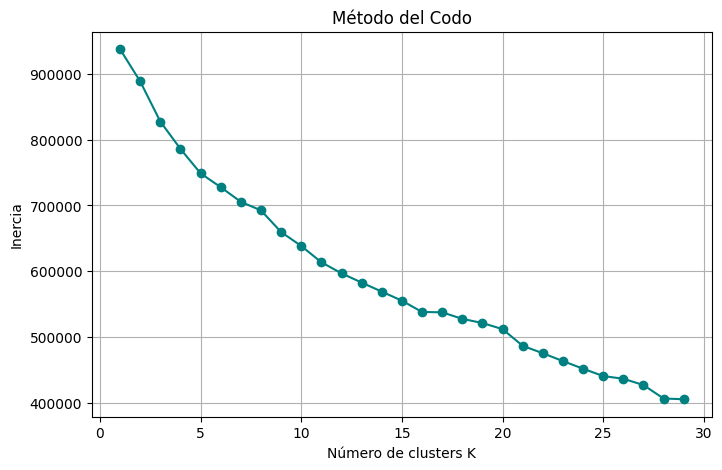

In [ ]:
inertia = []
K_range = range(1, 30)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=1)
    km.fit(data_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o', color='teal')
plt.xlabel('Número de clusters K')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.grid(True)
plt.show()

Según el gráfico anterior, podemos ver que la curva comienza a aplanarse a partir de 8 agrupaciones, es por esto que decidimos generar un modelo que nos devuelva 8 géneros.

In [ ]:
#Generamos el modelo con 8 agrupamientos

kmeans = KMeans(n_clusters=8, random_state=42)
clusters = kmeans.fit_predict(data_scaled)

df_top_75_libros['Cluster']= clusters

In [ ]:
df_top_75_libros['Cluster'].value_counts()

,count
Cluster,
2,5352
4,2263
1,1751
5,1653
7,1523
6,1469
3,1107
0,1039


In [ ]:
data_1=df_top_75_libros.groupby('Cluster').mean().T

def color_high(val):
    if  val >= 0.4:
        return 'background: skyblue'

data_1.style.applymap(color_high)

Cluster,0,1,2,3,4,5,6,7
Fiction,0.064485,0.962878,0.822309,0.447154,0.925320,0.000000,0.974132,0.804334
Fantasy,0.025024,0.782981,0.128924,0.976513,0.775961,0.000000,0.041525,0.068943
Romance,0.018287,0.166191,0.168348,0.762421,0.161290,0.008469,0.090538,0.793171
Young Adult,0.000962,0.763564,0.059604,0.496838,0.259832,0.000000,0.063989,0.397899
Classics,0.123195,0.177042,0.389574,0.009033,0.152894,0.113128,0.078285,0.007223
Nonfiction,0.905679,0.001713,0.030082,0.001807,0.001768,0.981246,0.003404,0.004596
Historical Fiction,0.005775,0.113649,0.410314,0.018970,0.047724,0.000000,0.068074,0.050558
Mystery,0.003850,0.094803,0.080904,0.104788,0.121962,0.016939,0.965963,0.113592
Contemporary,0.008662,0.036551,0.157885,0.011743,0.031816,0.008469,0.106195,0.912672
Novels,0.025987,0.014278,0.320628,0.002710,0.095007,0.000000,0.053778,0.074196


**Observaciones**

**Cluster 0 - "No ficción y reflexión"**
Generos predominantes:
- NonFiction (0.90)
- Philosopphy (0.47)
- Self Help (0.41)

**Cluster 1 - "Ficción juvenil"**
Generos predominantes:
- Fiction (0.96)
- Fantasy (0.78)
- Young Adult (0.76)

**Cluster 2 - "Novela Literaria e Histórica"**
Generos predominantes:
- Fiction (0.82)
- Historical fiction (0.41)

**Cluster 3 - "Fantasía y romance juvenil"**
Generos predominantes:
- Paranormal (0.98)
- Fantasy (0.97)
- Romance (0.76)

**Cluster 4 - "Ciencia Ficción"**
Generos predominantes:
- Fiction(0.92)
- Science fiction (0.67)

**Cluster 5 - "Historiador y biógrafo"**
Generos predominantes:
- Nonfiction (0.98)
- History (0.63)
- Biography (0.59)

**Cluster 6 - "Misterio, thiller y terror"**
Generos predominantes:
- Mystery (0.96)
- Thriller (0.86)
- Mystery thriller (0.71)
- Crime (0.65)

**Cluster 7 - "Ficción y nuevas tendencias"**
Generos predominantes:
- Contemporany (0.90)
- Fiction (0.80)
- Romance (0.79)
- Adult (0.40)

In [ ]:
#Unimos al dataset original, el número de cluster que pertenece cada género segpun book_id
df_final = pd.merge(
    df_unique,
    df_top_75_libros['Cluster'],
    right_index=True,
    left_on='book_id',
    how='inner'
)


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16157 entries, 0 to 16156
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           16157 non-null  int64  
 1   book_id              16157 non-null  int64  
 2   cover_image_uri      16157 non-null  object 
 3   book_title           16157 non-null  object 
 4   book_details         16109 non-null  object 
 5   format               16157 non-null  object 
 6   publication_info     16157 non-null  object 
 7   authorlink           16157 non-null  object 
 8   author               16157 non-null  object 
 9   num_pages            16157 non-null  object 
 10  genres               16157 non-null  object 
 11  num_ratings          16157 non-null  int64  
 12  num_reviews          16157 non-null  int64  
 13  average_rating       16157 non-null  float64
 14  rating_distribution  16157 non-null  object 
 15  rating_1             16157 non-null 

In [ ]:
# Reemplazamos el nombre de los clusters
df_final['Cluster_Nombre'] = df_final['Cluster'].map({
    0: 'No ficción y reflexión',
    1: 'Ficción juvenil',
    2: 'Novela Literaria e Histórica',
    3: 'Fantasía y romance juvenil',
    4: 'Ciencia Ficción',
    5: 'Historiador y biógrafo',
    6: 'Misterio, thiller y terror',
    7: 'Ficción y nuevas tendencias'
})

In [ ]:
df_final['Cluster_Nombre'].value_counts()

,count
Cluster_Nombre,
Novela Literaria e Histórica,5352
Ciencia Ficción,2263
Ficción juvenil,1751
Historiador y biógrafo,1653
Ficción y nuevas tendencias,1523
"Misterio, thiller y terror",1469
Fantasía y romance juvenil,1107
No ficción y reflexión,1039


In [ ]:
#Seleccionamos para cada género los 3 libros que tienen más cantidad de reseñas en el dataframe.

top_libros_por_cluster = (
    df_final.groupby(['Cluster_Nombre', 'book_title'])['num_reviews'].sum()
    .reset_index()
    .groupby('Cluster_Nombre')
    .apply(lambda x: x.nlargest(3, 'num_reviews'))
    .reset_index(drop=True)
)

top_libros_por_cluster

,Cluster_Nombre,book_title,num_reviews
0,Ciencia Ficción,1984,587628
1,Ciencia Ficción,The Hunger Games,438978
2,Ciencia Ficción,The Midnight Library,372365
3,Fantasía y romance juvenil,Twilight,132108
4,Fantasía y romance juvenil,City of Bones,76145
5,Fantasía y romance juvenil,House of Sky and Breath,59038
6,Ficción juvenil,Six of Crows,517811
7,Ficción juvenil,Throne of Glass,317158
8,Ficción juvenil,The Cruel Prince,225857
9,Ficción y nuevas tendencias,A Court of Mist and Fury,674371


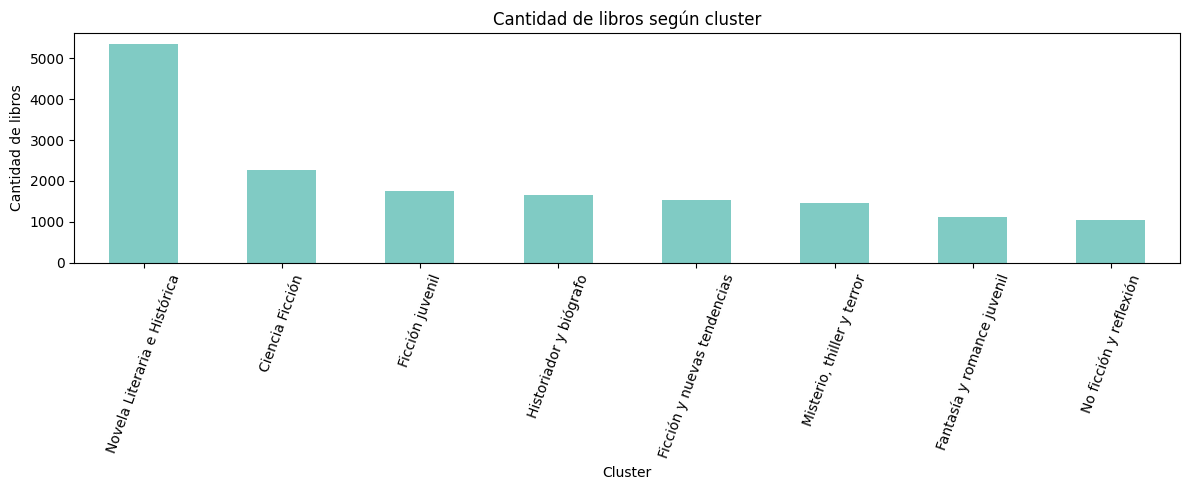

In [ ]:
# Contar la cantidad de libros por cluster
cantidad_por_cluster = df_final['Cluster_Nombre'].value_counts()

plt.figure(figsize=(12,5))
cantidad_por_cluster.plot(kind='bar', color='#80CBC4')
plt.xlabel('Cluster')
plt.ylabel('Cantidad de libros')
plt.title('Cantidad de libros según cluster')
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()




**Observaciones**

El cluster de "Novela literaria e histórica" es, con diferencia, el que agrupa la mayor cantidad de libros, superando las 5,000 unidades. Esto indica que es la categoría más frecuente dentro del conjunto de datos, según nuestra segmentación de géneros.

Los clusters de  "No ficción y reflexión" y "Fantasía y romance juvenil" son los que tienen la menor cantidad de libros, manteniéndose por debajo de las 1,000 unidades.

Existe una gran disparidad en el tamaño de los clusters. La categoría principal es casi tres veces más grande que la segunda ("Ciencia ficción").

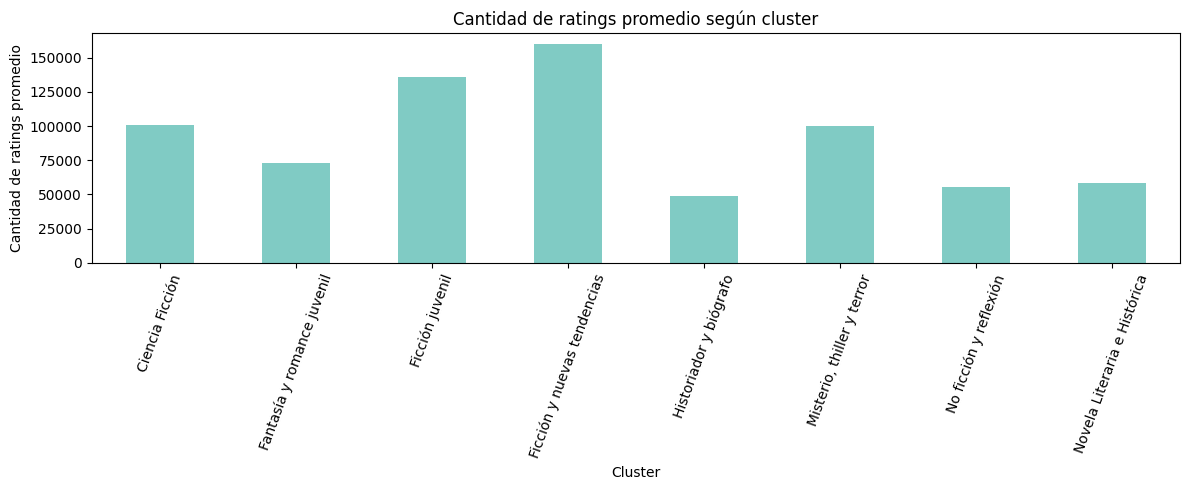

In [ ]:
# Visualizamos la media en la cantidad de ratings para cada género

ratings_por_cluster = df_final.groupby('Cluster_Nombre')['num_ratings'].mean().sort_index()

plt.figure(figsize=(12,5))
ratings_por_cluster.plot(kind='bar', color='#80CBC4')
plt.xlabel('Cluster')
plt.ylabel('Cantidad de ratings promedio')
plt.title('Cantidad de ratings promedio según cluster')
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

El género con más cantidad de calificaciones promedio es "Ficción y nuevas tendencias", seguido de "ficción juvenil". Esto puede explicarse por mucha disparidades entre libro dentro de los géneros.

El promedio puede verse afectado por valores extremos, puede que dentro de los géneros existan libros demasiado calificados que tiran para arriba el promedio o libros muy pocos calificados que lo tiren para abajo.

La disparidad entre géneros también puede explicarse al público al que representan. Libros con perfiles más de nicho como históricos o biografías pueden corresponderse con un público de mayor edad que no frecuenta dejar calificaciones en aplicaciones, en comparación con libros en tendencia y ficciones juveniles.

In [ ]:
df_unique = df_final.copy()

### Variable: **publication_info**

Se realizan las transformaciones correspondientes para quedarnos solo con el año de publicación de cada uno de los libros.

In [ ]:
df_unique['publication_info'].value_counts().head()


,count
publication_info,
"['First published January 1, 2008']",358
"['First published January 1, 2006']",156
"['First published January 1, 2007']",150
"['First published January 1, 2009']",133
"['First published January 1, 2000']",133


In [ ]:
# Convertimos la variable en una lista.
# Obtenemos el primer elemento de la lista.
# Con una expresión regular, extraemos los últimos 4 dígitos de la lista.
# Transformamos la variable a un valor entero.

df_unique['publication_info_lista'] = df_unique['publication_info'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) else x
)

df_unique['publication_info_limpio'] = df_unique['publication_info_lista'].str.get(0).astype(str)

df_unique['publication_year'] = df_unique['publication_info_limpio'].str.extract(r'(\d{4})')

df_unique['publication_year'] = pd.to_numeric(df_unique['publication_year'], errors='coerce').astype('Int64')

In [ ]:
pd.DataFrame({
    "Count" : df_unique['publication_year'].isnull().sum()[df_unique['publication_year'].isnull().sum() > 0],

    "Percentage" : (df_unique['publication_year'].isnull().sum()[df_unique['publication_year'].isnull().sum() > 0] / df_unique.shape[0]) * 100})

,Count,Percentage
0,58,0.358978


In [ ]:
df_unique['publication_info'][df_unique['publication_year'].isnull()]

,publication_info
132,"['First published January 1, 431']"
133,"['First published January 1, 801']"
134,"['First published January 1, 801']"
135,"['First published January 1, 701']"
144,"['First published January 1, 406']"
145,"['First published January 1, 459']"
146,"['First published January 1, 451']"
147,"['First published January 1, 430']"
148,"['First published January 1, 424']"
157,"['First published January 1, 8']"


Notamos que existen 58 libros que quedaron sin año de publicación.
Al analizar estos casos, notamos que son libros que tienen año de publicación de 3 cifras de 2 o de 1.

In [ ]:
# Seleccionamos los libros que tienen un año de publicación de 3 cifras.
df_unique['publication_year_2'] = df_unique['publication_info_limpio'].str.extract(r'(\d{3})')

df_unique['publication_year_2'] = pd.to_numeric(df_unique['publication_year_2'], errors='coerce').astype('Int64')

In [ ]:
#Reemplazamos los null en publication_year para los que tienen 3 cifras en el año

df_unique['publication_year'] = df_unique['publication_year'].fillna(df_unique['publication_year_2'])
df_unique.drop(columns = 'publication_year_2', inplace = True)

In [ ]:
#volvemos a controlar valores faltantes

pd.DataFrame({
    "Count" : df_unique['publication_year'].isnull().sum()[df_unique['publication_year'].isnull().sum() > 0],

    "Percentage" : (df_unique['publication_year'].isnull().sum()[df_unique['publication_year'].isnull().sum() > 0] / df_unique.shape[0]) * 100})

,Count,Percentage
0,11,0.068082


In [ ]:
#Eliminamos los 11 libros que quedaron sin datos de año de publicación
df_unique = df_unique[df_unique['publication_year'].notna()]


In [ ]:
df_unique['publication_year'].value_counts(dropna=False).head()

,count
publication_year,
2008,1312
2009,573
2007,537
2006,496
2012,462


### Variable: **average_rating**

In [ ]:
no_aveg_rating = df_unique[df_unique['average_rating'] == 0]


In [ ]:
print('Total de registros con promedio de puntuacion igual a 0:', no_aveg_rating.shape[0])
print('Total de registros del dataset:', df_unique.shape[0])
print()
print('% de registros con promedio de puntuacion igual a 0:',round((no_aveg_rating.shape[0] / df_unique.shape[0]) * 100,2))

Total de registros con promedio de puntuacion igual a 0: 12
Total de registros del dataset: 16146

% de registros con promedio de puntuacion igual a 0: 0.07


Del *describe* notamos que el valor mínimo de average rating es 0.
En la salida anterior vemos que 12 libros tienen promedio de puntuación 0, representan un 7% del total del dataset.

No es un problema los libros que tienen calificación 0.

### Variable: **format**

In [ ]:
df_unique['format'].unique()

array(["['652 pages, Paperback']", "['912 pages, Paperback']",
       "['309 pages, Hardcover']", ..., "['119 pages, Kindle Edition']",
       "['776 pages, Kindle Edition']", "['364 pages, Kindle Edition']"],
      dtype=object)

Notamos que al igual que anteriores variables, el formato se encuentra dentro de una lista.

In [ ]:
# Convertir la variable a lista.
# Eliminar [' ']
# Usear una expresión regular para qudarnos con lo que está despúes de la coma
# En caso que no haya nada despúes de la coma usa la cadena completa
# Limpieza de espacios finales y conteo de cantidad de formatos diferentes.
df_unique['format_clean'] = df_unique['format'].str.replace(r"^\[\s*'", '', regex=True)
df_unique['format_clean'] = df_unique['format_clean'].str.replace(r"'\s*\]$", '', regex=True)

df_unique['formato_solo'] = (
    df_unique['format_clean']
    .str.extract(r',\s*(.*?)$', expand=False)
    .fillna(df_unique['format_clean'])
)


df_unique['formato_solo'] = df_unique['formato_solo'].str.strip()



df_unique['formato_solo'].value_counts(normalize=True)



,proportion
formato_solo,
Paperback,0.505326
Hardcover,0.288926
Mass Market Paperback,0.093212
Kindle Edition,0.071782
ebook,0.022916
...,...
336 pages,0.000062
300 pages,0.000062
591 pages,0.000062


In [ ]:
# Libros que tienen cómo formato pages debido a que no tienen nada despúes de la coma

filtro_pages = df_unique['formato_solo'].str.contains(r'pages', case=False, na=False)

libros_con_pages = df_unique[filtro_pages]

print("--- Libros con 'pages' en el formato (Inspección) ---")
print(libros_con_pages[['book_title', 'format', 'formato_solo']].head(10))
print(f"\nTotal de libros a inspeccionar: {len(libros_con_pages)}")

--- Libros con 'pages' en el formato (Inspección) ---
                                         book_title         format  \
1229  The Doors of His Face, the Lamps of His Mouth  ['512 pages']   
1627                  In the Country of Last Things  ['188 pages']   
2070                               The Dying Animal  ['156 pages']   
3856                         The Busconductor Hines  ['237 pages']   
3906                              Beezus and Ramona  ['160 pages']   
4941                                           Page  ['290 pages']   
5157                                    Annabel Lee   ['24 pages']   
6951                           The Cradle Will Fall  ['314 pages']   
7902                     How the Steel Was Tempered  ['376 pages']   
8090                        The Ransom of Red Chief   ['32 pages']   

     formato_solo  
1229    512 pages  
1627    188 pages  
2070    156 pages  
3856    237 pages  
3906    160 pages  
4941    290 pages  
5157     24 pages  
6951    314 pag

In [ ]:
# Reemplazamos a las variables que tienen "pages" en el nuevo formato por Nan
filtro_pages = df_unique['formato_solo'].str.contains(r'pages', case=False, na=False)

df_unique.loc[filtro_pages, 'formato_solo'] = np.nan

conteo_nan_formato_nuevo = df_unique['formato_solo'].isna().sum()

conteo_nan_formato_nuevo.sum()


np.int64(57)

In [ ]:
#Visulizamos la frecuencia absoluta para determinar los formatos relevantes.
df_unique['formato_solo'].value_counts(normalize=True)

frecuencia_acumulada = frecuencia_relativa.cumsum()
frecuencia_relativa = df_unique['formato_solo'].value_counts(normalize=True)

frecuencia_acumulada

,0
12th Century,0.000038
13th Century,0.000066
15th Century,0.000085
16th Century,0.000207
17th Century,0.000283
...,...
Young Adult Historical Fiction,0.999086
Young Adult Paranormal,0.999105
Young Adult Romance,0.999407
Zimbabwe,0.999425


Notamos que existen tres formatos principales: Paper, hardcover y kindle.

Decidimos agrupar kindle e ebook en una única categoría para abarcar un formato más global ya que son parecidos y quedarnos con los dos formatos principales y este tercero. Para englobar el resto de los formatos generamos una categoría "otros".

In [ ]:
# Creamos una variable formato con las tres categorías principales
df_unique['formato'] = df_unique['formato_solo'].str.replace(r'(?i).*paperback.*', 'Paperback', regex=True)
df_unique['formato'] = df_unique['formato_solo'].str.replace(r'(?i).*hardcover.*', 'Hardcover', regex=True)
df_unique['formato'] = df_unique['formato_solo'].str.replace(r'(?i).*(kindle|ebook).*', 'Kindle/eBook', regex=True)

In [ ]:
# Reemplazamos los null por categoría "other"
df_unique.loc[
    df_unique['formato'].notna() &
    ~df_unique['formato'].isin(['Paperback', 'Hardcover', 'Kindle/eBook']),
    'formato'
] = 'Other'

In [ ]:
df_unique['formato'].value_counts(normalize = True)

,proportion
formato,
Paperback,0.507117
Hardcover,0.289950
Other,0.107900
Kindle/eBook,0.095034


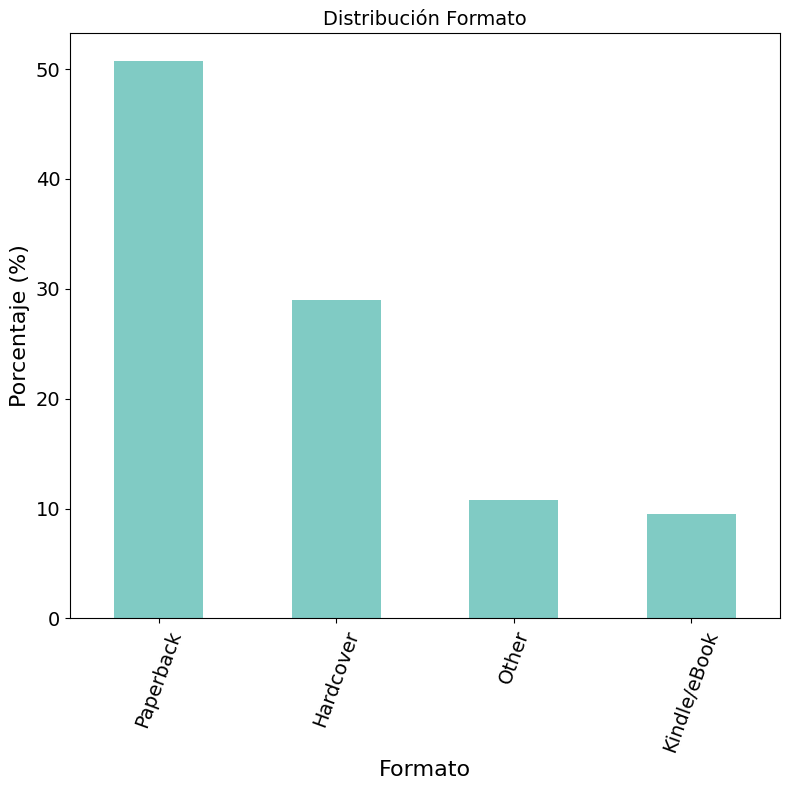

In [ ]:
proporciones_formato = df_unique['formato'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 8))

proporciones_formato.plot(
    kind='bar',
    color='#80CBC4'
)

plt.xlabel('Formato', fontsize=16)
plt.ylabel('Porcentaje (%)', fontsize=16)

plt.title('Distribución Formato', fontsize=14)

plt.xticks(rotation=70, fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

Vemos que la mitad de los libros cuentan con un formato en papel, seguido de aqullos libros que tienen tapa dura. Kindle/eBook es el formato con menos proporción.

### Variable: **num_pages**

En este caso, la transformación aparentaba muy sencilla: eliminar los paréntesis rectos y comillas y también convertir la variable a numérica.

In [ ]:
df_unique['num_pages'].head()

,num_pages
0,['652']
1,['912']
2,['309']
3,['435']
4,['734']


In [ ]:
#Nos quedamos solo con la cantidad de páginas y la convertimos en variable numérica

df_unique['num_pages'] = (
    df_unique['num_pages']
    .astype(str)
    .str.replace("[\[\]\'\s]", '', regex=True)
)

df_unique['num_pages'] = pd.to_numeric(df_unique['num_pages'], errors='coerce')

In [ ]:
df_unique['num_pages'].value_counts(dropna=False).head()

,count
num_pages,
NaN,274
320.0,269
288.0,253
352.0,251
304.0,234


In [ ]:
df_unique['num_pages'].describe()


,num_pages
count,15872.000000
mean,362.278919
std,255.081625
min,1.000000
25%,241.000000
50%,328.000000
75%,426.000000
max,8258.000000


In [ ]:
pd.DataFrame({
    "Count" : df_unique['num_pages'].isnull().sum()[df_unique['num_pages'].isnull().sum() > 0],

    "Percentage" : (df_unique['num_pages'].isnull().sum()[df_unique['num_pages'].isnull().sum() > 0] / df_unique['num_pages'].shape[0]) * 100})

,Count,Percentage
0,274,1.697015


En promedio los libros tienen 362 páginas. Hay outliers considerables, ya que el libro que tiene menos páginas tiene 1 sola y el que tiene más tiene 8258.


Tenemos 274 libros que no tienen cantidad de páginas, a estos valores decidimos imputarle la mediana según el género.

In [ ]:
#Notamos que algunos formatos tienen la cantidad de páginas. Entonces, en caso que num_pages sea null intentaremos extraer esta información de la variable format.

df_unique['format_pages'] = df_unique['format'].str.extract(r'(\d+) pages')

df_unique['format_pages'] = pd.to_numeric(df_unique['format_pages'])

df_unique['num_pages'] = df_unique['num_pages'].fillna(df_unique['format_pages'])

In [ ]:
#eliminamos la variable creada temporalmente para hacer el paso anterior

df_unique.drop(columns = 'format_pages', inplace = True)

In [ ]:
pd.DataFrame({
    "Count" : df_unique['num_pages'].isnull().sum()[df_unique['num_pages'].isnull().sum() > 0],

    "Percentage" : (df_unique['num_pages'].isnull().sum()[df_unique['num_pages'].isnull().sum() > 0] / df_unique['num_pages'].shape[0]) * 100})

,Count,Percentage
0,216,1.337793


Con el código anterior logramos imputar a 58 libros el número de páginas.
Sin embargo, seguimos teniendo un 1.3% de libros sin número de páginas. Decidimos imputarle la mediana según su género.

In [ ]:
df_unique.groupby('Cluster_Nombre').num_pages.describe()

,count,mean,std,min,25%,50%,75%,max
Cluster_Nombre,,,,,,,,
Ciencia Ficción,2244.0,378.285205,286.725975,1.0,240.0,336.0,448.00,6680.0
Fantasía y romance juvenil,1097.0,388.964448,233.042413,8.0,302.0,356.0,420.00,3248.0
Ficción juvenil,1738.0,369.580552,391.845129,1.0,210.5,322.0,440.00,8258.0
Ficción y nuevas tendencias,1505.0,361.716279,130.717725,6.0,290.0,341.0,410.00,1859.0
Historiador y biógrafo,1634.0,370.121175,238.771317,3.0,252.0,320.0,417.75,4272.0
"Misterio, thiller y terror",1456.0,383.465659,137.391537,7.0,308.0,371.0,436.00,1796.0
No ficción y reflexión,1017.0,319.410029,234.866653,2.0,206.0,274.0,362.00,2752.0
Novela Literaria e Histórica,5239.0,346.897118,248.533863,1.0,208.0,309.0,427.00,6576.0


In [ ]:
#Le imputamos a los libros que tienen numero de paginas faltantes la mediana de su género

df_unique.groupby('Cluster_Nombre')['num_pages'].transform('median')

df_unique['num_pages'] = df_unique['num_pages'].fillna(value=df_unique.groupby('Cluster_Nombre')['num_pages'].transform('median'))

In [ ]:
#Chequeamos nulos nueva,ente
df_unique[df_unique['num_pages'].isna()].formato.value_counts()

,count
formato,


In [ ]:
#Cantidad de libros con 1 página
df_unique[['book_title', 'formato','format']][df_unique['num_pages'] == 1]


,book_title,formato,format
3794,The Enchanted Forest Chronicles,Paperback,"['1 pages, Paperback']"
4177,"In Yana, the Touch of Undying",Other,"['1 pages, Mass Market Paperback']"
5552,Rigadoon,Paperback,"['1 pages, Paperback']"
7193,Saga of Darren Shan Box Set,Paperback,"['1 pages, Paperback']"
9985,Space Casey,Other,"['1 pages, Podiobook']"
10313,Doctor Who: The Forever Trap,Other,"['1 pages, Audiobook']"
12401,Death and What Comes Next,Kindle/eBook,"['1 pages, ebook']"


In [ ]:
df_unique[df_unique['num_pages']>5000].book_title


,book_title
1818,The Complete Aubrey/Maturin Novels
9899,Animorphs
12233,A Song of Ice and Fire
13356,Worm
13456,The Complete Malazan Book of the Fallen


Al chequear los extremos de la variable num_pages, vemos que los libros que tienen más de 5000 páginas se deben a sagas enteras, por lo que no lo consideramos un problema de datos.

Diferente es el caso en dónde el libro tiene 1 página, libros con formato papel resulta extraño que solamente tengan 1 página, al igual que aquellos audiolibros en dónde no deberían tener páginas. Por esta razón y cómo son solo 7 observaciones, decidimos eliminarlas.

In [ ]:
#Eliminar observaciones con número de paginas 1

filtro_a_mantener = df_unique['num_pages'] != 1
df_unique = df_unique[filtro_a_mantener]

### Variable: **ratio_reviews**

Esta variable busca capturar qué tanto debatieron los lectores sobre el libro.

Los libros que generan emociones extremas, ya sean positivas o negativas, motivan a las personas a escribir una reseña, mas allá de puntuar el libro.

In [ ]:
df_unique['ratio_reviews'] = (df_unique['num_reviews']/df_unique['num_ratings']).round(2)

In [ ]:
#Vemos que todos los libros tengan asignado un ratio
print("cantidad de ratio_reviews NaN: ", df_unique['ratio_reviews'].isna().value_counts(normalize=True))
print(df_unique[df_unique['ratio_reviews'].isna()][['book_id','num_reviews', 'num_ratings']])

cantidad de ratio_reviews NaN:  ratio_reviews
False    0.999256
True     0.000744
Name: proportion, dtype: float64
        book_id  num_reviews  num_ratings
8770    1784319            0            0
10219   4415879            0            0
10344   4983620            0            0
10639   6165928            0            0
12387  13060619            0            0
14638  36141495            0            0
15568  56984085            0            0
15578  57226981            0            0
15736  59588437            0            0
15799  60471092            0            0
15835  60973653            0            0
15897  61834758            0            0


In [ ]:
# Imputamos a los libros con NA 0

df_unique['ratio_reviews'] = df_unique['ratio_reviews'].fillna(0)

### Variable: **rating x %**

Agregamos el porcentaje de ratings, ya que nos ayuda a entender la distribución de las puntuaciones eliminndo el efecto de la cantidad de puntuaciones que recibe y hacerla más comparable. No es lo mismo un libro que tiene 3 pts en promedio porque 100 personas lo puntuaron en 3, que si tiene 3 en promedio por una alta polarización de la opinión del público (mitad 5 estrellas y mitad 1 estrella).

In [ ]:
#agregar el % de ratings en cada uno
df_unique['rating_5_pct'] = df_unique['rating_5']/df_unique['num_ratings']
df_unique['rating_4_pct'] = df_unique['rating_4']/df_unique['num_ratings']
df_unique['rating_3_pct'] = df_unique['rating_3']/df_unique['num_ratings']
df_unique['rating_2_pct'] = df_unique['rating_2']/df_unique['num_ratings']
df_unique['rating_1_pct'] = df_unique['rating_1']/df_unique['num_ratings']

In [ ]:
#Chequeamos la correcta creación de las variables
print("cantidad de libros con rating 5 NaN: ", df_unique['rating_5_pct'].isna().value_counts(normalize=True))
print("cantidad de libros con rating 4 NaN: ", df_unique['rating_4_pct'].isna().value_counts(normalize=True))
print("cantidad de libros con rating 3 NaN: ", df_unique['rating_3_pct'].isna().value_counts(normalize=True))
print("cantidad de libros con rating 2 NaN: ", df_unique['rating_2_pct'].isna().value_counts(normalize=True))
print("cantidad de libros con rating 1 NaN: ", df_unique['rating_1_pct'].isna().value_counts(normalize=True))

cantidad de libros con rating 5 NaN:  rating_5_pct
False    0.999256
True     0.000744
Name: proportion, dtype: float64
cantidad de libros con rating 4 NaN:  rating_4_pct
False    0.999256
True     0.000744
Name: proportion, dtype: float64
cantidad de libros con rating 3 NaN:  rating_3_pct
False    0.999256
True     0.000744
Name: proportion, dtype: float64
cantidad de libros con rating 2 NaN:  rating_2_pct
False    0.999256
True     0.000744
Name: proportion, dtype: float64
cantidad de libros con rating 1 NaN:  rating_1_pct
False    0.999256
True     0.000744
Name: proportion, dtype: float64


In [ ]:
#Remplazamos todos los porcentajes NAN con 0
df_unique['rating_5_pct'] = df_unique['rating_5_pct'].fillna(0)
df_unique['rating_4_pct'] = df_unique['rating_4_pct'].fillna(0)
df_unique['rating_3_pct'] = df_unique['rating_3_pct'].fillna(0)
df_unique['rating_2_pct'] = df_unique['rating_2_pct'].fillna(0)
df_unique['rating_1_pct'] = df_unique['rating_1_pct'].fillna(0)

### Variable: **antiguedad**

In [ ]:
df_unique['antiguedad'] = 2025 - df_unique['publication_year']

# **3. Definición de variable dependiente**


rating_5_pct
Skew : 0.57


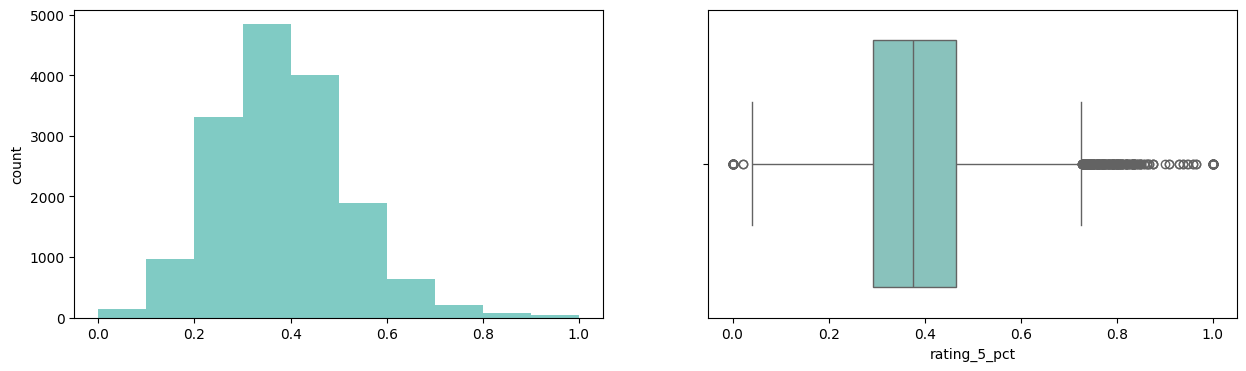

rating_4_pct
Skew : -0.82


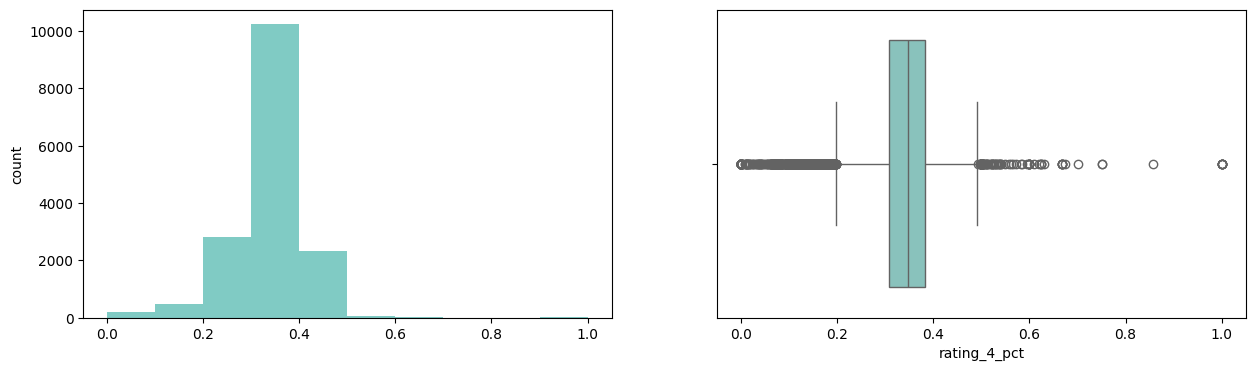

rating_3_pct
Skew : 0.32


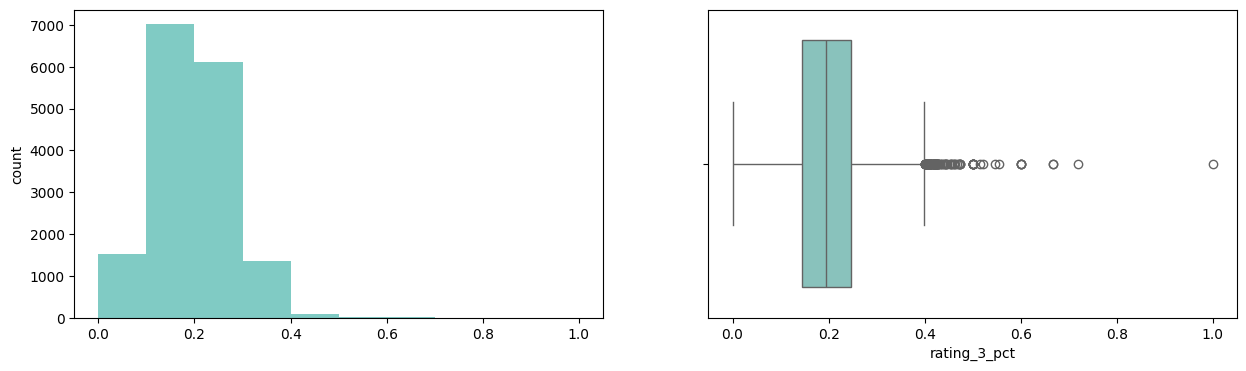

rating_2_pct
Skew : 3.1


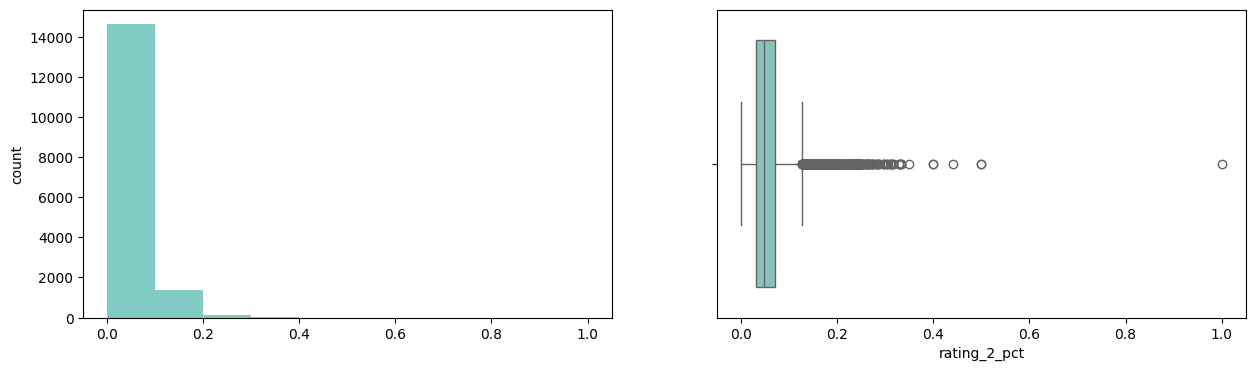

rating_1_pct
Skew : 11.48


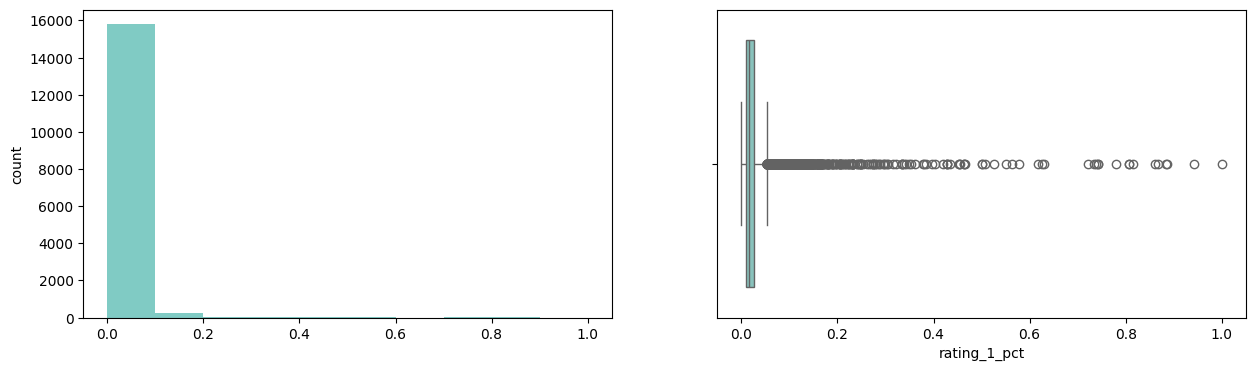

num_ratings
Skew : 12.95


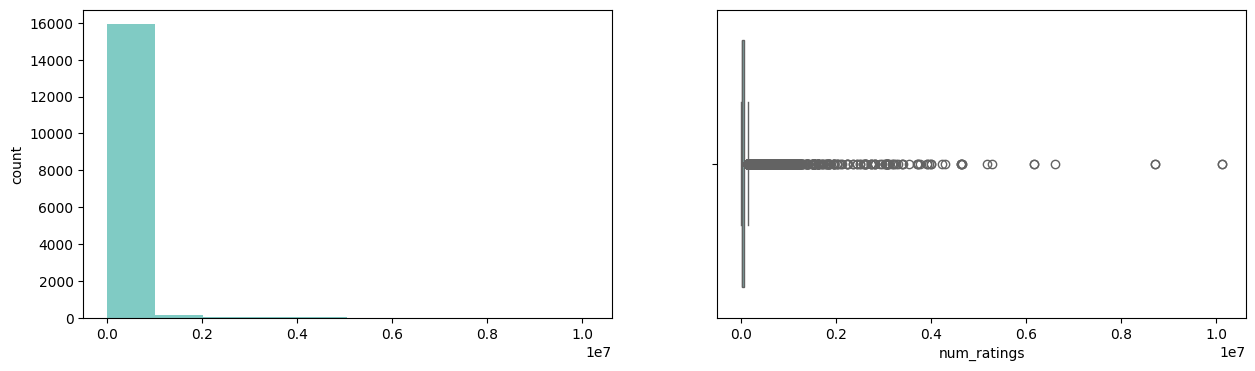

average_rating
Skew : -2.19


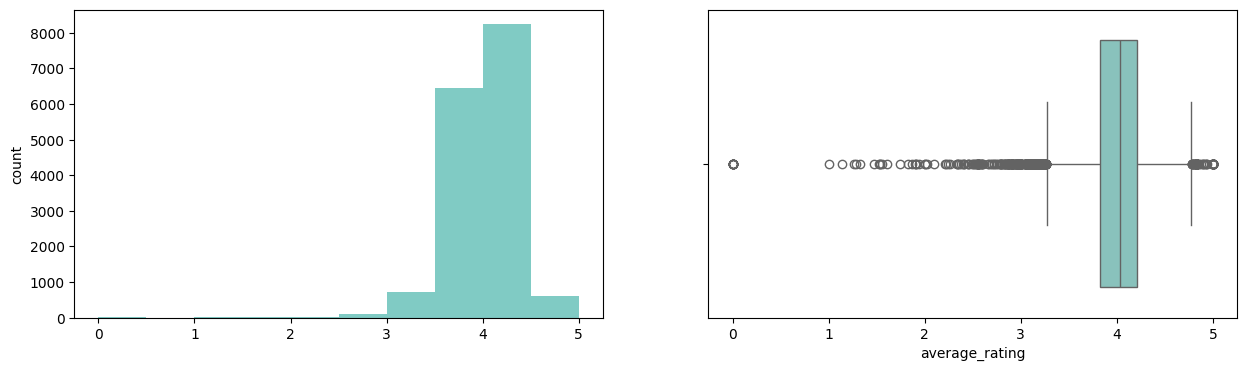

In [ ]:
#Seleccionamos las posibles variables dependientes segun nuestro objetivo y generamos gráfico de distribución para ver su comportamiento

data_numeric = df_unique[['rating_5_pct',
'rating_4_pct',
'rating_3_pct',
'rating_2_pct',
'rating_1_pct',
'num_ratings',
'average_rating']]
for col in data_numeric.columns:
    print(col)
    print('Skew :',round(data_numeric[col].skew(),2))
    plt.figure(figsize=(15,4))
    plt.subplot(1,2,1)
    data_numeric[col].hist(bins=10, grid=False, color='#80CBC4')
    plt.ylabel('count')
    plt.subplot(1,2,2)
    sns.boxplot(x=data_numeric[col], color='#80CBC4')
    filename = f'{col}_rating_analysis.png'
    plt.savefig(filename)
    plt.show()


**Observaciones:**

*  El análisis de la distribución de average_ratings podemos ver que el promedio
de estrellas es una métrica de muy baja diferenciación, la mitad de los libros se concentran entre 3.8 y 4.2, mirando el boxplot. Además, del histograma vemos una skew de -2.31, esta variable se encuentra sesgada a la izquierda, con mucho average_rating en valores altos y los libros con average de 3.3 o menos son outliers.

El `average_rating` no sería una buena métrica, por sí sola, para considerar un libro "popular" porque no presenta mucha diferenciación entre la gran mayoría de los libros.

*  De la distribución de `num_ratings`. Vemos que está muy sesgada a valores bajos, existen libros tan populares que reciben más valoraciones que el resto, como vimos al inicio, muchos libros son puntuados por pocos clientes pero algunos pocos libros tienen muchísimas puntuaciones.

Esta variable tampoco explica por sí sola el éxito de un libro o su popularidad, debido a que a pesar de tener muchas calificaciones, estas pueden ser bajas.

*  En las variables de rating_1, rating_2, rating_3, rating_4 y rating_5, podemos ver como la media es mayor en libros con rating_5 (40% o menos de calificaciones 5) y a medida que la puntuación baja la mediana va bajando. Es decir, los usuarios califican generalmente cuando un libro les gusta. Haciendo que tampoco sea por ellos mismos, una variable buena para nuestro objetivo.

Es por estas razones que decidimos contruir un NPS-ajustado.

El NPS se calcula como (%Promotores - %Detractores), considerando promotores únicamente a los que puntúan 5 y detractores a los que puntúan 1,2 y 3. Considerando como neutro 4 (personas que no les gusta lo suficiente como para recomendar el libro).

El problema con el NPS simple es que para aquellos que tiene poca cantidad de calificaciones y en valores altos, siempre van a tener un buen NPS, es por eso que decidimos ajustarlo con un umbral, a definir, que represente el mínimo de calificaciones necesarias para asegurarnos un score más confiable.

## **NPS**


In [ ]:
#Porcentaje de calificaciones promotores
df_unique['promotores'] = df_unique['rating_5']/df_unique['num_ratings']

In [ ]:
#Porcentaje de calificaciones detractores
df_unique['detractores'] = (df_unique['rating_1']+df_unique['rating_2']+df_unique['rating_3'])/df_unique['num_ratings']

In [ ]:
#Definición de NPS

df_unique['NPS_book'] = ((df_unique['promotores'] - df_unique['detractores']) * 100).round(0)

In [ ]:
#Total de NPS del dataset
total_promotores = df_unique['rating_5'].sum()
total_detractores = (df_unique['rating_1']+df_unique['rating_2']+df_unique['rating_3']).sum()
total_NPS = ((total_promotores - total_detractores) / (df_unique['num_ratings'].sum())*100).round(0)

total_NPS

np.float64(19.0)

In [ ]:
df_unique.columns

Index(['Unnamed: 0', 'book_id', 'cover_image_uri', 'book_title',
       'book_details', 'format', 'publication_info', 'authorlink', 'author',
       'num_pages', 'genres', 'num_ratings', 'num_reviews', 'average_rating',
       'rating_distribution', 'rating_1', 'rating_2', 'rating_3', 'rating_4',
       'rating_5', 'genres_clean', 'Cluster', 'Cluster_Nombre',
       'publication_info_lista', 'publication_info_limpio', 'publication_year',
       'format_clean', 'formato_solo', 'formato', 'ratio_reviews',
       'rating_5_pct', 'rating_4_pct', 'rating_3_pct', 'rating_2_pct',
       'rating_1_pct', 'antiguedad', 'promotores', 'detractores', 'NPS_book'],
      dtype='object')

promotores
Skew : 0.58


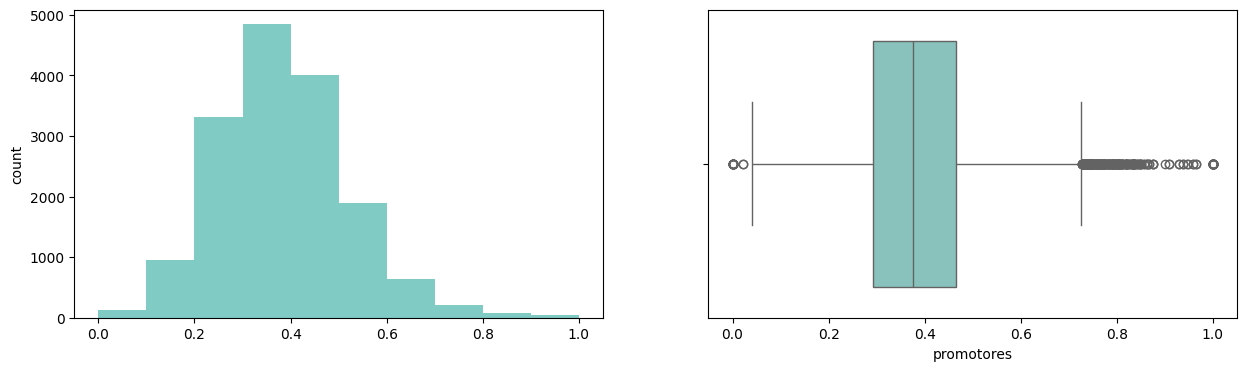

detractores
Skew : 0.91


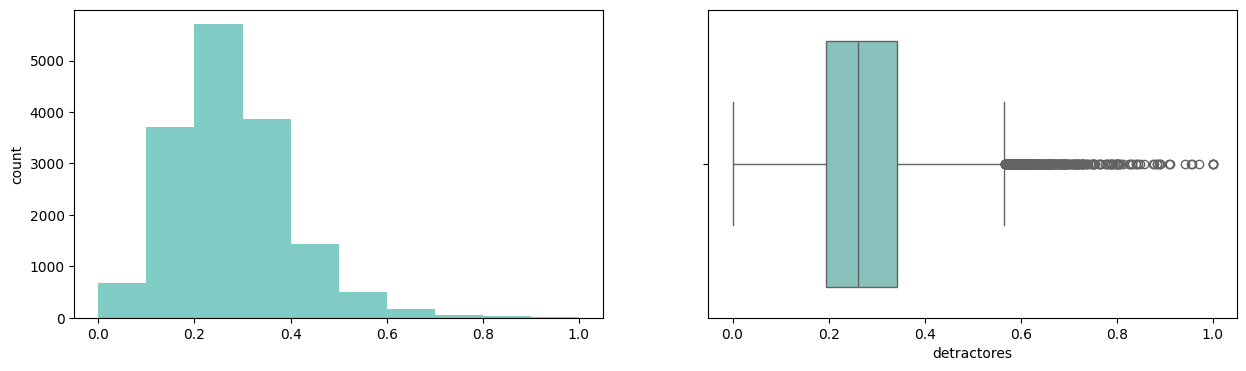

NPS_book
Skew : -0.12


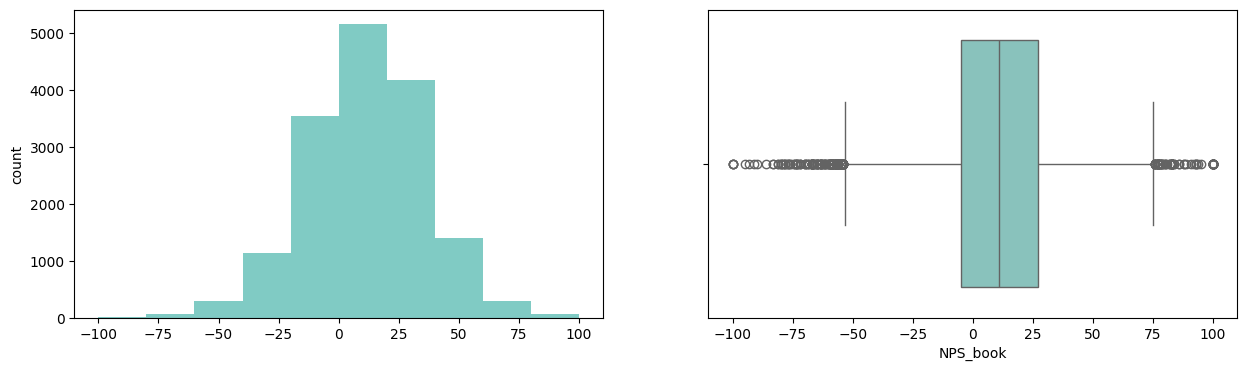

In [ ]:
data_aux = df_unique[['promotores', 'detractores', 'NPS_book']]


for col in data_aux.columns:
    print(col)
    print('Skew :',round(data_aux[col].skew(),2))
    plt.figure(figsize=(15,4))
    plt.subplot(1,2,1)
    data_aux[col].hist(bins=10, grid=False, color='#80CBC4')
    plt.ylabel('count')
    plt.subplot(1,2,2)
    sns.boxplot(x=data_aux[col], color='#80CBC4')
    filename = f'{col}_rating_analysis.png'
    plt.savefig(filename)
    plt.show()

Como vemos en la salida, la proporción media de promotores es mayor que la de detractores. Esto se debe aque los usuarios que se toman el tiempo de calificar tienden a hacerlo cuando la experiencia es muy positiva (5 estrellas), lo cual sesga el NPS hacia el lado positivo.

Aunque la métrica es proporcional porque utiliza num_ratings para generarse, entendemos que una proporción basada en muy pocas observaciones (ej. 1 rating total) puede ser estadísticamente inestable porque otorgaría un NPS 100 si la calificación dada es 5, mientras que un libro con 6 calificaciones de las cuales 5 son promotores y 1 detractor daría un NPS 66, y no resulta confiable en la definición de popularidad planteada. Por lo tanto, el verdadero riesgo no es la falta de ajuste por volumen, sino la baja participación. Por esta razón, decidimos generar un NPS que penalice más los libros que tienen baja participación de usuarios.

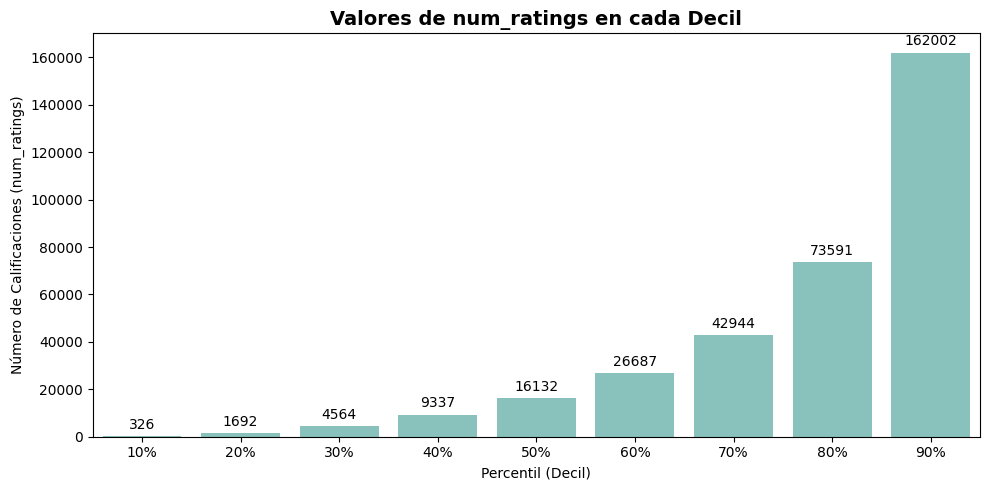

In [ ]:
deciles_a_calcular = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Calcula todos los deciles variable num_ratings
deciles = df_unique['num_ratings'].quantile(deciles_a_calcular)

df_deciles = deciles.reset_index()
df_deciles.columns = ['Decil', 'Valor_num_ratings']
df_deciles['Decil'] = (df_deciles['Decil'] * 100).astype(int).astype(str) + '%'

plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Decil', y='Valor_num_ratings', data=df_deciles, color='#80CBC4')


plt.title('Valores de num_ratings en cada Decil', fontsize=14, fontweight='bold')
plt.xlabel('Percentil (Decil)')
plt.ylabel('Número de Calificaciones (num_ratings)')
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

Para elegir el umbral de participación vemos los deciles de la variable `num_ratings`.

Al analizar la distribución de la variable num_ratings a través de los deciles, observamos que el número de calificaciones aumenta de forma considerable a partir del percentil 7. Esto indica que, a partir de este punto, los libros comienzan a recibir una cantidad mucho mayor de valoraciones por parte de los usuarios.

En otras palabras, los títulos ubicados en los deciles superiores (especialmente el 80% y el 90%) son los que concentran la mayor participación de los lectores, reflejando una mayor exposición y popularidad. Por lo tanto, el percentil 70 puede considerarse un umbral adecuado para identificar los libros con un nivel significativo de interacción o visibilidad dentro del conjunto de datos.

In [ ]:
umbral = deciles[0.7]
umbral

np.float64(42943.6)

In [ ]:
df_unique['NPS_ajustado'] = (((df_unique['NPS_book'] * df_unique['num_ratings']) + (umbral * total_NPS)) / (df_unique['num_ratings'] + umbral)).round(0)

In [ ]:
df_unique[['NPS_ajustado', 'NPS_book', 'num_ratings', 'average_rating', 'promotores', 'detractores', 'rating_4', 'book_title']]

,NPS_ajustado,NPS_book,num_ratings,average_rating,promotores,detractores,rating_4,book_title
0,59.0,60.0,3292516,4.58,0.681592,0.083017,775028,Harry Potter and the Half-Blood Prince
1,53.0,53.0,3401709,4.50,0.640490,0.107820,856178,Harry Potter and the Order of the Phoenix
2,53.0,53.0,10116247,4.47,0.646934,0.120926,2348390,Harry Potter and the Sorcerer's Stone
3,60.0,60.0,4215031,4.58,0.686192,0.083634,970190,Harry Potter and the Prisoner of Azkaban
4,59.0,59.0,3718209,4.57,0.672386,0.085698,899496,Harry Potter and the Goblet of Fire
...,...,...,...,...,...,...,...,...
16152,19.0,-12.0,129,3.77,0.279070,0.403101,41,Finistère
16153,19.0,75.0,4,4.75,0.750000,0.000000,1,The Descent
16154,19.0,39.0,986,4.32,0.475659,0.087221,431,FDR Unmasked: 73 Years of Medical Cover-ups That Rewrote History
16155,20.0,62.0,1109,4.61,0.688909,0.071235,266,Code Yellow in Gretna Green


<Axes: xlabel='NPS_book', ylabel='Count'>

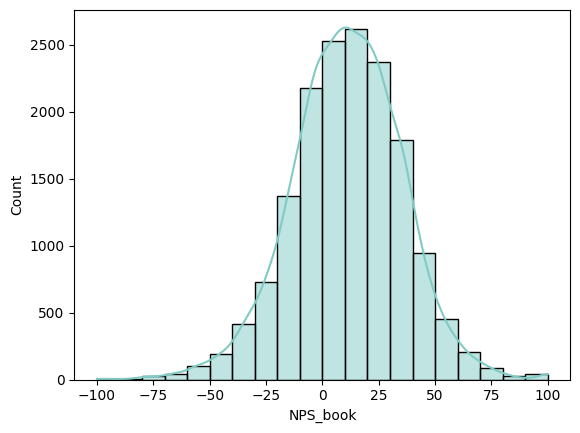

In [ ]:
#histograma NPS
sns.histplot(data=df_unique, x='NPS_book', bins=20, kde=True, color='#80CBC4')

<Axes: xlabel='NPS_ajustado', ylabel='Count'>

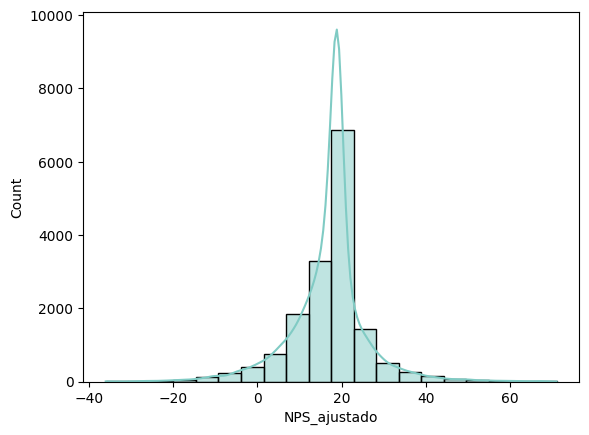

In [ ]:
#histograma NPS_ajustado

sns.histplot(data=df_unique, x='NPS_ajustado', bins=20, kde=True, color='#80CBC4')

## ¿Cómo interpretar el NPS?

$$
\text{NPS}_{\text{ajustado}} = \frac{(\text{NPS}_{\text{libro}} \cdot \text{num_ratings}) + (\text{umbral} \cdot \text{total_nps})}{(\text{num_ratings} + \text{umbral})}
$$


Al observar la tabla, se puede notar que los libros con un mayor número de calificaciones (num_ratings) tienden a tener un average_rating más alto y valores de NPS y NPS_ajustado positivos.

Por ejemplo, los títulos de Harry Potter presentan un número elevado de calificaciones (superior a los 3 millones en algunos casos) y un average_rating alrededor de 4.5–4.6, lo que se traduce en un NPS_ajustado alto (entre 58 y 60). Esto refleja una percepción muy positiva por parte de los lectores y una alta consistencia en la valoración general.

En contraste, libros con pocas calificaciones, como *Finistère* o *The Descent*, presentan un average_rating más bajo (alrededor de 3.7–3.9) y un NPS_ajustado cercano o incluso negativo, lo que indica una valoración menos favorable y posiblemente más dispersa.

En conclusión, se observa una relación directa entre la cantidad de calificaciones y la estabilidad del NPS: a medida que aumenta el número de ratings, las métricas de satisfacción (NPS y NPS ajustado) tienden a estabilizarse y reflejar mejor la opinión general de los lectores.

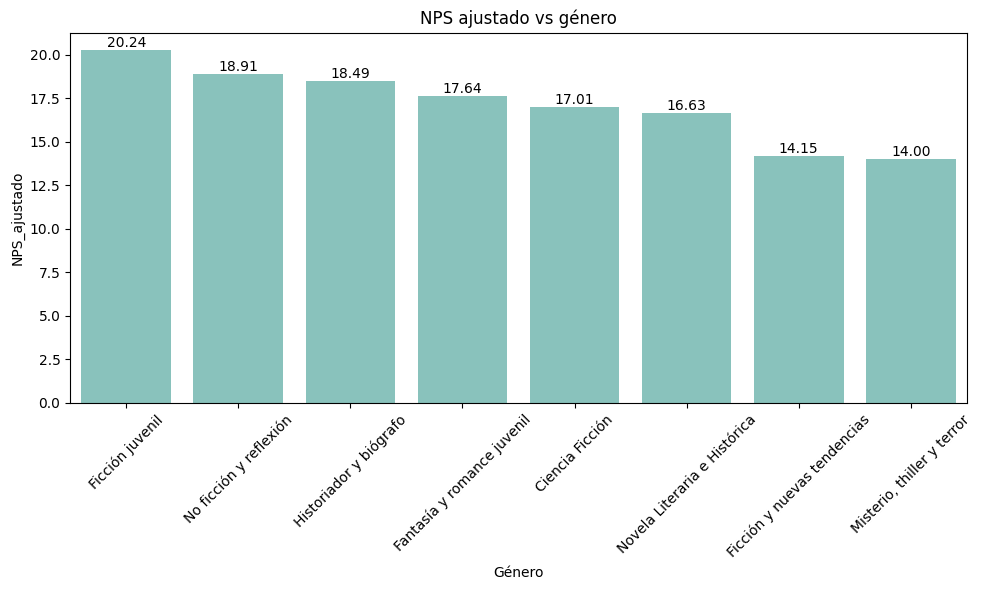

In [ ]:
#Visualización de NPS ajustado por género

genero_vs_NPS= df_unique.groupby('Cluster_Nombre')['NPS_ajustado'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=genero_vs_NPS.index,
    y=genero_vs_NPS.values,
    color='#80CBC4'
)

plt.title('NPS ajustado vs género')
plt.xlabel('Género')
plt.ylabel('NPS_ajustado')

# Rotar etiquetas del eje X
plt.xticks(rotation=45)


for i, v in enumerate(genero_vs_NPS.values):
    ax.text(i, v, f'{v:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()



In [ ]:
df_unique.groupby('Cluster_Nombre')['NPS_ajustado'].describe()

,count,mean,std,min,25%,50%,75%,max
Cluster_Nombre,,,,,,,,
Ciencia Ficción,2260.0,17.007080,9.234774,-28.0,13.75,18.0,20.0,64.0
Fantasía y romance juvenil,1107.0,17.637760,8.447891,-20.0,13.00,18.0,22.0,55.0
Ficción juvenil,1749.0,20.237278,9.887772,-19.0,15.00,19.0,24.0,71.0
Ficción y nuevas tendencias,1523.0,14.147078,11.949990,-31.0,8.00,16.0,19.0,67.0
Historiador y biógrafo,1653.0,18.485783,7.642628,-27.0,17.00,19.0,20.0,63.0
"Misterio, thiller y terror",1469.0,14.003404,9.193536,-36.0,10.00,16.0,19.0,50.0
No ficción y reflexión,1037.0,18.908390,7.101192,-11.0,17.00,19.0,21.0,55.0
Novela Literaria e Histórica,5329.0,16.626196,7.889455,-35.0,14.00,19.0,19.0,64.0


El género que tiene más libros son *"Novela Literaria e Histórica"* y *"Ciencia ficción*".

Observando la media de NPS-ajustado por género, podemos ver que los que presentan mejor puntaje son "Ficción juvenil", "No ficción y reflexión" y "Historiador y biógrafo" con un NPS ajustado promedio de 20 y 18 en los últimos dos.

Por otro lado, "Misterio, thriller y terror" y "Ficción y nuevas tendencias" son los dos géneros con el NPS ajustado más bajo, NPS ajustado de 14.


"Ficción y nuevas tendencias", "Misterio, thiller y terror", "Ciencia ficción" y "Ficción juvenil" son lo que presentan mayor variabilidad de NPS ajustado. En el caso del primero, alcanza mínimos de NPS ajustado de  -31 y máximos de 67.

Como vemos cada género en sí es diferente según el NPS-ajustado. Se decide generar una variable que sea popular/no popular teniendo en cuenta el cluster al que pertenecen.

## Variable dependiente: POPULAR/NO POPULAR

Para generar la variable dependiente teniendo en cuenta los géneros, vamos a realizar el siguiente proceso:

1. Aplicar a la variable NPS-ajustado un ajuste de Z-score teniendo en cuenta la media y la viarianza de cada género. De esta forma tendríamos un valor que ajusta para cada género en torno a su promedio, valores por encima de 0 implican libros con un mejor NPS-ajustado que el promedio del género al que pertenecen, mientras que valores por debajo de 0 implican libros con un NPS- ajustado por debajo del promedio al género al que pertenecen.

2. Luego de tener el Zscore de NPS-ajustado, seleccionaremos un umbral en base a los percentiles de la métrica creada en dónde el crecimíento sea exponencial y de esa forma catpurar los libros que tiene un NPS ajustado más grande que el promedio del género al que pertenecen.

3. Una vez definido el umbral, todos los libros que estén por encima del umbral serán etiquetados con "popular"=1 mientras que los que se encuentren por debajo serán "No popular"=0.

In [ ]:
#Estandarización de NPS según cada género

stats_genero = df_unique.groupby('Cluster_Nombre')['NPS_ajustado'].agg(['mean', 'std'])

df_unique = df_unique.merge(stats_genero, on='Cluster_Nombre', how='left')

df_unique['NPS_zscore_genero'] = (df_unique['NPS_ajustado'] - df_unique['mean']) / df_unique['std']


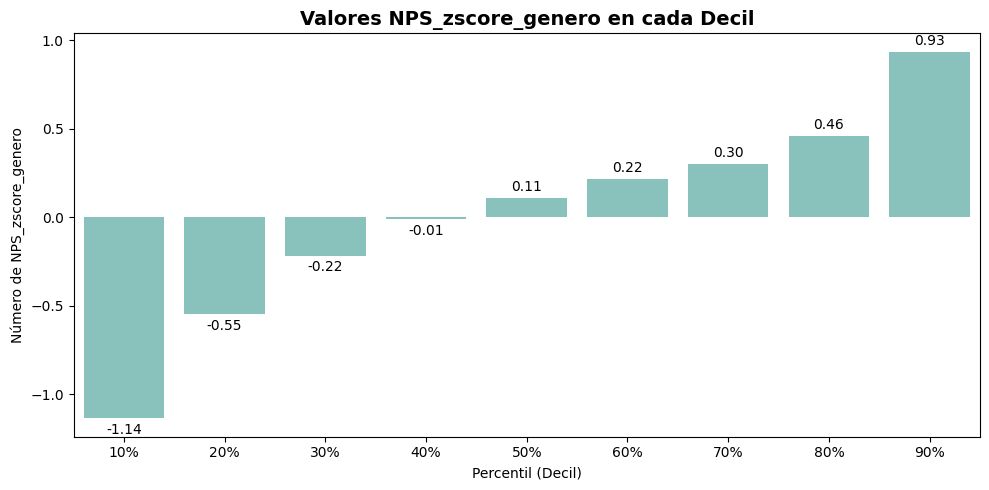

In [ ]:
deciles_zscore = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Calcula todos los deciles de la estandarización
deciles = df_unique['NPS_zscore_genero'].quantile(deciles_a_calcular)

df_deciles = deciles.reset_index()
df_deciles.columns = ['Decil', 'NPS_zscore_genero']
df_deciles['Decil'] = (df_deciles['Decil'] * 100).astype(int).astype(str) + '%'

plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Decil', y='NPS_zscore_genero', data=df_deciles, color='#80CBC4')


plt.title('Valores NPS_zscore_genero en cada Decil', fontsize=14, fontweight='bold')
plt.xlabel('Percentil (Decil)')
plt.ylabel('Número de NPS_zscore_genero')
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

Del resultado anterior, se observa que desde el percentil 0.7 el NPS ajustado tiene un desvío en comparación al promedio más grande y a medida que aumenta el percentil el desvío vs el promedio es mayor. Por ende, se selecciona el umbral 0.7 para definir popularidad.

In [ ]:
umbral_popularidad = df_unique['NPS_zscore_genero'].quantile(deciles_zscore)
umbral_popularidad[0.7]

np.float64(0.3008830984644953)

In [ ]:
df_unique['popular'] = df_unique['NPS_zscore_genero'] >=umbral_popularidad[0.7]

In [ ]:
df_unique['popular'].value_counts(normalize=True)

,proportion
popular,
False,0.620608
True,0.379392


In [ ]:
df_unique.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16139 entries, 0 to 16138
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               16139 non-null  int64  
 1   book_id                  16139 non-null  int64  
 2   cover_image_uri          16139 non-null  object 
 3   book_title               16139 non-null  object 
 4   book_details             16094 non-null  object 
 5   format                   16139 non-null  object 
 6   publication_info         16139 non-null  object 
 7   authorlink               16139 non-null  object 
 8   author                   16139 non-null  object 
 9   num_pages                16139 non-null  float64
 10  genres                   16139 non-null  object 
 11  num_ratings              16139 non-null  int64  
 12  num_reviews              16139 non-null  int64  
 13  average_rating           16139 non-null  float64
 14  rating_distribution   

# **4. Creación de variables potenciales para el modelo**

Decidimos agregar nuevas variables que reflejen la importancia de la trayectoria y la reputación de los autores al momento de publicar un nuevo libro.

Para capturar el efecto de reputación, decidimos incoporar el nps_autor_prev, y para capturar el efecto de la trayectoria incorporamos la varibale q_libros_prev (cantidad de libros previos).

In [ ]:
# NPS ajustado medio para cada autor dada la fecha de publicación

df_unique = df_unique.sort_values(by=['author', 'publication_year'])

df_unique['nps_autor_prev'] = (
    df_unique
    .groupby('author')['NPS_ajustado']
    .apply(lambda x: x.shift().expanding().mean())
    .reset_index(level=0, drop=True)
)


In [ ]:
df_unique.loc[
    df_unique['author'] == 'Stephen King',
    ['book_id', 'nps_autor_prev', 'publication_year']
].head()

,book_id,nps_autor_prev,publication_year
935,10592,NaN,1974
490,5413,7.000000,1975
1045,11590,17.000000,1975
1044,11588,15.666667,1977
944,10628,20.000000,1978


In [ ]:
print("cantidad de autores NPS NaN: ", df_unique['nps_autor_prev'].isna().value_counts(normalize=True))
print(df_unique[df_unique['nps_autor_prev'].isna()][['author', 'book_id', 'publication_year', 'nps_autor_prev']].head())

cantidad de autores NPS NaN:  nps_autor_prev
False    0.528595
True     0.471405
Name: proportion, dtype: float64
              author   book_id  publication_year  nps_autor_prev
12826       A.  Kirk  16067683              2012             NaN
7791      A.A. Milne    821003              1924             NaN
8570      A.A. Navis   1455480              1956             NaN
8315      A.B. Facey   1189454              1981             NaN
1942   A.B. Yehoshua     27503              1983             NaN


Que existan 47% de los autores sin NPS promedio no es un error, ya que se generó el NPS en base al historial para no repetir información.
Los NPS promedio de autor NaN implican que no existe historial del autor en nuestro dataset, por ende imputaremos a esos valores 0 para poder correr los modelos.

In [ ]:
df_unique['nps_autor_prev'] = df_unique['nps_autor_prev'].fillna(0)

In [ ]:
#Cantidad de libros publicados teniendo en cuenta el año de publicación

df_unique = df_unique.sort_values(by=['author', 'publication_year'])

df_unique['q_libros_prev'] = (
    df_unique
    .groupby('author')['book_id']
    .apply(lambda x: x.shift().expanding().count())
    .reset_index(level=0, drop=True)
)

In [ ]:
df_unique.loc[
    df_unique['author'] == 'Stephen King',
    ['book_id', 'q_libros_prev', 'publication_year']
].head(5)

,book_id,q_libros_prev,publication_year
935,10592,0.0,1974
490,5413,1.0,1975
1045,11590,2.0,1975
1044,11588,3.0,1977
944,10628,4.0,1978


In [ ]:
df_unique['q_libros_prev'].value_counts(normalize = True)

,proportion
q_libros_prev,
0.0,0.471405
1.0,0.152983
2.0,0.087180
3.0,0.057377
4.0,0.042196
...,...
73.0,0.000062
74.0,0.000062
75.0,0.000062


El 47% de los libros de nuestro dataset no tenían publicaciones anteriores.

In [ ]:
print("cantidad de autores con publicaciones previas NaN: ", df_unique['q_libros_prev'].isna().value_counts(normalize=True))
print(df_unique[df_unique['q_libros_prev'].isna()][['author', 'book_id', 'publication_year', 'q_libros_prev']])

cantidad de autores con publicaciones previas NaN:  q_libros_prev
False    1.0
Name: proportion, dtype: float64
Empty DataFrame
Columns: [author, book_id, publication_year, q_libros_prev]
Index: []


# **5. Análisis exploratorio**


In [ ]:
df_unique.columns

Index(['Unnamed: 0', 'book_id', 'cover_image_uri', 'book_title',
       'book_details', 'format', 'publication_info', 'authorlink', 'author',
       'num_pages', 'genres', 'num_ratings', 'num_reviews', 'average_rating',
       'rating_distribution', 'rating_1', 'rating_2', 'rating_3', 'rating_4',
       'rating_5', 'genres_clean', 'Cluster', 'Cluster_Nombre',
       'publication_info_lista', 'publication_info_limpio', 'publication_year',
       'format_clean', 'formato_solo', 'formato', 'ratio_reviews',
       'rating_5_pct', 'rating_4_pct', 'rating_3_pct', 'rating_2_pct',
       'rating_1_pct', 'antiguedad', 'promotores', 'detractores', 'NPS_book',
       'NPS_ajustado', 'mean', 'std', 'NPS_zscore_genero', 'popular',
       'nps_autor_prev', 'q_libros_prev'],
      dtype='object')

In [ ]:
df_modelo = df_unique[[
    'num_pages',
    'q_libros_prev',
    'nps_autor_prev',
    'formato',
    'Cluster_Nombre',
    'popular',
    'antiguedad',
    'rating_5_pct',
    'rating_1_pct',
    'ratio_reviews'
]]

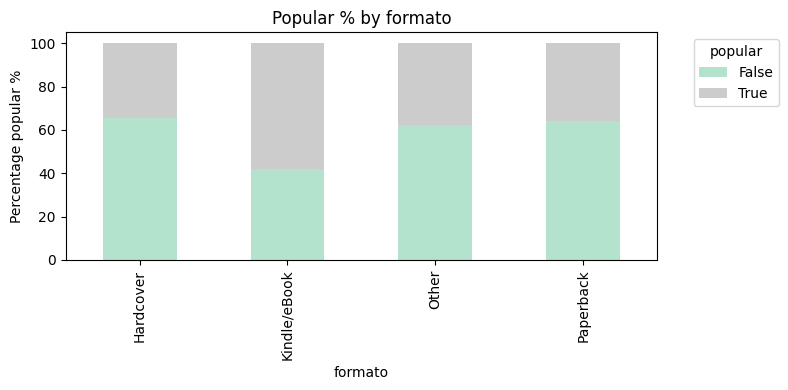

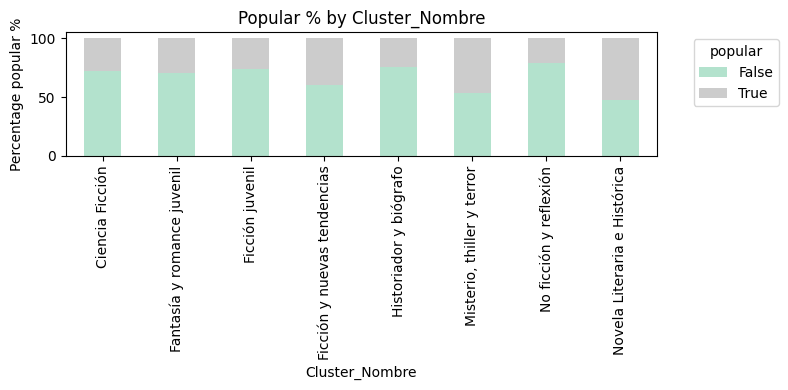

In [ ]:
# Columnas categóricas a analizar
cat_cols = ['formato', 'Cluster_Nombre', 'popular']

for col in cat_cols:
    if col != 'popular':
        tabla = pd.crosstab(df_unique[col], df_unique['popular'], normalize='index') * 100

        tabla.plot(kind='bar', figsize=(8,4), stacked=True, colormap='Pastel2')

        plt.title(f'Popular % by {col}')
        plt.ylabel('Percentage popular %')
        plt.xlabel(col)

        plt.legend(
            title='popular',
            loc='upper left',
            bbox_to_anchor=(1.05, 1)
        )

        plt.tight_layout()
        plt.show()


De los pocos libros dentro de kindle/ebook el mayor porcentaje es popular. Yendo a lo que es el género, dentro de "Ficción y nuevas tendencias vemos una mayor proporción de libros populares, al igual que en la categoría de misterio y novela literaria e histórica.


Analizando variable: average_rating
Skew : -2.19


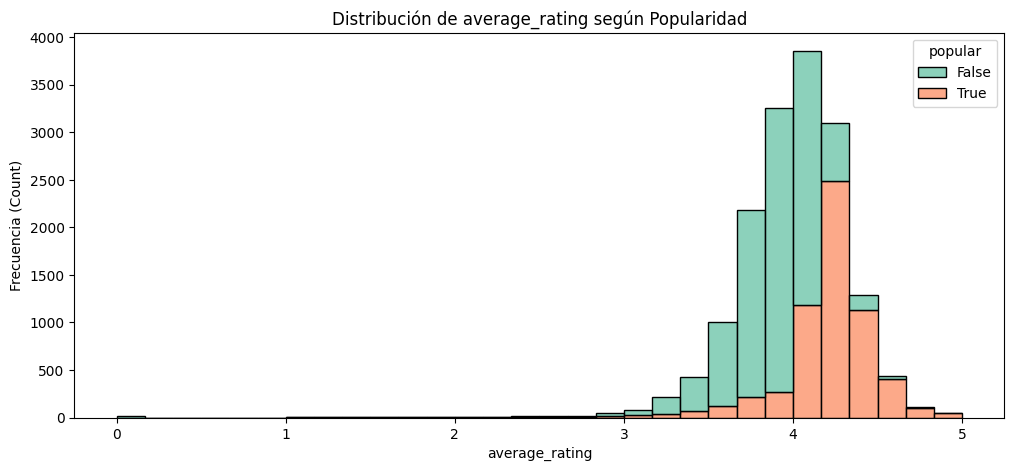


Analizando variable: num_reviews
Skew : 7.98


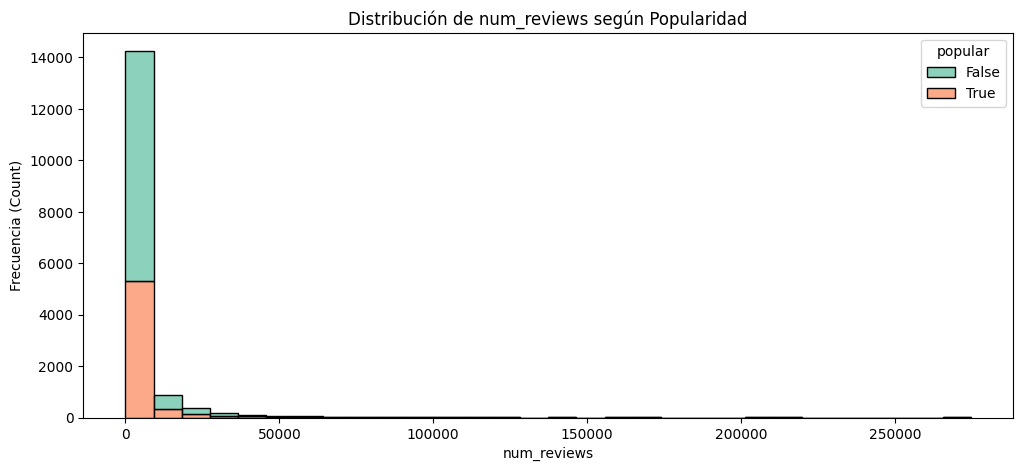


Analizando variable: num_pages
Skew : 9.23


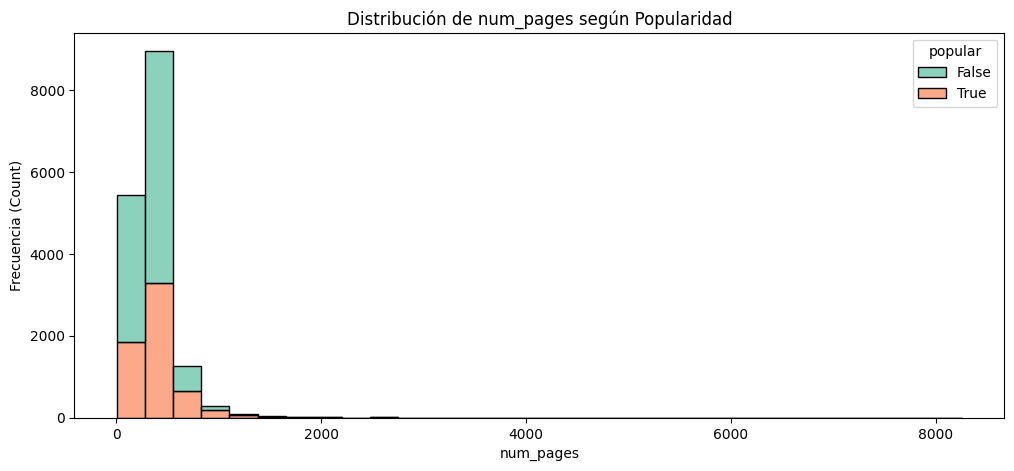


Analizando variable: antiguedad
Skew : 13.13


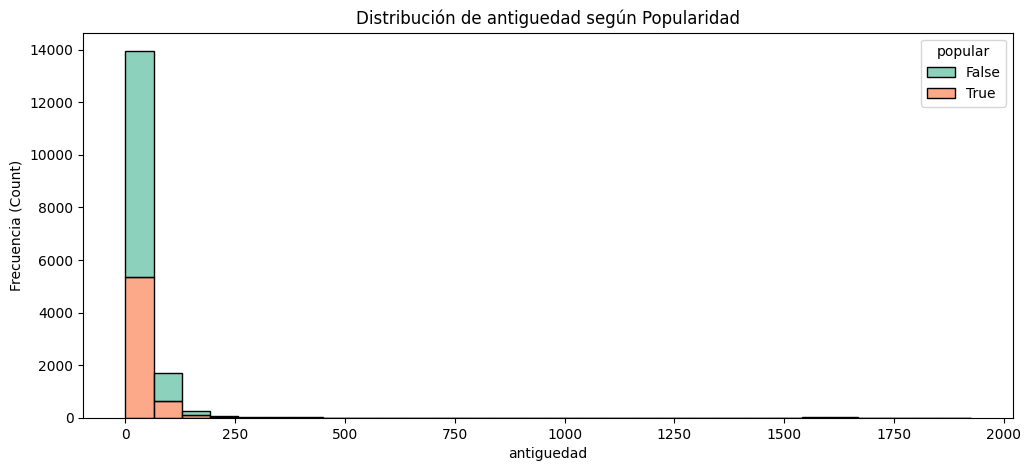


Analizando variable: publication_year
Skew : -13.13


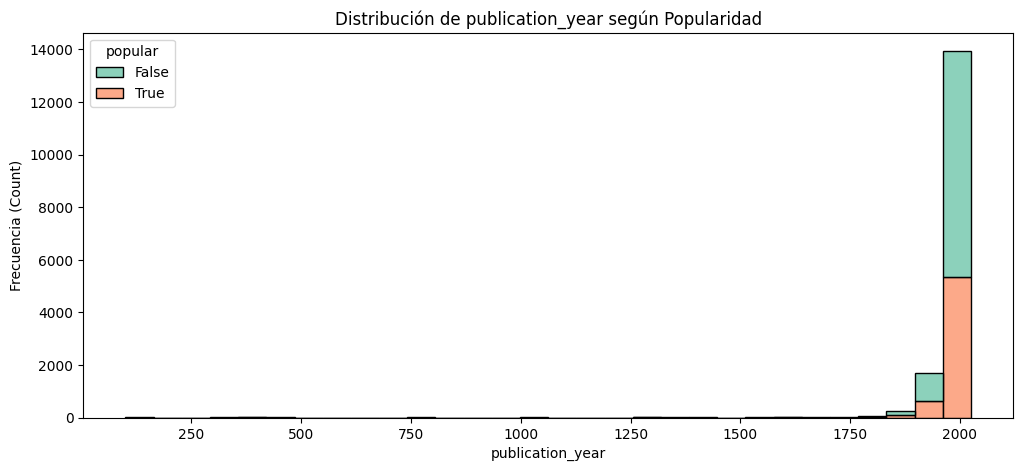


Analizando variable: rating_5_pct
Skew : 0.57


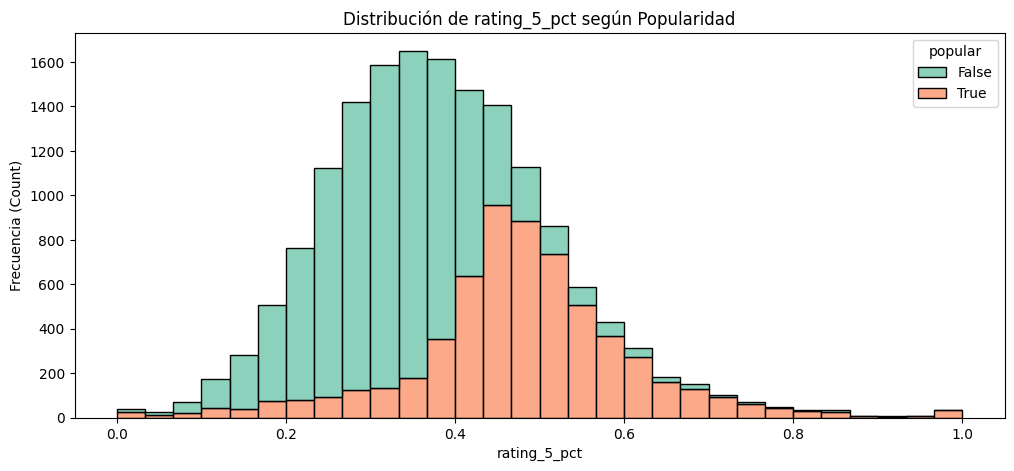


Analizando variable: rating_1_pct
Skew : 11.48


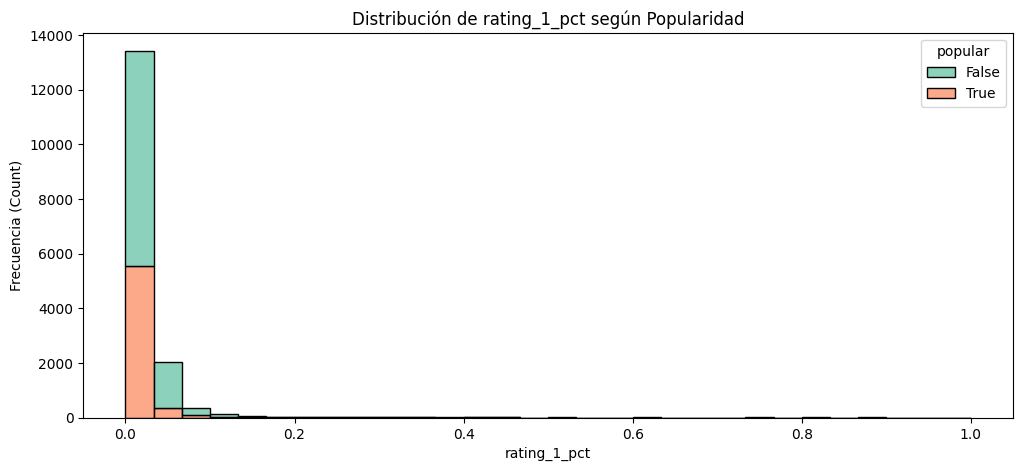


Analizando variable: ratio_reviews
Skew : 3.95


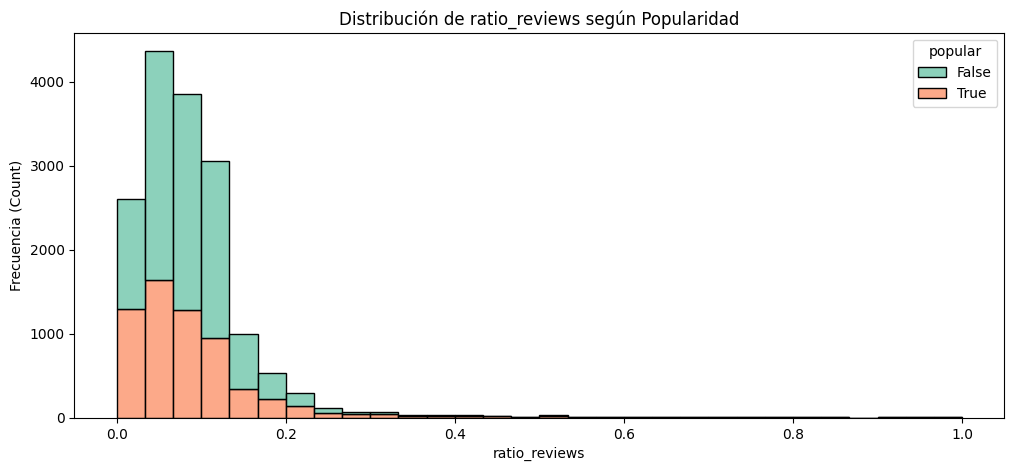


Analizando variable: nps_autor_prev
Skew : 0.75


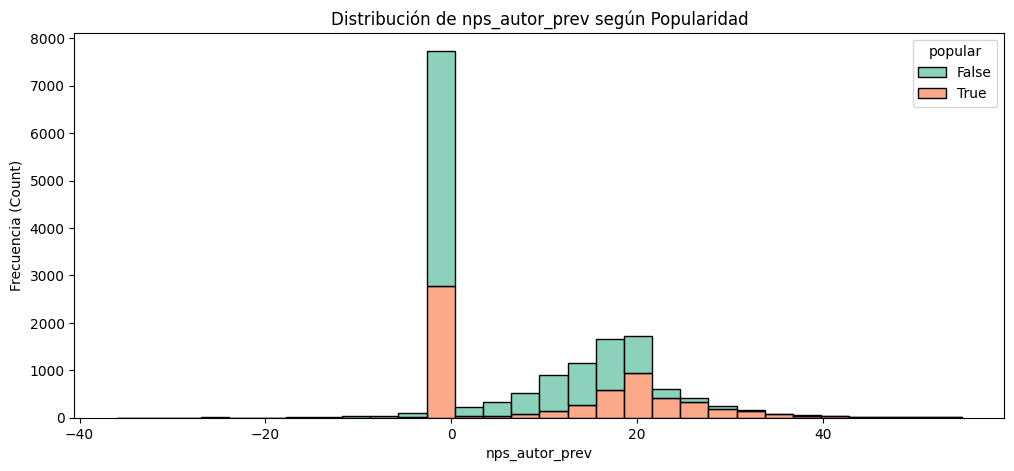


Analizando variable: q_libros_prev
Skew : 4.52


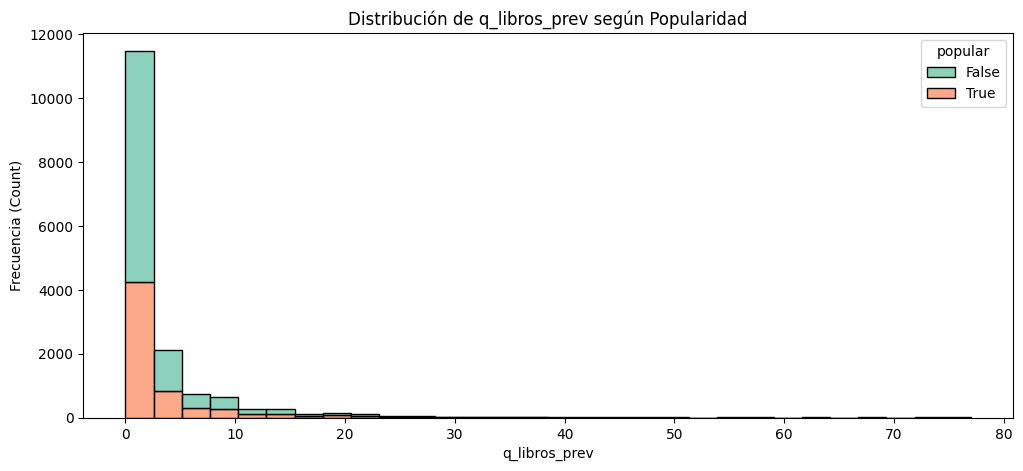

In [ ]:
#Distribuciòn de variables numéricas por popularidad
num_cols = ['average_rating', 'num_reviews', 'num_pages', 'antiguedad','publication_year', 'rating_5_pct', 'rating_1_pct','ratio_reviews', 'nps_autor_prev', 'q_libros_prev']


for col in num_cols:
    if col in df_unique.columns and pd.api.types.is_numeric_dtype(df_unique[col]):

        print(f"\nAnalizando variable: {col}")

        print('Skew :', round(df_unique[col].skew(), 2))

        plt.figure(figsize=(12, 5))

        sns.histplot(
            data=df_unique,
            x=col,
            hue='popular',
            multiple="stack",
            bins=30,
            palette="Set2"
        )

        plt.title(f'Distribución de {col} según Popularidad')
        plt.ylabel('Frecuencia (Count)')
        plt.xlabel(col)

        plt.show()


In [ ]:
#Distribuciòn de variables numéricas por popularidad
num_cols = ['average_rating', 'num_reviews', 'num_pages', 'antiguedad','publication_year', 'rating_5_pct', 'rating_1_pct','ratio_reviews', 'nps_autor_prev', 'q_libros_prev', 'popular']
df_unique.groupby(['popular'])[num_cols].mean().round(2).T

popular,False,True
average_rating,3.88,4.21
num_reviews,4207.84,6736.15
num_pages,337.8,400.62
antiguedad,42.25,37.18
publication_year,1982.75,1987.82
rating_5_pct,0.33,0.48
rating_1_pct,0.03,0.02
ratio_reviews,0.08,0.09
nps_autor_prev,6.96,11.44
q_libros_prev,2.8,3.01


- Los libros populares tienen una puntuación promedio más alta. Los libros populare se concentran en torno al 4.21, mientras que los no populares se concentran en torno a una popularidad de 3.8.

- El porcentaje de 5 estrellas es drásticamente mayor en libros populares. Los populares tienen casi 1.5 veces más puntuaciones de 5 estrellas, confirmando que "la popularidad se define por el amor extremo".

- El porcentaje de ratings de 1 estrella de los libros populares es la mitad que el de los libros no populares.

- Los libros populares tienen más del doble de reseñas que los no populares

- ratio_reviews, el ratio de reseñas sobre ratings es ligeramente menor para los libros populares.

- nps_autor_prev es casi el doble para los libros populares. La buena reputación previa del autor es un factor determinante para el éxito de su nuevo libro.

- q_libros_prev tiene poca diferencia, en promedio los autores de libros no populares tienen 2.7 libros previos y entre los populares esta cifra es de 3.4.

- Los libros populares son, en promedio, más extensos (casi 90 páginas más).

- La antigüedad de los libros es muy parecida en ambos grupos, por sí sola no predice la popularidad.

Nos quedamos unicamente con las variables posibles para el modelo. Estas son:

- Número de paginas

- Antigüedad del libro

- Formato del libro (dummies de formato)

- Cluster de género (dummies de género)

- Peso de las evaluaciones con 5 estrellas

- Peso de las evaluaciones con 1 estrella

- Proporción de reseñas respecto a la cantidad de puntuaciones

- Cantidad de publicaciones previas del escritor

- NPS previo del escritor

In [ ]:
#Seleccion de variables
df_modelo = df_unique[[
    'num_pages',
    'q_libros_prev',
    'nps_autor_prev',
    'formato',
    'Cluster_Nombre',
    'popular',
    'antiguedad',
]]

In [ ]:
df_modelo = pd.get_dummies(
    df_modelo,
    columns=['formato', 'Cluster_Nombre'],
    drop_first=True
)

In [ ]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16139 entries, 12826 to 9725
Data columns (total 15 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   num_pages                                    16139 non-null  float64
 1   q_libros_prev                                16139 non-null  float64
 2   nps_autor_prev                               16139 non-null  float64
 3   popular                                      16139 non-null  bool   
 4   antiguedad                                   16139 non-null  Int64  
 5   formato_Kindle/eBook                         16139 non-null  bool   
 6   formato_Other                                16139 non-null  bool   
 7   formato_Paperback                            16139 non-null  bool   
 8   Cluster_Nombre_Fantasía y romance juvenil    16139 non-null  bool   
 9   Cluster_Nombre_Ficción juvenil               16139 non-null  bool   
 10  

In [ ]:
df_modelo.popular.value_counts(normalize = True)

,proportion
popular,
False,0.620608
True,0.379392


El dataset quedó con un 62% de libros que no son populares y un 37% de libros populares. Esto es un ligero desbalance que nos permite realizar un modelo de clasificación sin problemas, que no requieran técnicas de balanceo extremas, solamente asignar un peso prioritario a la clase minoritaria.

En los resultados del modelo, priorizaremos recall y precisión en los libros "populares". Recall significa la proporción de libros populares reales que el modelo logra capturar y presición es la proporción que el modelo predijo como populares que realmente lo son. En otras palabras, buscamos un alto Recall para asegurarnos de minimizar los Falsos Negativos (libros populares que el modelo falla en capturar) y un alto precision, ya que garantiza la confiabilidad de las predicciones positivas del modelo.

F1 score es el equilibrio entre recall y precisión y la curva ROC AUC mide la capacidad para distiguir del modelo entre ambas clases.

In [ ]:
df_modelo.groupby('popular').mean(numeric_only=True)

,num_pages,q_libros_prev,nps_autor_prev,antiguedad,formato_Kindle/eBook,formato_Other,formato_Paperback,Cluster_Nombre_Fantasía y romance juvenil,Cluster_Nombre_Ficción juvenil,Cluster_Nombre_Ficción y nuevas tendencias,Cluster_Nombre_Historiador y biógrafo,"Cluster_Nombre_Misterio, thiller y terror",Cluster_Nombre_No ficción y reflexión,Cluster_Nombre_Novela Literaria e Histórica
popular,,,,,,,,,,,,,,
False,337.798123,2.797624,6.961572,42.249601,0.063698,0.107628,0.522165,0.077676,0.128494,0.091254,0.125300,0.077975,0.081969,0.255092
True,400.622571,3.010126,11.444078,37.179977,0.145354,0.106974,0.477870,0.053732,0.075453,0.099461,0.065001,0.112363,0.035277,0.455006


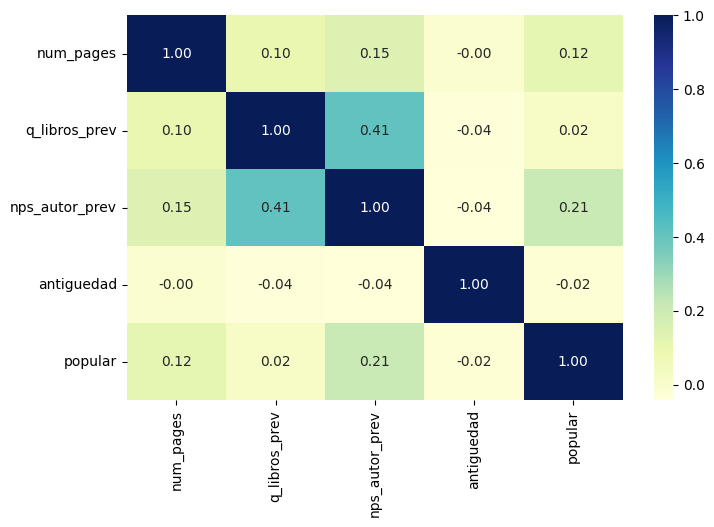

In [ ]:
num_cols = ['num_pages', 'q_libros_prev', 'nps_autor_prev', 'antiguedad',
       'popular']
plt.figure(figsize=(8,5))
sns.heatmap(df_modelo[num_cols].corr(), annot=True, fmt='.2f', cmap='YlGnBu')
plt.show()

**Observaciones**:

nps_autor_prev: Es la correlación más alta con la popularidad. El prestigio previo del autor ayuda al nuevo libro a ser mejor percibido.

q_libros_prev vs nps_autor_prev (0.41):  correlación moderada, un autor con más libros suele tener una audiencia más consolidada.

antiguedad (-0.02): Prácticamente no tiene relación. Hay libros viejos que nadie lee.

num_pages (0.12): Hay una relación positiva leve.


# **6. Entrenamiento de modelos**


In [ ]:
# Separamos la variable dependiente y dividimos el dataset entre entrenamiento y test
Y= df_modelo.popular
X= df_modelo.drop(columns = ['popular'])

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = 1)

In [ ]:
def metrics_score(actual, predicted):

  """
  Función que da cómo resultado las métricas para evualuar el modelo.
  """

  print(classification_report(actual, predicted))

  cm = confusion_matrix(actual, predicted)
  plt.figure(figsize=(8,5))

  sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels=['Not popular', 'Popular'], yticklabels=['Not popular', 'Popular'])
  plt.ylabel('Actual')
  plt.xlabel('Predicted')
  plt.show()

## **Regresión Logística**

In [ ]:
# Escalamos la data para poder comparar variables con distintas magnitudes
sc=StandardScaler()

X_train_scaled=sc.fit_transform(X_train)
X_train_scaled=pd.DataFrame(X_train_scaled, columns=X.columns)

X_test_scaled=sc.transform(X_test)
X_test_scaled=pd.DataFrame(X_test_scaled, columns=X.columns)

In [ ]:
#Generamos el modelo de regresión

lg=LogisticRegression(class_weight='balanced')
lg.fit(X_train_scaled,y_train)

LogisticRegression(class_weight='balanced')

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# 1. Obtenemos las probabilidades (asegúrate de haber corrido lg.fit antes)
y_probs_test = lg.predict_proba(X_test_scaled)[:, 1]

# 2. Definimos los umbrales a evaluar
thresholds = np.arange(0.4, 0.9, 0.05) # De 0.4 a 0.85, pasos de 0.05
resultados = []

for t in thresholds:
    y_pred_t = (y_probs_test >= t).astype(int)

    # Calculamos métricas para este umbral
    resultados.append({
        'Threshold': round(t, 2),
        'Accuracy': accuracy_score(y_test, y_pred_t),
        'Precision (Popular)': precision_score(y_test, y_pred_t),
        'Recall (Popular)': recall_score(y_test, y_pred_t),
        'F1-Score': f1_score(y_test, y_pred_t)
    })

# 3. Creamos la tabla comparativa
df_comparativo = pd.DataFrame(resultados)

# 4. Formateamos para que sea fácil de leer
print(df_comparativo.to_string(index=False))

 Threshold  Accuracy  Precision (Popular)  Recall (Popular)  F1-Score
      0.40  0.618959             0.496250          0.835346  0.622622
      0.45  0.653656             0.526528          0.789791  0.631833
      0.50  0.664188             0.544545          0.657519  0.595724
      0.55  0.669971             0.567066          0.519759  0.542383
      0.60  0.673069             0.590462          0.428101  0.496341
      0.65  0.678232             0.622905          0.367179  0.462017
      0.70  0.685667             0.682927          0.307355  0.423921
      0.75  0.673689             0.729167          0.211306  0.327660
      0.80  0.659232             0.811594          0.122942  0.213537
      0.85  0.641677             0.853659          0.057629  0.107969


Observaciones: Con el umbral estándar de 0.50, la precisión es de 55% y el Recall de 66%. El modelo acepta muchos libros como populares aunque solo tenga certeza moderada, lo que genera 1002 falsos positivos (libros que el modelo clasifica como populares pero no lo son).

El F1-Score más alto está en el threshold 0.45: este es el punto donde el modelo es más eficiente combinando ambos errores. Sin embargo, su Precisión es 52%, por lo que seguimos teniendo muchos falsos positivos.

Como estrategia de la plataforma sugerimos optar por un enfoque conservador, queremos recomendar libros que realmente sean populares, por lo que elegimos un threshold de 0.7: los libros que el modelo marque como populares serán apuestas seguras, aunque se escaparán muchos éxitos potenciales.

              precision    recall  f1-score   support

       False       0.76      0.67      0.71      6996
        True       0.55      0.66      0.60      4301

    accuracy                           0.66     11297
   macro avg       0.65      0.66      0.65     11297
weighted avg       0.68      0.66      0.67     11297



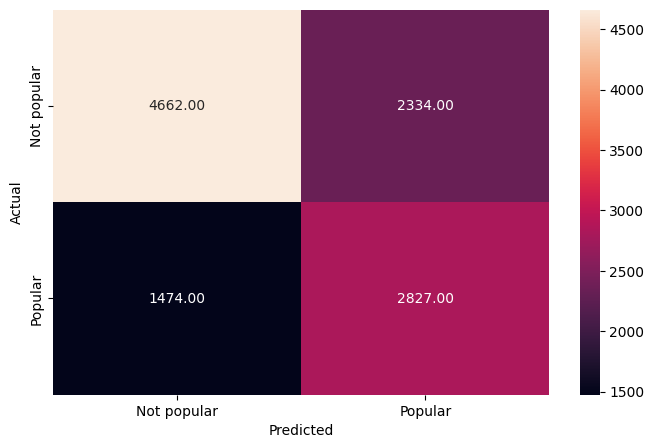

              precision    recall  f1-score   support

       False       0.76      0.67      0.71      3020
        True       0.54      0.66      0.60      1822

    accuracy                           0.66      4842
   macro avg       0.65      0.66      0.65      4842
weighted avg       0.68      0.66      0.67      4842



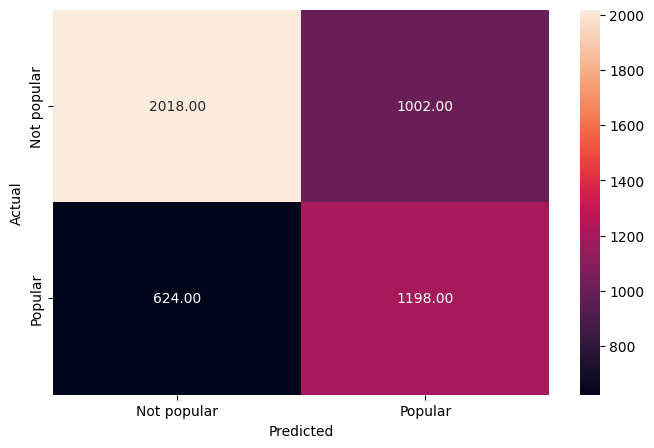

In [ ]:
#Evaluación de entrenamiento y performance en datos de testeo

y_pred_train = lg.predict(X_train_scaled)
y_pred_test = lg.predict(X_test_scaled)


metrics_score(y_train, y_pred_train)
metrics_score(y_test, y_pred_test)

--- PERFORMANCE CON THRESHOLD 0.7 (TRAIN) ---
              precision    recall  f1-score   support

       False       0.68      0.92      0.79      6996
        True       0.71      0.31      0.43      4301

    accuracy                           0.69     11297
   macro avg       0.70      0.62      0.61     11297
weighted avg       0.69      0.69      0.65     11297



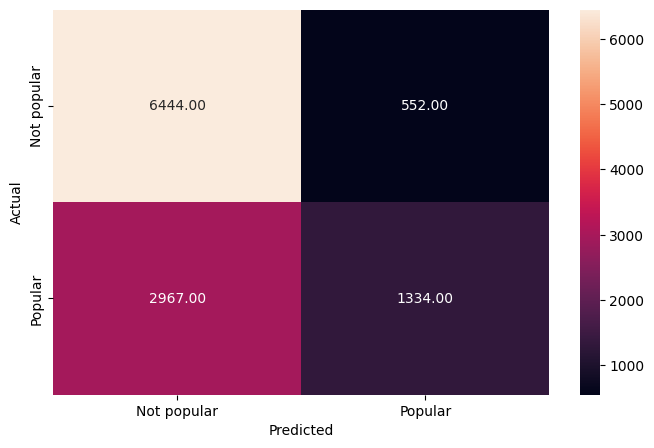


--- PERFORMANCE CON THRESHOLD 0.7 (TEST) ---
              precision    recall  f1-score   support

       False       0.69      0.91      0.78      3020
        True       0.68      0.31      0.42      1822

    accuracy                           0.69      4842
   macro avg       0.68      0.61      0.60      4842
weighted avg       0.68      0.69      0.65      4842



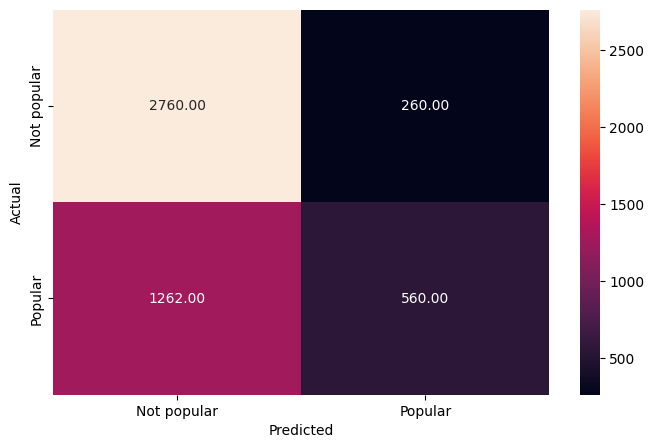

In [ ]:
# 1. Obtenemos las probabilidades para Train y Test
y_probs_train = lg.predict_proba(X_train_scaled)[:, 1]
y_probs_test = lg.predict_proba(X_test_scaled)[:, 1]

# 2. Aplicamos el nuevo threshold de 0.7
threshold = 0.7
y_pred_train_07 = (y_probs_train >= threshold).astype(int)
y_pred_test_07 = (y_probs_test >= threshold).astype(int)

# 3. Evaluamos con tu función original
print(f"--- PERFORMANCE CON THRESHOLD {threshold} (TRAIN) ---")
metrics_score(y_train, y_pred_train_07)

print(f"\n--- PERFORMANCE CON THRESHOLD {threshold} (TEST) ---")
metrics_score(y_test, y_pred_test_07)

In [ ]:
cols=X.columns

coef_lg=lg.coef_

pd.DataFrame(coef_lg,columns=cols).T.sort_values(by = 0,ascending = False)

,0
nps_autor_prev,0.611095
Cluster_Nombre_Novela Literaria e Histórica,0.605345
"Cluster_Nombre_Misterio, thiller y terror",0.287729
num_pages,0.270396
formato_Kindle/eBook,0.238896
Cluster_Nombre_Ficción y nuevas tendencias,0.167772
Cluster_Nombre_Historiador y biógrafo,0.021774
formato_Other,-0.015599
Cluster_Nombre_Fantasía y romance juvenil,-0.017309
Cluster_Nombre_No ficción y reflexión,-0.019903


Las variables con mayor peso positivo son el nps_autor_prev y el género Novela Literaria e Histórica. La reputación previa del autor y este nicho específico son los predictores más fuertes de éxito masivo.

Existe una relación positiva con el número de páginas y el formato Kindle/eBook . El mercado parece favorecer obras más extensas y la facilidad de acceso digital.

Sorprendentemente, la cantidad de libros previos q_libros_prev tiene un impacto negativo. Esto sugiere que algunos autores pueden perder popularidad al hacer muchos libros.

Variables neutras: La antiguedad y el género Fantasía y romance juvenil no muestran una relación lineal clara con la popularidad, actuando de forma neutral en las predicciones.

In [ ]:
odds = np.exp(lg.coef_[0])
pd.DataFrame(odds, X_train_scaled.columns, columns = ['odds']).sort_values(by ='odds', ascending = False)

,odds
nps_autor_prev,1.842448
Cluster_Nombre_Novela Literaria e Histórica,1.831883
"Cluster_Nombre_Misterio, thiller y terror",1.333396
num_pages,1.310483
formato_Kindle/eBook,1.269846
Cluster_Nombre_Ficción y nuevas tendencias,1.182667
Cluster_Nombre_Historiador y biógrafo,1.022013
formato_Other,0.984522
Cluster_Nombre_Fantasía y romance juvenil,0.982840
Cluster_Nombre_No ficción y reflexión,0.980294


- Un aumento en el NPS previo del autor incrementa las probabilidades de que el libro sea popular en un 84% (multiplicando los odds por 1.84).

- Pertenecer al cluster de Novela Literaria e Histórica multiplica por 1.83 la probabilidad de ser popular. Es el género con mayor tracción intrínseca en el mercado analizado.

- Formato y extensión: Los libros en formato Kindle/eBook y aquellos con un mayor número de páginas aumentan las probabilidades de éxito en un 27% y 31% respectivamente.

- Las variables con Odds menores a 1 indican factores que disminuyen la probabilidad de popularidad: tener un catálogo previo muy extenso o pertenecer al genéro ficción juvenil.

Ejecutamos un nuevo modelo eliminado las variables neutrales: las que tienen odds entre 0.95 y 1.05

In [ ]:
# Lista de variables a eliminar (las neutrales)
vars_a_eliminar = [
    'formato_Other',
    'Cluster_Nombre_Fantasía y romance juvenil',
    'Cluster_Nombre_No ficción y reflexión',
    'antiguedad',
    'Cluster_Nombre_Historiador y biógrafo'
]

# Creamos el nuevo set de entrenamiento quitando esas columnas
X_train_final = X_train_scaled.drop(columns=vars_a_eliminar)
X_test_final = X_test_scaled.drop(columns=vars_a_eliminar)

print(f"Variables restantes: {X_train_final.columns.tolist()}")

Variables restantes: ['num_pages', 'q_libros_prev', 'nps_autor_prev', 'formato_Kindle/eBook', 'formato_Paperback', 'Cluster_Nombre_Ficción juvenil', 'Cluster_Nombre_Ficción y nuevas tendencias', 'Cluster_Nombre_Misterio, thiller y terror', 'Cluster_Nombre_Novela Literaria e Histórica']


In [ ]:
# 2. Re-entrenamiento del modelo optimizado
lg_final = LogisticRegression(class_weight='balanced', random_state=1)
lg_final.fit(X_train_final, y_train)

# 3. Obtención de probabilidades
y_probs_final = lg_final.predict_proba(X_test_final)[:, 1]

# 4. Evaluación de múltiples thresholds
thresholds = np.arange(0.4, 0.9, 0.05)
resultados_finales = []

for t in thresholds:
    y_pred_t = (y_probs_final >= t).astype(int)

    resultados_finales.append({
        'Threshold': round(t, 2),
        'Accuracy': accuracy_score(y_test, y_pred_t),
        'Precision': precision_score(y_test, y_pred_t),
        'Recall': recall_score(y_test, y_pred_t),
        'F1-Score': f1_score(y_test, y_pred_t)
    })

# 5. Visualización de resultados
df_final_comparativo = pd.DataFrame(resultados_finales)
print("\n--- COMPARATIVA DE THRESHOLDS (MODELO OPTIMIZADO) ---")
display(df_final_comparativo)


--- COMPARATIVA DE THRESHOLDS (MODELO OPTIMIZADO) ---


,Threshold,Accuracy,Precision,Recall,F1-Score
0,0.40,0.616894,0.494652,0.837541,0.621969
1,0.45,0.650558,0.523740,0.787047,0.628947
2,0.50,0.663775,0.543971,0.658617,0.595829
3,0.55,0.671830,0.570054,0.520307,0.544046
4,0.60,0.675547,0.595583,0.429199,0.498884
5,0.65,0.680917,0.628598,0.371570,0.467058
6,0.70,0.685667,0.682482,0.307903,0.424357
7,0.75,0.672449,0.727799,0.206915,0.322222
8,0.80,0.657373,0.805243,0.118002,0.205840
9,0.85,0.641264,0.845528,0.057080,0.106941


--- PERFORMANCE MODELO OPTIMIZADO - THRESHOLD 0.7 (TRAIN) ---
              precision    recall  f1-score   support

       False       0.68      0.92      0.78      6996
        True       0.70      0.31      0.43      4301

    accuracy                           0.69     11297
   macro avg       0.69      0.61      0.61     11297
weighted avg       0.69      0.69      0.65     11297



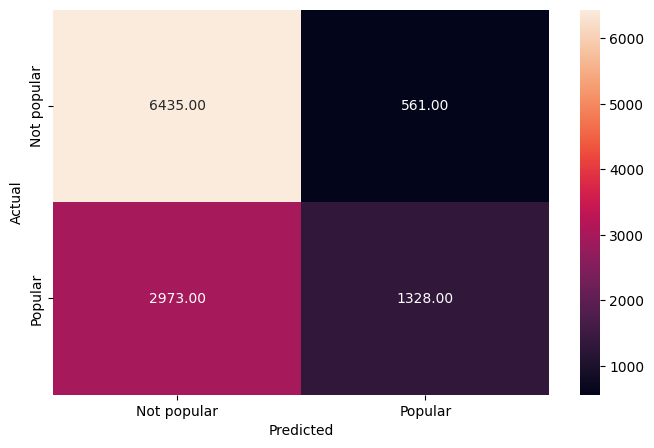


--- PERFORMANCE MODELO OPTIMIZADO - THRESHOLD 0.7 (TEST) ---
              precision    recall  f1-score   support

       False       0.69      0.91      0.78      3020
        True       0.68      0.31      0.42      1822

    accuracy                           0.69      4842
   macro avg       0.68      0.61      0.60      4842
weighted avg       0.68      0.69      0.65      4842



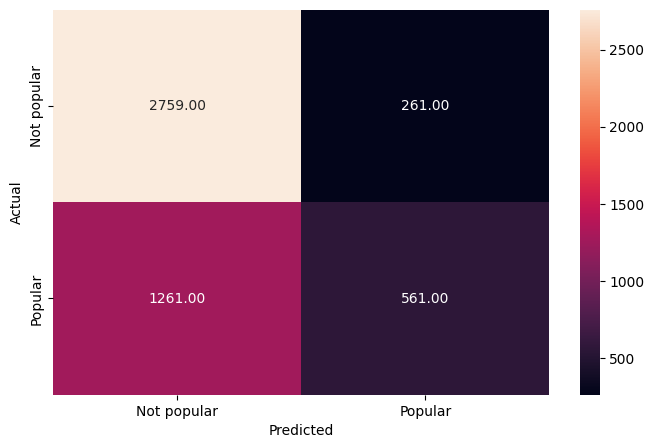

In [ ]:
# 1. Obtenemos las probabilidades con el modelo optimizado (lg_final)
y_probs_train_final = lg_final.predict_proba(X_train_final)[:, 1]
y_probs_test_final = lg_final.predict_proba(X_test_final)[:, 1]

# 2. Aplicamos el threshold de 0.7
threshold = 0.7
y_pred_train_07 = (y_probs_train_final >= threshold).astype(int)
y_pred_test_07 = (y_probs_test_final >= threshold).astype(int)

# 3. Evaluamos el rendimiento final
print(f"--- PERFORMANCE MODELO OPTIMIZADO - THRESHOLD {threshold} (TRAIN) ---")
metrics_score(y_train, y_pred_train_07)

print(f"\n--- PERFORMANCE MODELO OPTIMIZADO - THRESHOLD {threshold} (TEST) ---")
metrics_score(y_test, y_pred_test_07)

Eliminado las variables con Odds neutrales, obtenemos casi lo smismos resultados de precisión y recall pero ganamos en simplicidad del modelo: menos variables, más fácil de explicar y menos probabilidad de sobreajuste.

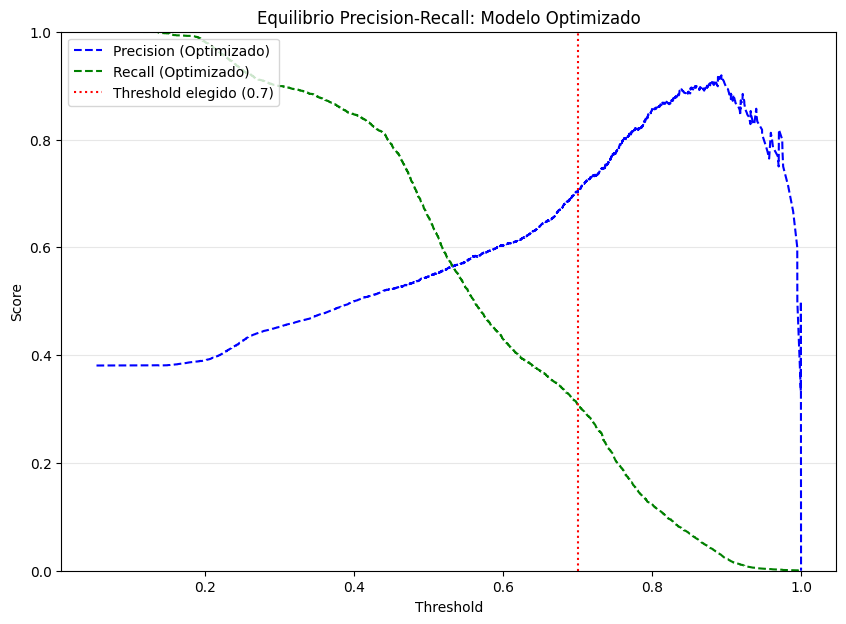

In [ ]:
# Equilibrio entre recall y precision
y_scores_lg_final = lg_final.predict_proba(X_train_final)

precisions_lg_f, recalls_lg_f, thresholds_lg_f = precision_recall_curve(y_train, y_scores_lg_final[:,1])

plt.figure(figsize=(10,7))
plt.plot(thresholds_lg_f, precisions_lg_f[:-1], 'b--', label='Precision (Optimizado)')
plt.plot(thresholds_lg_f, recalls_lg_f[:-1], 'g--', label = 'Recall (Optimizado)')

plt.axvline(x=0.7, color='red', linestyle=':', label='Threshold elegido (0.7)')

plt.title('Equilibrio Precision-Recall: Modelo Optimizado')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend(loc='upper left')
plt.ylim([0,1])
plt.grid(axis='y', alpha=0.3)
plt.show()

El modelo de Regresión Logística, por defecto, utiliza un umbral de clasificación de 0.5.

Sin embargo, al analizar la curva Precision-Recall, buscamos un punto de equilibrio que máximice F1 score y mejore las predicciones de libros.

Para el conjunto de entrenamiento, observamos que en el umbral por defecto (0.5), el modelo mostró un Recall alto de 82% a costa de una Precisión de 76%.
El punto de equilibrio que maximiza el F1-Score se encuentra en un umbral bastante cercano a 0.50, por lo que entendemosque no sería una mejora significativa.

## **Decision Tree**





In [ ]:
dt = DecisionTreeClassifier(class_weight = 'balanced', random_state = 1)

In [ ]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=1)

              precision    recall  f1-score   support

       False       1.00      0.99      1.00      6996
        True       0.99      1.00      0.99      4301

    accuracy                           1.00     11297
   macro avg       0.99      1.00      0.99     11297
weighted avg       1.00      1.00      1.00     11297



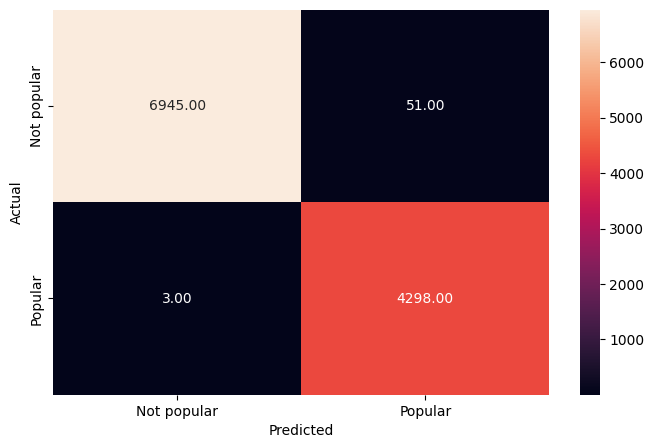

              precision    recall  f1-score   support

       False       0.75      0.74      0.74      3020
        True       0.58      0.58      0.58      1822

    accuracy                           0.68      4842
   macro avg       0.66      0.66      0.66      4842
weighted avg       0.68      0.68      0.68      4842



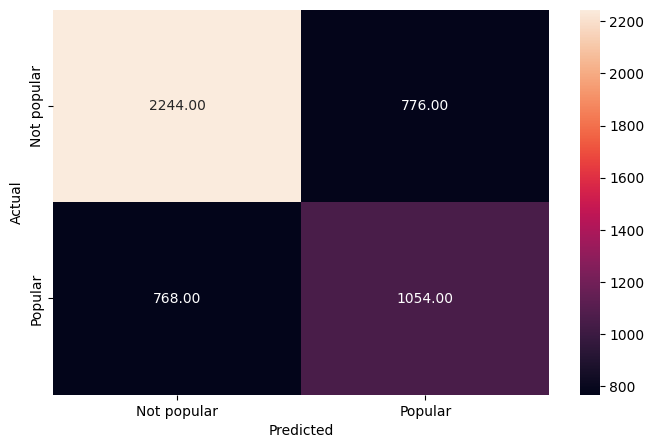

In [ ]:
# Performance de training data y test data
y_train_pred_dt = dt.predict(X_train)
y_test_pred_dt = dt.predict(X_test)


metrics_score(y_train, y_train_pred_dt)
metrics_score(y_test, y_test_pred_dt)

El el dataset de entrenamiento se destaca que todas las métricas son 1, por lo que el modelo presenta un sobreajuste extremo. En el conjunto de test todas las métricas caen abruptamente, confirmando la mala capacidad de generalización del modelo.

A pesar de estos resultados, el arbol de decisión obtiene mejores predicciones que la regresión lineal. Un libro que el arbol de decisión predice como "Popular" tiene un 58% de probabilidad de serlo, mientras que en la regresión logística es 31%.

En cuanto al recall, los resultados en el arbol de decisión también son superiores.

Para mejorar el overfitting de este arbol vamos a probar "podando" el arbol.

In [ ]:
d_tree_tuned = DecisionTreeClassifier(random_state = 7, class_weight = 'balanced')

parameters = {'max_depth': np.arange(2, 10),
              'criterion': ['gini', 'entropy'],
              'min_samples_leaf': [5, 10, 20, 25]
             }


scorer = metrics.make_scorer(recall_score, pos_label = 1)

grid_obj = GridSearchCV(d_tree_tuned, parameters, scoring = scorer, cv = 5)

grid_obj = grid_obj.fit(X_train, y_train)

d_tree_tuned = grid_obj.best_estimator_
d_tree_tuned.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=np.int64(9),
                       min_samples_leaf=20, random_state=7)

              precision    recall  f1-score   support

       False       0.84      0.75      0.79      6996
        True       0.66      0.77      0.71      4301

    accuracy                           0.76     11297
   macro avg       0.75      0.76      0.75     11297
weighted avg       0.77      0.76      0.76     11297



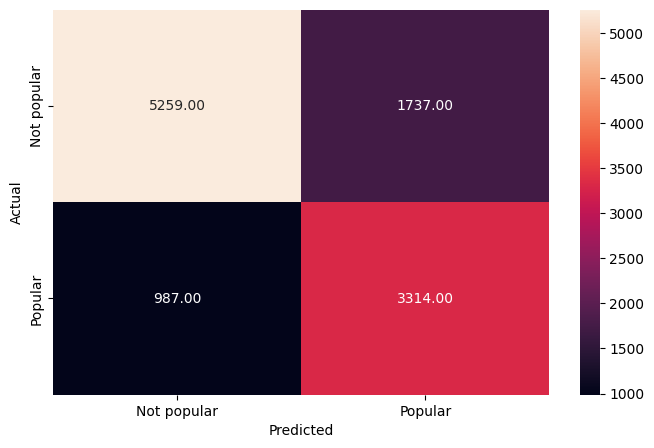

              precision    recall  f1-score   support

       False       0.81      0.73      0.77      3020
        True       0.62      0.72      0.66      1822

    accuracy                           0.73      4842
   macro avg       0.71      0.72      0.72      4842
weighted avg       0.74      0.73      0.73      4842



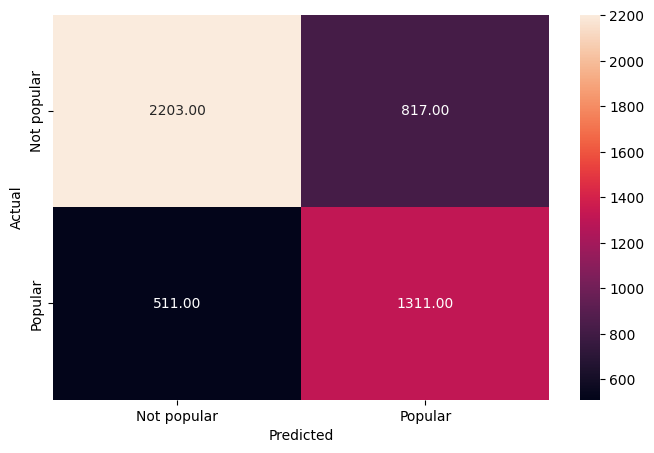

In [ ]:
y_train_pred = d_tree_tuned.predict(X_train)
y_test_pred = d_tree_tuned.predict(X_test)


metrics_score(y_train, y_train_pred)
metrics_score(y_test, y_test_pred)

La optimización de hiperparámetros (poda) mediante GridSearchCV buscó mitigar el overfitting del modelo inicial.

Vemos que la diferencia entre entrenamiento y testeo es mínima.
Tanto la precisión como el recall mejoran con respecto al modelo sin podar por lo que el f1 score pasa de 0.58 a 0.66.

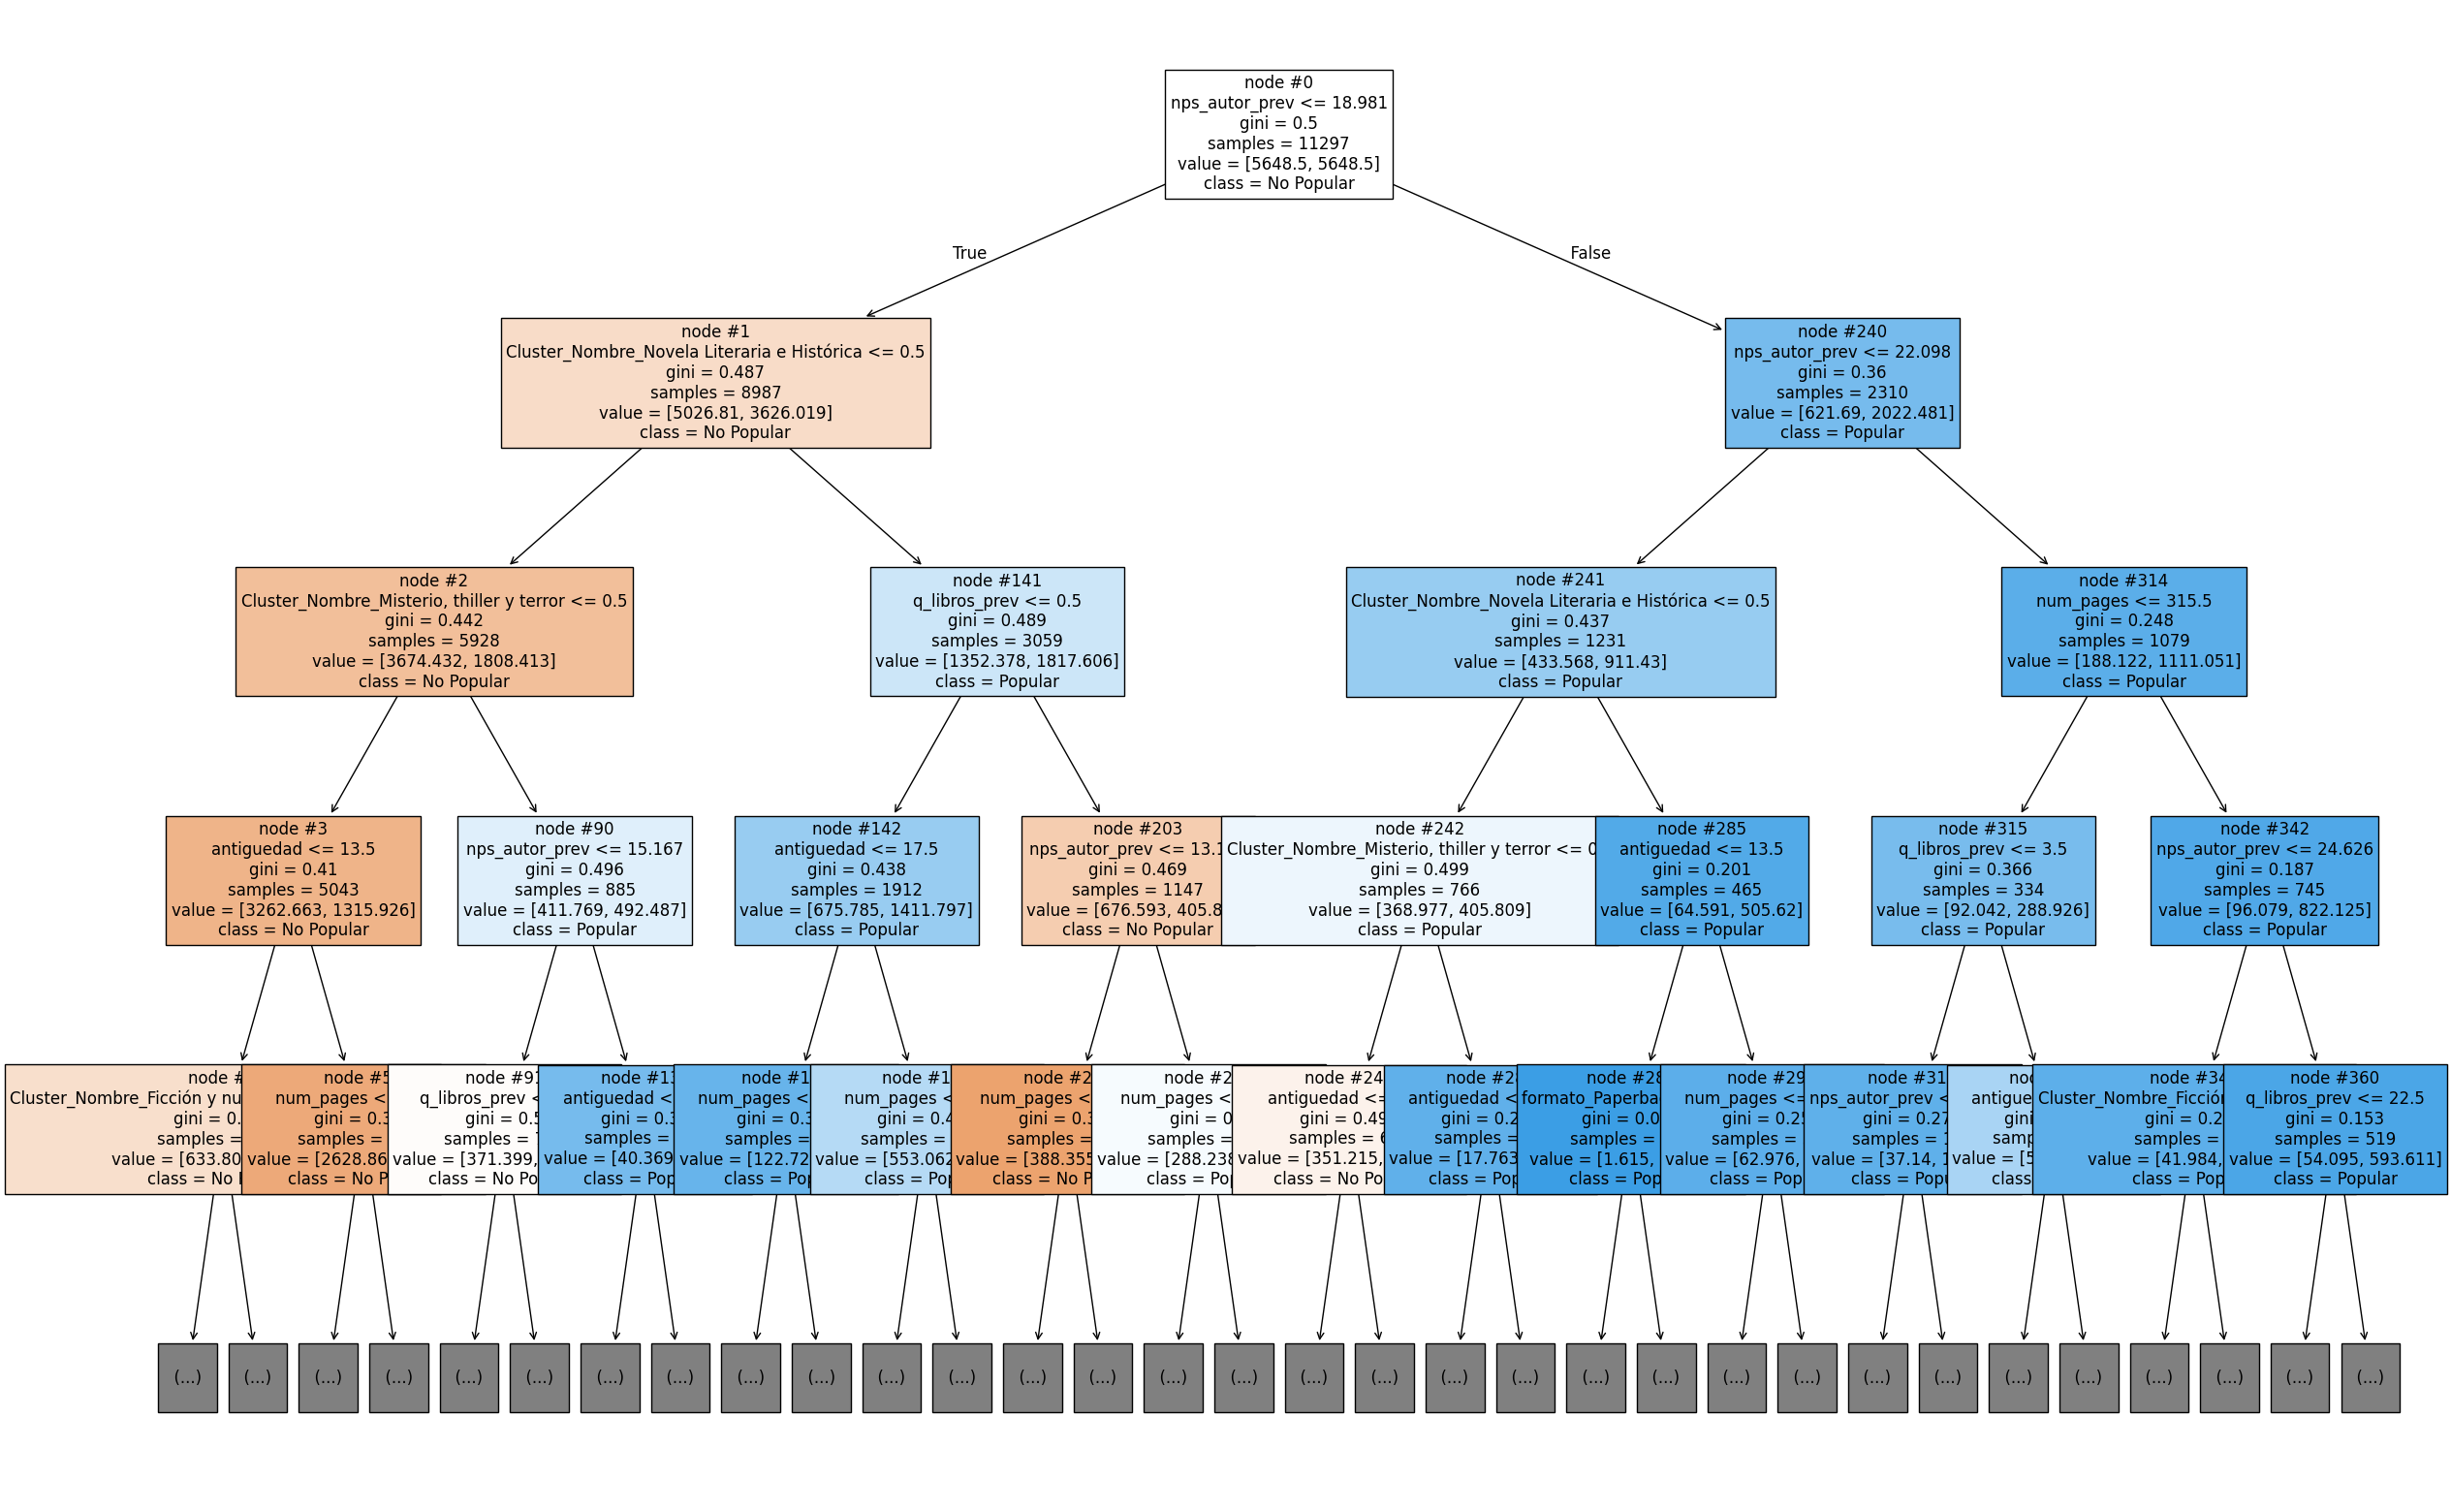

In [ ]:
# Resultados del arbol podado
features = list(X.columns)

plt.figure(figsize = (30, 20))

tree.plot_tree(d_tree_tuned,
               max_depth = 4,
               feature_names = features,
               filled = True,
               fontsize = 12,
               node_ids = True,
               class_names = ['No Popular', 'Popular'])

plt.show()

<Axes: xlabel='Importance', ylabel='None'>

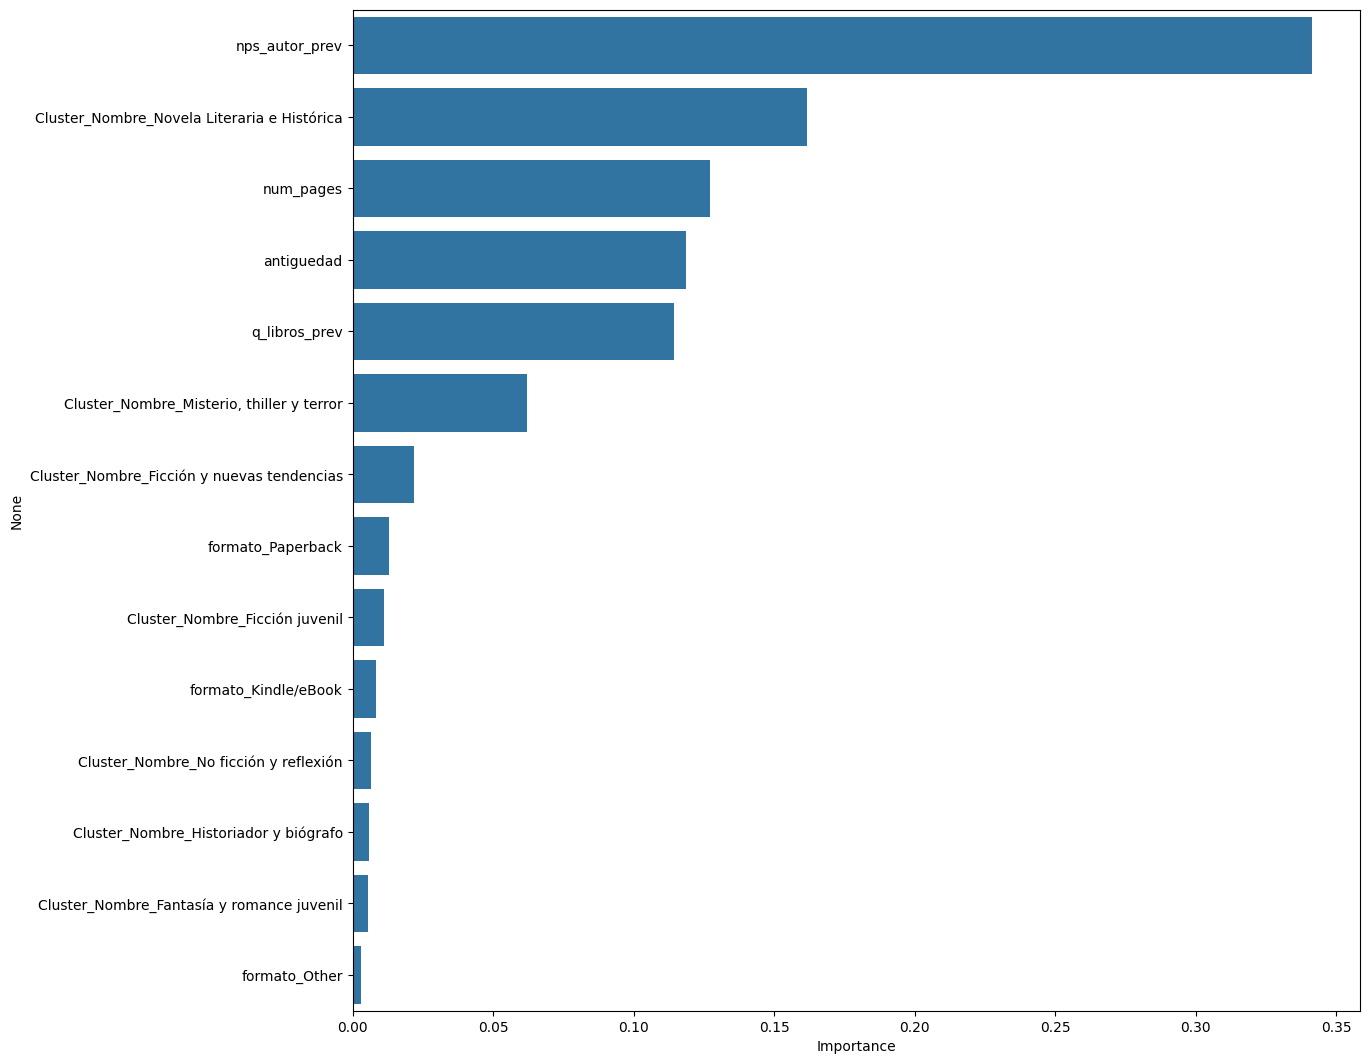

In [ ]:
importances = d_tree_tuned.feature_importances_
columns = X.columns
importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)
plt.figure(figsize = (13, 13))
sns.barplot(data = importance_df, x = importance_df.Importance, y = importance_df.index)

El Decision Tree sirve para mostrar perfiles de libros exitosos, por ejemplo: "Si el autor tiene un NPS > 22 y el libro tiene más de 315 páginas, la probabilidad de éxito es muy alta".

## **Random forest**

In [ ]:
# Entrenamos el modelo
rf_estimator = RandomForestClassifier(class_weight ='balanced', random_state = 1)

rf_estimator.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=1)

              precision    recall  f1-score   support

       False       1.00      0.99      1.00      6996
        True       0.99      1.00      0.99      4301

    accuracy                           1.00     11297
   macro avg       0.99      1.00      0.99     11297
weighted avg       1.00      1.00      1.00     11297



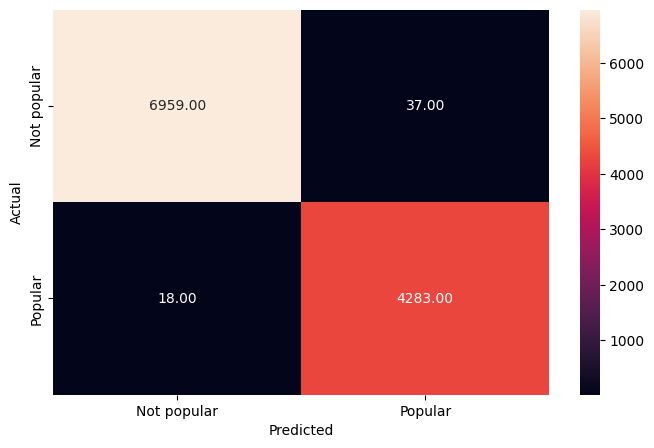

              precision    recall  f1-score   support

       False       0.77      0.82      0.80      3020
        True       0.67      0.60      0.63      1822

    accuracy                           0.74      4842
   macro avg       0.72      0.71      0.71      4842
weighted avg       0.73      0.74      0.74      4842



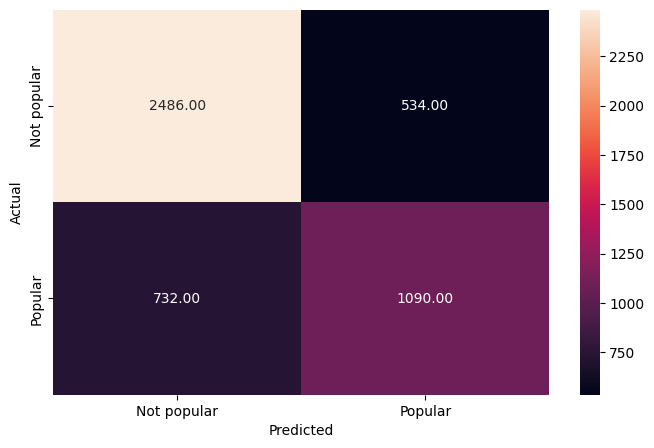

In [ ]:
# Vemos la performance
y_pred_train_rf = rf_estimator.predict(X_train)
y_pred_test_rf = rf_estimator.predict(X_test)

metrics_score(y_train, y_pred_train_rf)
metrics_score(y_test, y_pred_test_rf)

Al igual que el decisition tree, el Random Forest tiene overfitting en el conjunto de entrenamiento. La precisión, el recall y el F1-score son perfectos.

En el dataset de test el Random Forest muestra una alta capacidad de generalización, mostrando muy buenos resultados de las métricas principales.

De todos los libros que el modelo predijo como populares, el 67% lo son. Recall : el modelo logró capturar el 60% de todos los libros populares reales.el Random Forest logra identificar una gran cantidad de éxitos (1090) manteniendo los errores (falsos positivos) en un nivel controlado (534).

<Axes: xlabel='Importancia', ylabel='None'>

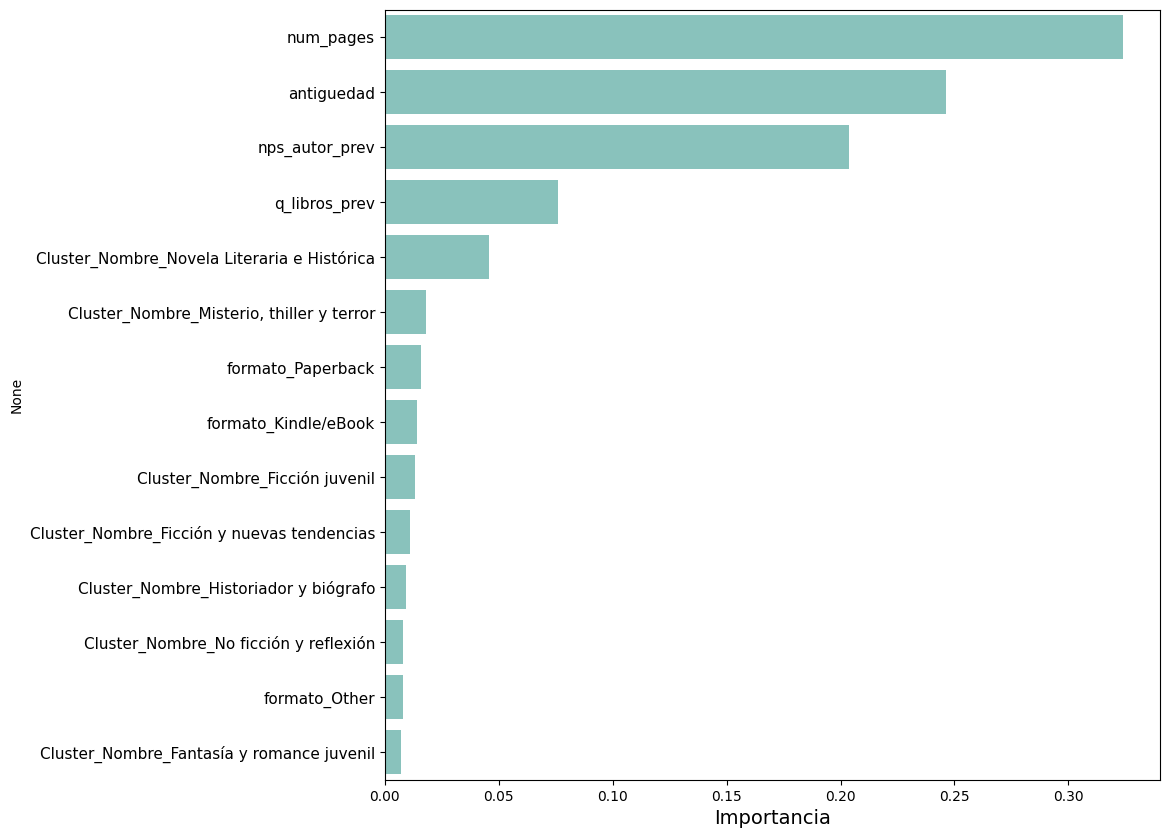

In [ ]:
importances = rf_estimator.feature_importances_
columns = X.columns
importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)
plt.figure(figsize = (10, 10))

plt.xlabel('Importancia', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=11)
sns.barplot(data = importance_df, x = importance_df.Importance, y = importance_df.index, color = '#80CBC4')

num_pages: es la feature más importante. El volumen de la obra es un filtro primario para los lectores y el mercado antes de determinar su popularidad.

antiguedad: a diferencia de la regresión logística, aquí aparece como el segundo factor más importante. El modelo detecta que el tiempo interactúa de forma no lineal con la popularidad.

nps_autor_prev: sigue siendo d elas variables mas influeyentes en la popularidad.

q_libros_prev: la cantidad de obras publicadas anteriormente por el autor también gana peso.

La mayoría de los géneros tienen poca importancia directa, con la excepción de 'Novela Literaria e Histórica', que es el único cluster que aporta valor predictivo.

In [ ]:
#Populares correctamente predichos

true_positives_mask = (y_test == True) & (y_pred_test_rf == True)

tp_books = X_test[true_positives_mask].copy()

tp_books['Actual_Popular'] = y_test[true_positives_mask]
tp_books['Predicted_Popular'] = y_pred_test_rf[true_positives_mask]

tp_books['NPS_zscore_genero'] = df_unique.loc[tp_books.index, 'NPS_zscore_genero']
tp_books['book_title'] = df_unique.loc[tp_books.index, 'book_title']
tp_books['author'] = df_unique.loc[tp_books.index, 'author']

tp_books['NPS_ajustado'] = df_unique.loc[tp_books.index, 'NPS_ajustado']

print(f"Total de Verdaderos Positivos (Libros Populares correctamente predichos): {len(tp_books)}")
print("\nPrimeros 5 Libros (Verdaderos Positivos) y su NPS Score:")
tp_books.round(2).head(10).T


Total de Verdaderos Positivos (Libros Populares correctamente predichos): 1090

Primeros 5 Libros (Verdaderos Positivos) y su NPS Score:


,6825,511,15043,9405,15954,4178,5212,13563,3762,5861
num_pages,496.0,733.0,150.0,80.0,309.0,308.0,608.0,351.0,480.0,296.0
q_libros_prev,0.0,6.0,0.0,0.0,3.0,0.0,3.0,1.0,0.0,0.0
nps_autor_prev,0.0,19.67,0.0,0.0,19.67,0.0,27.0,22.0,0.0,0.0
antiguedad,22,153,7,17,5,31,21,11,30,30
formato_Kindle/eBook,False,False,False,False,True,False,False,True,False,False
formato_Other,False,False,False,False,False,False,False,False,True,True
formato_Paperback,True,True,True,True,False,True,True,False,False,False
Cluster_Nombre_Fantasía y romance juvenil,False,False,False,False,False,False,False,False,False,False
Cluster_Nombre_Ficción juvenil,False,False,False,False,False,False,False,False,False,False
Cluster_Nombre_Ficción y nuevas tendencias,False,False,True,False,False,False,False,True,False,False


Libros populares correctamente clasificados:

-"The Chess Garden" es popular por su género y extensión, mientras que "Demons" lo es por su autor.

In [ ]:
false_negative__mask = (y_test == True) & (y_pred_test_rf == False)

tp_books = X_test[false_negative__mask].copy()

tp_books['Actual_Popular'] = y_test[false_negative__mask]
tp_books['Predicted_Popular'] = y_pred_test_rf[false_negative__mask]

tp_books['NPS_zscore_genero'] = df_unique.loc[tp_books.index, 'NPS_zscore_genero']
tp_books['book_title'] = df_unique.loc[tp_books.index, 'book_title']
tp_books['author'] = df_unique.loc[tp_books.index, 'author']

tp_books['NPS_ajustado'] = df_unique.loc[tp_books.index, 'NPS_ajustado']


print(f"Total de Falsos Neagtivos (Libros Populares incorrectamente clasificados como No Populares): {len(tp_books)}")
print("\nPrimeros 5 Libros (Falsos Negativos) y su NPS Score:")
tp_books.round(2).head(10).T


Total de Falsos Neagtivos (Libros Populares incorrectamente clasificados como No Populares): 732

Primeros 5 Libros (Falsos Negativos) y su NPS Score:


,2891,783,10280,12713,11344,6463,5114,4185,14298,857
num_pages,142.0,240.0,418.0,520.0,182.0,343.0,372.0,446.0,289.0,165.0
q_libros_prev,2.0,5.0,0.0,1.0,1.0,5.0,0.0,0.0,0.0,8.0
nps_autor_prev,18.0,19.2,0.0,15.0,21.0,19.8,0.0,0.0,0.0,14.88
antiguedad,32,23,97,12,28,755,70,24,8,53
formato_Kindle/eBook,False,False,False,False,False,False,False,False,False,False
formato_Other,False,False,False,False,False,False,False,True,False,False
formato_Paperback,False,False,True,False,True,True,True,False,False,True
Cluster_Nombre_Fantasía y romance juvenil,False,True,False,False,False,False,False,False,False,False
Cluster_Nombre_Ficción juvenil,False,False,False,False,False,False,False,False,False,False
Cluster_Nombre_Ficción y nuevas tendencias,False,False,False,False,False,False,False,False,False,False


Libros populares no detectados por el modelo:

- Invisible Cities: con solo 165 páginas, queda muy por debajo del promedio de éxito que el modelo aprendió (donde los libros de más de 300 páginas tienen prioridad).Su género tampoco encaja con el que el modelo prefiere para asegurarse la popularidad. El modelo subestima las "obras maestras breves".

- The Choice: Embrace the Possible: al ser una memoria biográfica de una autora sin libros previos en el dataset, el modelo no tiene una "marca" a la cual aferrarse. El modelo es conservador con los autores nuevos. Si no hay éxito pasado, el algoritmo prefiere no arriesgarse.

## **XGBoost**

              precision    recall  f1-score   support

       False       0.86      0.92      0.89      6996
        True       0.86      0.75      0.80      4301

    accuracy                           0.86     11297
   macro avg       0.86      0.84      0.84     11297
weighted avg       0.86      0.86      0.85     11297



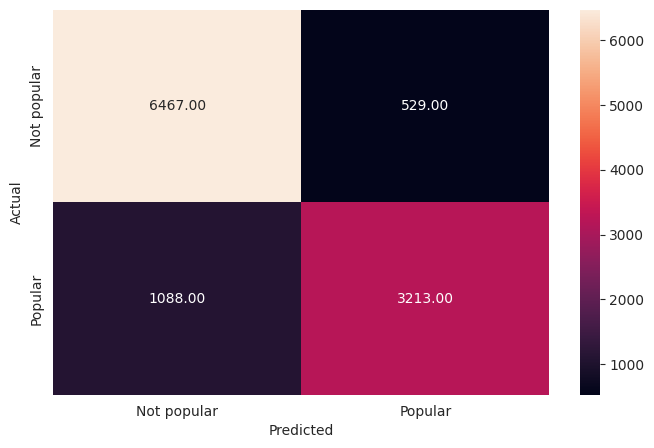

              precision    recall  f1-score   support

       False       0.78      0.85      0.81      3020
        True       0.71      0.61      0.65      1822

    accuracy                           0.76      4842
   macro avg       0.75      0.73      0.73      4842
weighted avg       0.76      0.76      0.75      4842



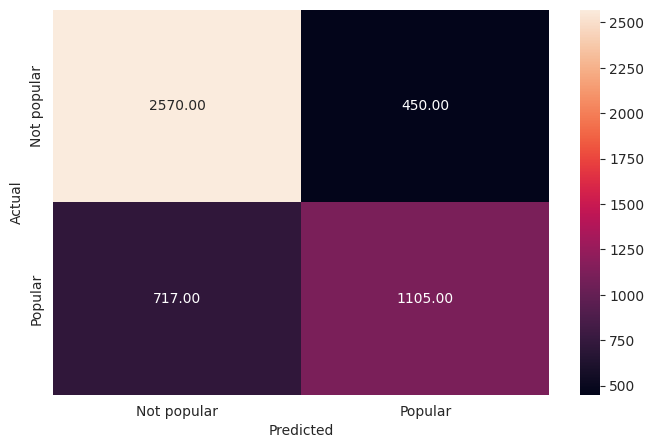

In [ ]:
xgb = XGBClassifier(random_state=1, class_weight='balanced')

xgb.fit(X_train, y_train)

y_pred_train_xgb = xgb.predict(X_train)
y_pred_test_xgb = xgb.predict(X_test)

metrics_score(y_train, y_pred_train_xgb)
metrics_score(y_test, y_pred_test_xgb)

XGBoost se presenta como el modelo más equilibrado entre train y test. Si bien existe una degradación natural de las métricas al pasar del entrenamiento al test, el modelo logra estabilizar la Precisión en un 71%, lo que recomienda como popular tiene una altísima probabilidad de éxito real.

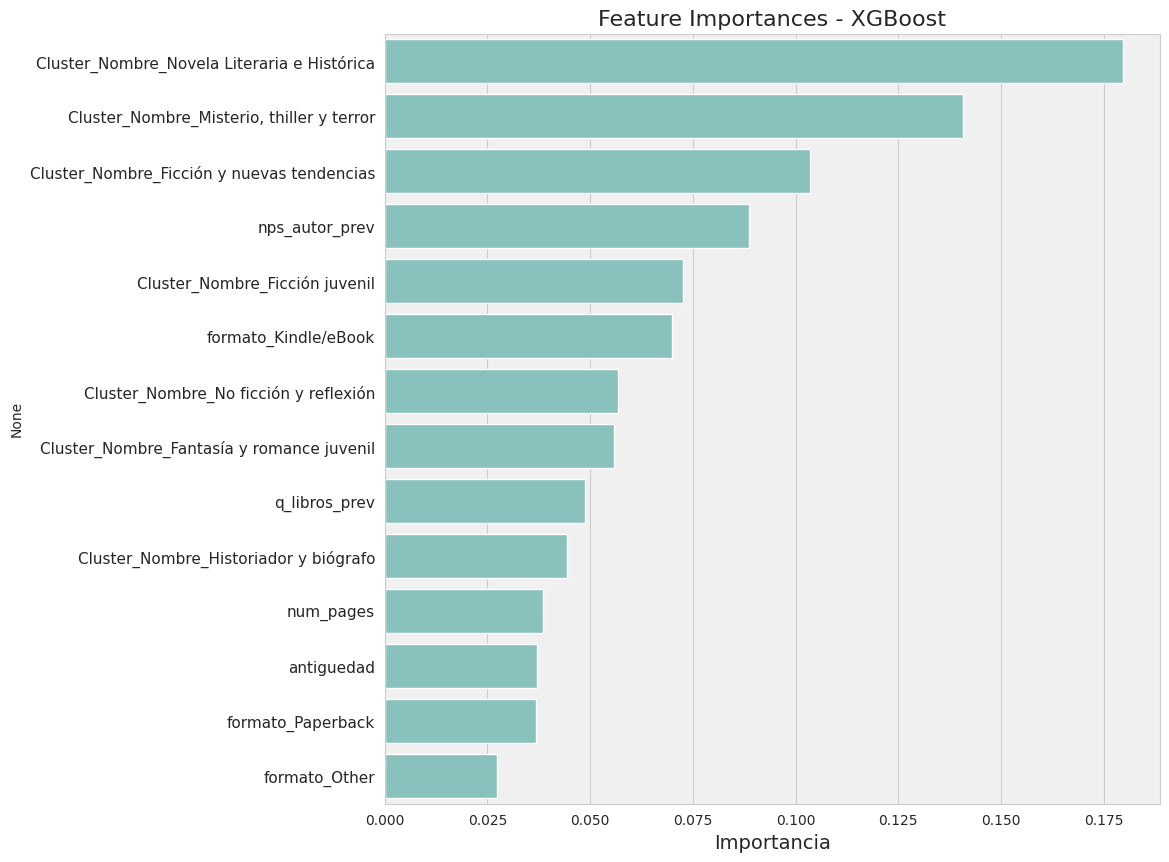

In [ ]:
# Extraer la importancia de las características
importances = xgb.feature_importances_
columns = X.columns

# Crear el DataFrame y ordenar
importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)

# Configuración de la visualización
plt.figure(figsize = (10, 10))
plt.title('Feature Importances - XGBoost', fontsize=16) # Un título siempre ayuda
plt.xlabel('Importancia', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=11)

# Gráfico de barras
sns.barplot(data = importance_df, x = 'Importance', y = importance_df.index, color = '#80CBC4')
plt.show()

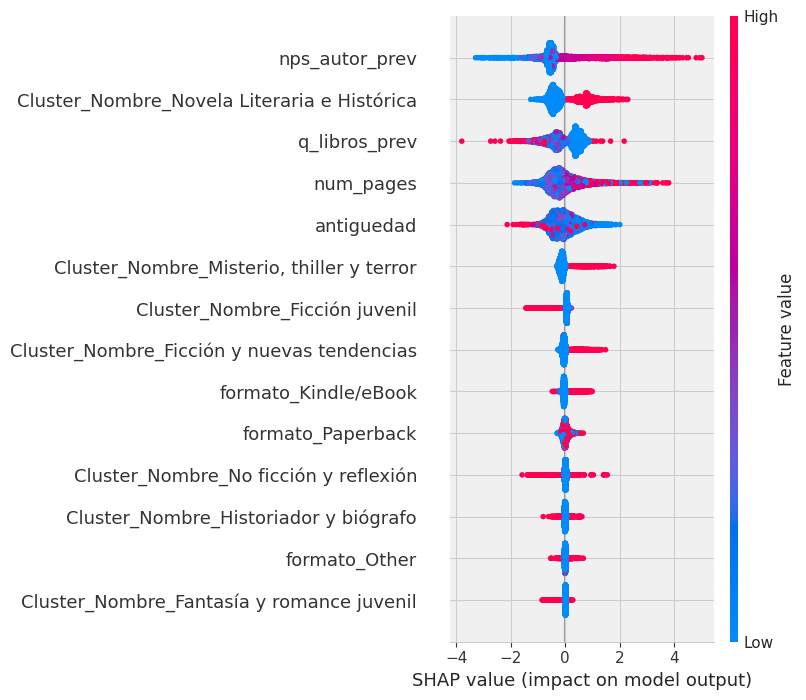

In [ ]:
import shap

# Explicar las predicciones del modelo
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Graficar
shap.summary_plot(shap_values, X_test)

El Género es el predictor más constante y frecuente pero el NPS previo del autor es el predictor más determinante (cuando el NPS es extremo, domina la predicción). Un autor con buen NPS garantiza casi por sí solo una alta popularidad. Por el contrario, un autor con mala reputación (puntos azules a la izquierda) castiga mucho el resultado.

Novela Literaria e Histórica es el segundo predictor más fuerte. Al ser una variable binaria, vemos que cuando el libro pertenece a este género (puntos rojos), el impacto es positivo. Es un género "ganador".

La Antigüedad penaliza: los puntos rojos están a la izquierda del cero. Cuanto más viejo es el libro, menos popularidad predice el modelo. El mercado parece preferir las novedades.

Autores con demasiados libros publicados anteriormente no necesariamente son los más populares ahora. Comparado con otros géneros, Ficción Juvenil tiene más dificultades para alcanzar niveles altos de popularidad.

## **Comparación de los modelos entrenados**

In [ ]:

#Función para comparar todos los modelos

def get_classification_metrics_series(model, X, y, average_type='binary', pos_label=1):
    """
    Calcula Accuracy, Precision, Recall, F1 y AUC-ROC.
    Devuelve una Serie de Pandas.
    """
    y_pred = model.predict(X)

    try:
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X)[:, 1]
            auc_roc = roc_auc_score(y, y_pred_proba)
        else:
            auc_roc = np.nan
    except Exception:
        auc_roc = np.nan

    metrics = {
        'Accuracy': accuracy_score(y, y_pred),
        'Precision (Clase 1)': precision_score(y, y_pred, average=average_type, pos_label=pos_label, zero_division=0),
        'Recall (Clase 1)': recall_score(y, y_pred, average=average_type, pos_label=pos_label, zero_division=0),
        'F1-Score (Clase 1)': f1_score(y, y_pred, average=average_type, pos_label=pos_label, zero_division=0),
        'AUC-ROC': auc_roc
    }

    return pd.Series(metrics)




model_names = [
    "Regresión Logística (lrm)",
    "Árbol de Decisión (dtree)",
    "Random Forest (rf_model)",
    "XGBoost"
]

models = [lg, d_tree_tuned, rf_estimator, xgb]

use_scaling = [True, False, False, False]


results = {}

for name, model, scaled in zip(model_names, models, use_scaling):

    X_eval = X_test_scaled if scaled else X_test

    results[name] = get_classification_metrics_series(
        model=model,
        X=X_eval,
        y=y_test
    )


models_test_comp_df = pd.DataFrame(results).T

print("Comparación de rendimiento de modelos en el Set de Prueba (Clasificación):")
models_test_comp_df.round(2)

Comparación de rendimiento de modelos en el Set de Prueba (Clasificación):


,Accuracy,Precision (Clase 1),Recall (Clase 1),F1-Score (Clase 1),AUC-ROC
Regresión Logística (lrm),0.66,0.54,0.66,0.60,0.72
Árbol de Decisión (dtree),0.73,0.62,0.72,0.66,0.79
Random Forest (rf_model),0.74,0.67,0.60,0.63,0.79
XGBoost,0.76,0.71,0.61,0.65,0.81


Analizamos resultados de Cross Validation para los dos modelos ganadores:

In [ ]:
from sklearn.model_selection import cross_val_score

cv_rf  = cross_val_score(rf_estimator, X_train, y_train, cv=5, scoring='recall')
cv_xgb = cross_val_score(xgb, X_train, y_train, cv=5, scoring='recall')

print("RF CV:", cv_rf.mean(), cv_rf.std())
print("XGB CV:", cv_xgb.mean(), cv_xgb.std())

RF CV: 0.6119495988979824 0.017633293739807585
XGB CV: 0.6056743105637036 0.009771485358699369


In [ ]:
cv_rf  = cross_val_score(rf_estimator, X_train, y_train, cv=5, scoring='precision')
cv_xgb = cross_val_score(xgb, X_train, y_train, cv=5, scoring='precision')

print("RF CV:", cv_rf.mean(), cv_rf.std())
print("XGB CV:", cv_xgb.mean(), cv_xgb.std())

RF CV: 0.6887955085284128 0.014017363606394934
XGB CV: 0.7056002825779064 0.006178811625826452


**Observaciones**:

Los resultados de la Validación Cruzada confirman que, aunque el random forest y el XGBoost tengan performance similares, el XGBoost es el modelo más fiable para GoodReads. Presenta la menor desviación estándar tanto en Precision como Recall, lo que garantiza una consistencia excepcional en sus predicciones.
Además fue el modelo que tiene menos variación entre train y test.



---



# **Conlusiones y Recomendaciones**

Durante este proyecto entrenamos cuatro modelos de clasificación: **Regresión Logística, Decision Tree, Random Forest y XGBoost.**

Los modelos más simples, **Regresión Logística** y **Decision Tree**, obtuvieron las métricas más bajas en comparación con los modelos más complejos, como Random Forest y XGBoost.

Tras comparar las métricas, **el modelo seleccionado es XGBoost** por las siguientes razones:

- Máxima Precisión (0.71): Supera al Random Forest (0.67).Es el modelo que tiene la mayor tasa de acierto real al predecir la popularidad de los libros. Esto minimiza el riesgo de promocionar libros que no tendrán impacto.

- Mejor Capacidad de Separación (AUC-ROC 0.81): Es el modelo que mejor logra distinguir entre un éxito y un fracaso de manera global.

- Consistencia: Como vimos en las pruebas de validación cruzada, es el modelo más estable (menor varianza).

**Recomendaciones**

El objetivo inicial del proyecto fue ofrecer a los usuarios historias atrapantes basadas en la popularidad de los libros del dataset. Bajo este criterio, el modelo seleccionado es XGBoost, ya que presenta la mejor precisión y, por lo tanto, maximiza la probabilidad de recomendar libros que efectivamente serán considerados POPULARES.

Este modelo facilita la toma de decisiones de los usuarios que ingresen a la web o la app de Goodreads, incluso sin personalización basada en el comportamiento previo del lector.

Implementación del modelo seleccionado:

1. Optimiza la estrategia de contenido:
Como mencionamos, los libros predichos como POPULARES pueden recibir mayor visibilidad para usuarios nuevos o con poca interacción en Goodreads. Esto aumenta la confianza en la plataforma y mejora la experiencia inicial del usuario.

2. Aumenta la confiabilidad de las recomendaciones:
Con una precisión del 71% en la clase POPULAR, la plataforma asegura que un libro destacado tiene alta probabilidad de ser valorado positivamente por los lectores.

3. Mejora la satisfacción del usuario y su relación con la plataforma:
Al dirigir a los lectores hacia libros con alto potencial de popularidad, aumentamos la probabilidad de que encuentren contenido relevante y de calidad. Incluso los lectores frecuentes pueden valorar el saber “qué es tendencia”, satisfaciendo el deseo de mantenerse informados sobre lo que está en boca de todos.


In [ ]:
from google.colab import drive, files
import os

# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Definir la ruta (Ojo: usualmente es /content/drive/My Drive/...)
path = "/content/drive/MyDrive/Colab Notebooks"

if os.path.exists(path):
    %cd "$path"

    # 3. Convertir a HTML
    # Usamos comillas para evitar errores con los espacios del nombre
    !jupyter nbconvert --to html "Final PROYECTO Goodreads.ipynb"

    # 4. Descargar
    files.download("Final PROYECTO Goodreads.html")
else:
    print("La ruta no existe. Verifica si es 'MyDrive' o 'My Drive'.")

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks
[NbConvertApp] WARNING | pattern 'Final PROYECTO Goodreads.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead

FileNotFoundError: Cannot find file: Final PROYECTO Goodreads.html